In [7]:
#@title CELL 0: HYBRID SETUP (Local + Colab)
"""
===============================================================================
HYBRID SETUP v2.0
- Detects Colab via importlib.util.find_spec("google.colab")
- Standardizes on numpy>=2.0 everywhere, with fallback to numpy<2.0
- Centralizes ALL path resolution (no PATH_FALLBACK needed downstream)
- Removes nonexistent packages (ommx-openjij-adapter)
===============================================================================
"""

import sys
import subprocess
import time
import warnings
import importlib
import importlib.util
import os
import site
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

warnings.filterwarnings('ignore')

print("=" * 70)
print("🚀 HYBRID SETUP v2.0")
print("=" * 70)

# ============================================================================
# ENV DETECTION
# ============================================================================
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except Exception:
    IN_COLAB = False
print(f"🔍 IN_COLAB = {IN_COLAB}")

# ============================================================================
# HELPER
# ============================================================================
def run_command(cmd, description=None, max_retries=3, wait=2, timeout=120):
    if description:
        print(f"  ▶ {description}...")
    for attempt in range(1, max_retries + 1):
        if attempt > 1:
            print(f"    Retry {attempt}/{max_retries}...")
            time.sleep(wait)
        try:
            result = subprocess.run(
                cmd, shell=True, capture_output=True, text=True,
                timeout=timeout, check=False
            )
            if result.returncode == 0:
                if result.stdout:
                    output = result.stdout.strip()
                    if len(output) > 200:
                        output = output[:200] + "..."
                    print(f"    {output}")
                return True
            else:
                error_msg = result.stderr.strip()
                if len(error_msg) > 100:
                    error_msg = error_msg[:100] + "..."
                print(f"    Attempt {attempt} failed: {error_msg}")
        except subprocess.TimeoutExpired:
            print(f"    Attempt {attempt} timed out after {timeout}s")
        except Exception as e:
            print(f"    Attempt {attempt} error: {e}")
    print(f"  ❌ Command failed after {max_retries} attempts: {cmd}")
    return False

# ============================================================================
# INSTALLATION
# ============================================================================
print("[1] Upgrading pip and certifi...")
run_command(f"{sys.executable} -m pip install --upgrade pip certifi", "Upgrade pip/certifi")

print("[2] Installing numpy>=2.0...")
run_command(f"{sys.executable} -m pip install --only-binary=:all: numpy>=2.0", "Install numpy>=2.0")

CORE_PACKAGES = [
    "scipy>=1.9",
    "pandas>=2.0,<3.0",
    "matplotlib>=3.5",
    "shapely>=2.0",
    "tqdm>=4.60",
    "ipywidgets>=8.0",
    "jijmodeling>=1.0,<2.0",
    "openjij>=0.12",
    "ommx-pyscipopt-adapter>=2.0",
    "optuna>=3.0",
    "wandb>=0.15",
]

print("[3] Installing core packages...")
packages_str = " ".join(CORE_PACKAGES)
success = run_command(f"{sys.executable} -m pip install {packages_str}", "Install core packages")

if not success:
    print("\n⚠️ Install failed with numpy>=2.0. Falling back to numpy<2.0...")
    run_command(f"{sys.executable} -m pip install --only-binary=:all: 'numpy<2.0'", "Downgrade numpy")
    run_command(f"{sys.executable} -m pip install {packages_str}", "Retry install core packages")

# ============================================================================
# REFRESH CACHE
# ============================================================================
print("[4] Refreshing Python paths...")
site.main()
importlib.invalidate_caches()
print("  ✅ Paths refreshed.")

# ============================================================================
# PATH RESOLUTION (centralized - used by all downstream cells)
# ============================================================================
print("[5] Setting up paths...")

if IN_COLAB:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount('/content/drive')
    CACHE_DIR = Path("/content/wqm_data")
    RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
    DATA_DIR = RESULTS_DIR
    REPO_PATH = Path("/content")
    REPO_PATH = Path("/content")
else:
    REPO_PATH = Path.cwd().resolve()
    for _ in range(6):
        if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
            break
        REPO_PATH = REPO_PATH.parent
    DATA_DIR = REPO_PATH / "data"
    CACHE_DIR = DATA_DIR / "cache"
    RESULTS_DIR = REPO_PATH / "results"

# Legacy aliases
LOCAL_CACHE = CACHE_DIR
GDRIVE_BASE = RESULTS_DIR
OUTPUT_DIR = RESULTS_DIR
DRIVE_CACHE = RESULTS_DIR
GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"  IN_COLAB = {IN_COLAB}")
print(f"  REPO_PATH = {REPO_PATH}")
print(f"  DATA_DIR = {DATA_DIR}")
print(f"  CACHE_DIR = {CACHE_DIR}")
print(f"  RESULTS_DIR = {RESULTS_DIR}")
print(f"  GEOJSON_PATH = {GEOJSON_PATH}")

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(f"❌ GeoJSON not found at: {GEOJSON_PATH}")
print(f"✅ GeoJSON found: {GEOJSON_PATH}")

# Add repo root to Python path
sys.path.insert(0, str(REPO_PATH))
sys.path.insert(0, str(REPO_PATH / "src"))

# ============================================================================
# MODULE PURGE
# ============================================================================
modules_to_reload = [
    'src.model', 'src.solvers', 'src.plotting', 'src.environment',
    'src.experiment', 'src.jij_model', 'src.jij_solvers', 'src.jij_optuna',
    'data.synthetic_data', 'tests.benchmark'
]
for mod in modules_to_reload:
    if mod in sys.modules:
        del sys.modules[mod]
        print(f"🔄 Reloaded: {mod}")

print("\n" + "=" * 70)
print("✅ SETUP COMPLETE")
print("=" * 70)


🚀 HYBRID SETUP v2.0
🔍 IN_COLAB = False
[1] Upgrading pip and certifi...
  ▶ Upgrade pip/certifi...
    Attempt 1 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwan: No such file or directory
    Retry 2/3...
    Attempt 2 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwan: No such file or directory
    Retry 3/3...
    Attempt 3 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwan: No such file or directory
  ❌ Command failed after 3 attempts: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-quality-qubo/.venv/bin/python -m pip install --upgrade pip certifi
[2] Installing numpy>=2.0...
  ▶ Install numpy>=2.0...
    Attempt 1 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwan: No such file or directory
    Retry 2/3...
    Attempt 2 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwan: No such file or directory
    Retry 3/3...
    Attempt 3 failed: /bin/sh: line 1: /home/csiy/Documents/school/taiwa

In [17]:
#@title CELL 0.5: SHARED PLOTTING FUNCTIONS
"""
===============================================================================
SHARED PLOTTING FUNCTIONS
- Defined once here for reuse by Cells 5, 6, 7, 8, 9, 10
- Each consuming cell has a fallback copy guarded by try/except NameError
===============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

# These are populated by Cell 0 and Cell 2
try:
    coords_master  # noqa: F821
except NameError:
    coords_master = None
try:
    U_master  # noqa: F821
except NameError:
    U_master = None

def plot_deployment(instance_data, result_or_solution, save_path=None, show=True, dpi=150):
    coords_full = np.asarray(instance_data["original_coords"])
    D_MAX = instance_data["D_max"]
    fixed_indices = list(instance_data.get("fixed_indices", []))
    free_indices = list(instance_data.get("original_indices", []))

    if isinstance(result_or_solution, dict):
        x_sol = result_or_solution.get("solution")
    else:
        x_sol = result_or_solution
    x_sol = np.asarray(x_sol, dtype=int) if x_sol is not None else np.zeros(len(free_indices), dtype=int)

    selected_free_orig = [free_indices[i] for i in np.where(x_sol == 1)[0] if i < len(free_indices)]
    selected_new = [i for i in selected_free_orig if i not in fixed_indices]
    selected_m = fixed_indices
    all_selected = selected_new + selected_m

    if coords_master is not None and len(coords_master) > 0:
        xmin, ymin = coords_master.min(axis=0)
        xmax, ymax = coords_master.max(axis=0)
    else:
        xmin, ymin = coords_full.min(axis=0)
        xmax, ymax = coords_full.max(axis=0)
    pad_x = max(0.05 * (xmax - xmin), 1.0)
    pad_y = max(0.05 * (ymax - ymin), 1.0)

    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1.3], wspace=0.15)
    ax = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    if coords_master is not None and U_master is not None:
        sc = ax.scatter(coords_master[:, 0], coords_master[:, 1], c=U_master, cmap='viridis',
                        s=22, alpha=0.55, edgecolor='none', zorder=0, label='Utility Background')
        plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.046, pad=0.04).set_label('Utility $U_i$', fontsize=11)
    else:
        ax.scatter(coords_full[:, 0], coords_full[:, 1], c="#cbd5e1", s=22, alpha=0.6, edgecolor='none', zorder=0)

    for i in range(len(all_selected)):
        for j in range(i + 1, len(all_selected)):
            idx_i, idx_j = all_selected[i], all_selected[j]
            dist = np.linalg.norm(coords_full[idx_i] - coords_full[idx_j])
            if dist <= D_MAX:
                ax.plot([coords_full[idx_i, 0], coords_full[idx_j, 0]],
                        [coords_full[idx_i, 1], coords_full[idx_j, 1]],
                        color='#475569', alpha=0.5, linewidth=1.2, linestyle='--', zorder=1)

    if free_indices:
        candidate_coords = coords_full[free_indices]
        ax.scatter(candidate_coords[:, 0], candidate_coords[:, 1], c='white', s=40,
                   alpha=0.9, edgecolor='#1e293b', linewidth=0.8, label='Candidates', zorder=2)
    if selected_m:
        ax.scatter(coords_full[selected_m, 0], coords_full[selected_m, 1],
                   c='blue', s=110, marker='s', edgecolor='black', linewidth=1.2,
                   label=f'Existing ({len(selected_m)})', zorder=3)
    if selected_new:
        ax.scatter(coords_full[selected_new, 0], coords_full[selected_new, 1],
                   c='red', s=110, marker='o', edgecolor='black', linewidth=1.2,
                   label=f'New ({len(selected_new)})', zorder=4)

    ax.set_xlabel('Easting (m)', fontsize=11)
    ax.set_ylabel('Northing (m)', fontsize=11)
    ax.set_title('Deployment', fontsize=13, fontweight='bold', pad=10)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=9, markeredgecolor='black', label=f'New ({len(selected_new)})'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=9, markeredgecolor='black', label=f'Existing ({len(selected_m)})'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8, markeredgecolor='#1e293b', label=f'Candidates ({len(free_indices)})'),
        plt.Line2D([0], [0], color='#475569', linewidth=1.2, linestyle='--', label=f'Link (<= {D_MAX:.1f}m)')
    ]
    ax_info.legend(handles=handles, loc='upper left', frameon=True, fontsize=10, title="Legend", title_fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


def plot_miqp_matrix_reduced(instance_data, save_path=None, show=True, dpi=150, title_prefix="", sort_by="coords"):
    N = instance_data["N"]
    a = np.asarray(instance_data["a"], dtype=float)
    Q_edges = instance_data.get("Q_edges", [])
    mat = np.zeros((N, N), dtype=float)
    np.fill_diagonal(mat, a)
    for i, j, val in Q_edges:
        mat[i, j] = val
        mat[j, i] = val

    if sort_by == "coords" and "coords" in instance_data:
        coords_free = np.asarray(instance_data["coords"])
        order = np.lexsort((coords_free[:, 0], -coords_free[:, 1]))
        mat = mat[np.ix_(order, order)]
        title_suffix = " (Spatially Sorted)"
    else:
        title_suffix = ""

    off_diag_mask = ~np.eye(N, dtype=bool)
    off_diag_vals = mat[off_diag_mask]
    if len(off_diag_vals) > 0 and np.max(np.abs(off_diag_vals)) > 0:
        max_val = np.max(np.abs(off_diag_vals))
        norm = mcolors.Normalize(vmin=-max_val, vmax=max_val)
        cbar_label = f"Quadratic Coeffs (±{max_val:.2f})"
    else:
        max_val = np.max(np.abs(mat)) if np.max(np.abs(mat)) > 0 else 1.0
        norm = mcolors.Normalize(vmin=-max_val, vmax=max_val)
        cbar_label = "Coefficient Value"

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', norm=norm)
    ax.set_title(f"{title_prefix}Reduced MIQP Matrix (N={N}){title_suffix}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Variable Index (spatial order)" if sort_by == "coords" else "Variable Index", fontsize=10)
    ax.set_ylabel("Variable Index (spatial order)" if sort_by == "coords" else "Variable Index", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(cbar_label, fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


def plot_qubo_matrix(instance, penalty_weights, N, save_path=None, show=True, dpi=150, title_prefix=""):
    qubo_dict, offset = instance.to_qubo(penalty_weights=penalty_weights)
    Q_mat = np.zeros((N, N), dtype=float)

    def extract_idx(key):
        if isinstance(key, tuple):
            if len(key) == 2 and isinstance(key[0], str) and key[0] == 'x':
                return key[1]
            for elem in key:
                if not isinstance(elem, str):
                    return elem
            return key[0]
        return key

    for (key_i, key_j), val in qubo_dict.items():
        i = extract_idx(key_i)
        j = extract_idx(key_j)
        if isinstance(i, int) and isinstance(j, int) and i < N and j < N:
            Q_mat[i, j] = val
    Q_mat = Q_mat + Q_mat.T - np.diag(np.diag(Q_mat))
    max_abs = np.max(np.abs(Q_mat)) if np.max(np.abs(Q_mat)) > 0 else 1.0
    norm = mcolors.Normalize(vmin=-max_abs, vmax=max_abs)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(Q_mat, cmap='RdBu_r', aspect='auto', norm=norm)
    ax.set_title(f"{title_prefix}QUBO Matrix (free variables) N={N}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Variable Index")
    ax.set_ylabel("Variable Index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Coefficient Value")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


def plot_connectivity_graph(coords, edges, M_indices=None, save_path=None, show=True, dpi=150, title=""):
    fig, ax = plt.subplots(figsize=(10, 8))
    segments = []
    for i, j in edges:
        segments.append([(coords[i, 0], coords[i, 1]), (coords[j, 0], coords[j, 1])])
    if segments:
        from matplotlib.collections import LineCollection
        lc = LineCollection(segments, colors="steelblue", alpha=0.3, linewidth=0.6, zorder=1)
        ax.add_collection(lc)
    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=15, alpha=0.8, zorder=2)
    if M_indices is not None and len(M_indices) > 0:
        ax.scatter(coords[M_indices, 0], coords[M_indices, 1],
                   c="red", marker="*", s=200, edgecolor="black", linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


In [22]:
#@title CELL 1: MASTER CONTROL FLAGS + SIMULATION CONFIGS
# ============================================================================
# Recompute flags
# ============================================================================
FORCE_RECOMPUTE_MASTER = False
FORCE_RECOMPUTE_SCALING = False
FORCE_RECOMPUTE_QUBO = False
FORCE_RECOMPUTE_SCIP = False
FORCE_RETUNE_SA = False
FORCE_RETUNE_SQA = False
FORCE_ALL_RECOMPUTE = False

if FORCE_ALL_RECOMPUTE:
    FORCE_RECOMPUTE_MASTER = True
    FORCE_RECOMPUTE_SCALING = True
    FORCE_RECOMPUTE_QUBO = True
    FORCE_RECOMPUTE_SCIP = True
    FORCE_RETUNE_SA = True
    FORCE_RETUNE_SQA = True

print("🔧 Master Control Flags:")
print(f"   FORCE_RECOMPUTE_MASTER = {FORCE_RECOMPUTE_MASTER}")
print(f"   FORCE_RECOMPUTE_SCALING = {FORCE_RECOMPUTE_SCALING}")
print(f"   FORCE_RECOMPUTE_QUBO = {FORCE_RECOMPUTE_QUBO}")
print(f"   FORCE_RECOMPUTE_SCIP = {FORCE_RECOMPUTE_SCIP}")
print(f"   FORCE_RETUNE_SA = {FORCE_RETUNE_SA}")
print(f"   FORCE_RETUNE_SQA = {FORCE_RETUNE_SQA}")

# ============================================================================
# SA Tuning Config
# ============================================================================
CONFIG_SA = {
    "TARGET_N": None,
    "NUM_SWEEPS": 1000,
    "NUM_READS": 1024,
    "SYNC_INTERVAL": 5,
    "WARMUP_TRIALS": 15,
    "MAX_FLOOR_HITS": 10,
    "VARIANCE_TOLERANCE": 0.05,
    "MIN_FEASIBLE_FOR_VARIANCE": 5,
    "FEASIBILITY_RANK_THRESHOLD": 20,
    "TOP_K_ENERGY": 3,
    "ENERGY_TOLERANCE_PCT": 0.5,
    "LAMBDA_LOWER": 0.0001,
    "USE_WANDB": False,
    "WANDB_PROJECT": "wqm-placement-optimization",
    "LOG_WANDB_TABLE": True,
    "SAVE_SA_SAMPLES": True,
}

# ============================================================================
# SQA Tuning Config (placeholder for Cells 8-9)
# ============================================================================
CONFIG_SQA = {
    "TARGET_N": None,
    "NUM_SWEEPS": 1000,
    "NUM_READS": 1024,
    "TROTTER": 4,
    "SCHEDULE": "linear",
    "SYNC_INTERVAL": 5,
    "WARMUP_TRIALS": 15,
    "MAX_FLOOR_HITS": 10,
    "VARIANCE_TOLERANCE": 0.05,
    "MIN_FEASIBLE_FOR_VARIANCE": 5,
    "FEASIBILITY_RANK_THRESHOLD": 20,
    "TOP_K_ENERGY": 3,
    "ENERGY_TOLERANCE_PCT": 0.5,
    "LAMBDA_LOWER": 0.0001,
    "USE_WANDB": False,
    "WANDB_PROJECT": "wqm-placement-optimization",
    "LOG_WANDB_TABLE": True,
    "SAVE_SQA_SAMPLES": True,
}

# ============================================================================
# Final Benchmark Config
# ============================================================================
CONFIG_BENCH = {
    "N_TESTS": [20, 50, 100, 200, 500, 1000],
    "NUM_READS": 256,
    "NUM_SWEEPS": 200,
    "RANDOM_SOLUTIONS": 5,
    "REPEAT_TIMES": 3,
    "CACHE_FILE": str(CACHE_DIR / "benchmark_results.pkl"),
}

print("\n✅ Simulation configs defined.")


🔧 Master Control Flags:
   FORCE_RECOMPUTE_MASTER = False
   FORCE_RECOMPUTE_SCALING = False
   FORCE_RECOMPUTE_QUBO = False
   FORCE_RECOMPUTE_SCIP = False
   FORCE_RETUNE_SA = False
   FORCE_RETUNE_SQA = False

✅ Simulation configs defined.


✅ GeoJSON found: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-quality-qubo/data/LDB_centroids_clean.geojson
🔑 Master config hash: 241358d8
📂 Loading hashed master data from local cache...
✅ Loaded master data: N_sites=5417, Q_edges=2045178
   Existing stations: 15
   U range: 0.0551 to 0.8957


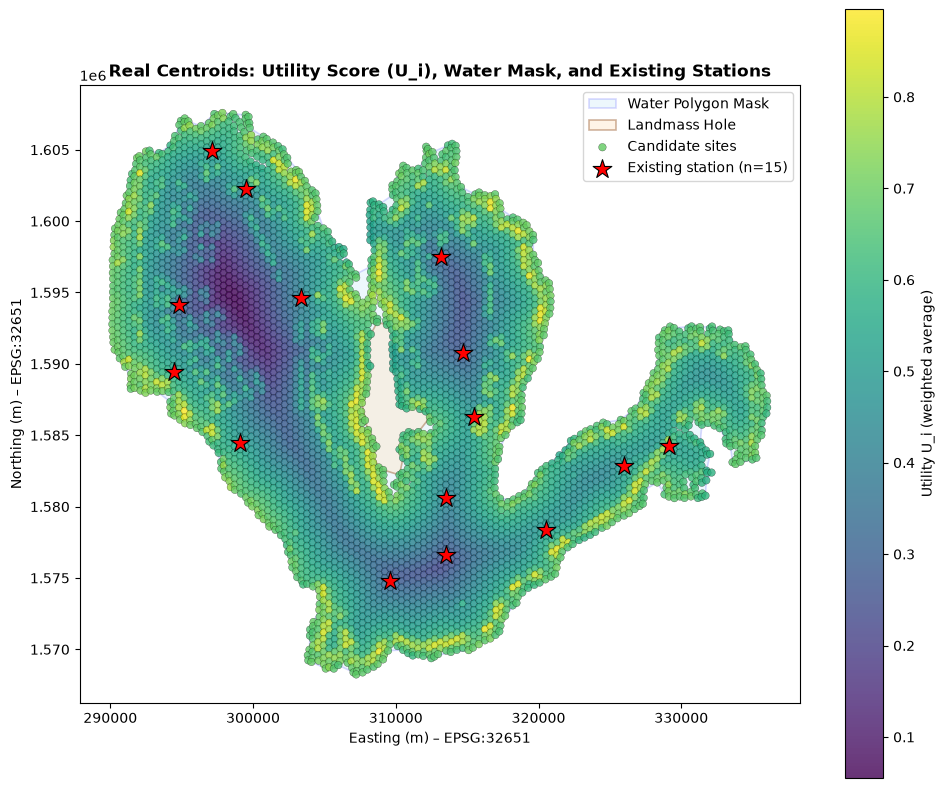

✅ Master data loaded and ready. Skipping recomputation.
✅ Cell 2 complete. Master data ready.


In [19]:
#@title CELL 2: REAL DATA INGESTOR + MASTER MIQP (Resumable, Config‑Aware)
# =============================================================================
# REVISION: Resumable – loads master_real_{config_hash}.pkl if available.
# - Uses FORCE_RECOMPUTE_MASTER flag from Cell 1.
# - Dual storage: local and Drive.
# - Filename includes config_hash to invalidate on QUBO parameter changes.
# - Backward‑compatible: falls back to master_real.pkl if hashed version missing.
# =============================================================================
import json
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from pathlib import Path
import shapely
from shapely.geometry import MultiPoint, Polygon, LineString, Point
from tqdm.notebook import tqdm
import warnings
import hashlib
import shutil

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# USER CONFIGURATION (unchanged)
# -----------------------------------------------------------------------------
# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(f"❌ GeoJSON not found at: {GEOJSON_PATH}")

print(f"✅ GeoJSON found: {GEOJSON_PATH}")

WEIGHTS = np.array([0.3671, 0.1224, 0.2508, 0.0502, 0.1278, 0.0183, 0.0476, 0.0159], dtype=np.float64)

FACTOR_NAMES = [
    "a1_river_proximity",
    "a2_runoff_proximity",
    "b1_fishpen_density",
    "b2_hypoxic_proximity",
    "c1_bathymetric_depressions",
    "c2_outlet_proximity",
    "d1_boatramp_proximity",
    "d2_road_proximity",
]

HULL_RATIO = 0.05
N_EXISTING_FALLBACK = 3
MIN_EXISTING_DIST_FALLBACK = 12000

MASTER_QUBO_CONFIG = {
    "L_c": 7500.0,
    "L_w": 1000.0,
    "Beta": 1.0,
    "Delta": 1.0,
    "Current_vector": (1.0, 0.0),
    "K": 5,
    "D_max_buffer": 1.15,
}

# ---- Compute config hash ----
config_str = json.dumps(MASTER_QUBO_CONFIG, sort_keys=True)
config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
print(f"🔑 Master config hash: {config_hash}")

# -----------------------------------------------------------------------------
# RESUME LOGIC (with fallback to unhashed)
# -----------------------------------------------------------------------------
master_path_local = LOCAL_CACHE / f"master_real_{config_hash}.pkl"
master_path_drive = OUTPUT_DIR / f"master_real_{config_hash}.pkl"
master_data = None

# 1. Try hashed version
if not FORCE_RECOMPUTE_MASTER:
    if master_path_local.exists():
        print("📂 Loading hashed master data from local cache...")
        with open(master_path_local, "rb") as f:
            master_data = pickle.load(f)
    elif master_path_drive.exists():
        print("📂 Loading hashed master data from Drive (copying to local)...")
        shutil.copy(master_path_drive, master_path_local)
        with open(master_path_local, "rb") as f:
            master_data = pickle.load(f)

# 2. If not found, try unhashed version (backward compatibility)
if master_data is None and not FORCE_RECOMPUTE_MASTER:
    unhashed_local = LOCAL_CACHE / "master_real.pkl"
    unhashed_drive = OUTPUT_DIR / "master_real.pkl"
    if unhashed_local.exists():
        print("📂 Loading unhashed master data from local cache (migrating to hashed)...")
        with open(unhashed_local, "rb") as f:
            master_data = pickle.load(f)
        # Save with hash for future
        with open(master_path_local, "wb") as f:
            pickle.dump(master_data, f)
        with open(master_path_drive, "wb") as f:
            pickle.dump(master_data, f)
        print(f"✅ Migrated master data to hashed version: {master_path_local}")
    elif unhashed_drive.exists():
        print("📂 Loading unhashed master data from Drive (migrating to hashed)...")
        shutil.copy(unhashed_drive, unhashed_local)
        with open(unhashed_local, "rb") as f:
            master_data = pickle.load(f)
        # Save with hash
        with open(master_path_local, "wb") as f:
            pickle.dump(master_data, f)
        with open(master_path_drive, "wb") as f:
            pickle.dump(master_data, f)
        print(f"✅ Migrated master data to hashed version: {master_path_local}")

if master_data is not None:
    # Unpack loaded data
    coords = master_data["coords"]
    factors = master_data["factors"]
    U = master_data["U"]
    M_indices = master_data["M_indices"]
    has_existing = master_data["has_existing"]
    water_polygon = master_data["water_polygon"]
    a_master = master_data["a"]
    Q_master_edges = master_data["Q_edges"]
    metadata = master_data["metadata"]
    bbox = metadata["bbox"]
    M_set_global = set(M_indices)

    n_sites = len(coords)
    print(f"✅ Loaded master data: N_sites={n_sites}, Q_edges={len(Q_master_edges)}")
    print(f"   Existing stations: {len(M_indices)}")
    print(f"   U range: {U.min():.4f} to {U.max():.4f}")

    # Recreate plot from loaded data
    fig, ax = plt.subplots(figsize=(10, 8))
    if isinstance(water_polygon, Polygon):
        x, y = water_polygon.exterior.xy
        ax.fill(x, y, alpha=0.15, fc="skyblue", ec="blue", linewidth=1.2, label="Water Polygon Mask", zorder=0)
        for interior in water_polygon.interiors:
            ix, iy = interior.xy
            ax.fill(ix, iy, alpha=0.4, fc="bisque", ec="saddlebrown", linewidth=1.2, label="Landmass Hole", zorder=1)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=U, cmap="viridis",
                    s=30, alpha=0.8, edgecolor="k", linewidth=0.2, label="Candidate sites", zorder=2)
    ax.scatter(coords[M_indices, 0], coords[M_indices, 1],
               c="red", marker="*", s=200, edgecolor="black", linewidth=0.8,
               label=f"Existing station (n={len(M_indices)})", zorder=5)
    ax.set_xlabel("Easting (m) – EPSG:32651")
    ax.set_ylabel("Northing (m) – EPSG:32651")
    ax.set_title("Real Centroids: Utility Score (U_i), Water Mask, and Existing Stations", fontweight="bold")
    cbar = plt.colorbar(sc, ax=ax, label="Utility U_i (weighted average)")
    ax.legend(loc="upper right")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    # We are done – skip the rest
    print("✅ Master data loaded and ready. Skipping recomputation.")
    # Ensure variables are defined for downstream
    pass
else:
    # -------------------------------------------------------------------------
    # COMPUTE FROM SCRATCH (original code)
    # -------------------------------------------------------------------------
    print("🔄 Master data not found or FORCE_RECOMPUTE_MASTER=True. Computing from scratch...")

    # ---- LOAD & PARSE GEOJSON ----
    print("📂 Loading real centroids from GeoJSON...")
    with open(GEOJSON_PATH, "r") as f:
        data = json.load(f)

    features = data["features"]
    n_sites = len(features)

    coords = np.zeros((n_sites, 2), dtype=np.float64)
    factors = np.full((n_sites, 8), np.nan, dtype=np.float64)
    has_existing = np.zeros(n_sites, dtype=bool)
    ids = np.zeros(n_sites, dtype=int)
    row_idx = np.zeros(n_sites, dtype=int)
    col_idx = np.zeros(n_sites, dtype=int)

    for i, feat in enumerate(features):
        geom = feat["geometry"]["coordinates"]
        coords[i] = [geom[0], geom[1]]
        props = feat["properties"]
        ids[i] = props["id"]
        row_idx[i] = props["row_index"]
        col_idx[i] = props["col_index"]
        has_existing[i] = props.get("has_existing_station", False)
        for j, name in enumerate(FACTOR_NAMES):
            val = props.get(name)
            if val is not None:
                factors[i, j] = val

    print(f"   ✅ Loaded {n_sites} centroids.")
    print(f"   ✅ Found {np.sum(has_existing)} sites with 'has_existing_station': true")

    # ---- COMPUTE UTILITY ----
    def compute_utility(factors, weights):
        valid_mask = ~np.isnan(factors)
        numerator = np.nansum(factors * weights, axis=1)
        denominator = np.nansum(weights * valid_mask, axis=1)
        denominator = np.where(denominator == 0, 1.0, denominator)
        U = numerator / denominator
        return np.clip(U, 0.0, 1.0)

    U = compute_utility(factors, WEIGHTS)
    print(f"   ✅ Utility U_i range: {U.min():.4f} to {U.max():.4f}")

    bbox = [coords[:, 0].min(), coords[:, 1].min(), coords[:, 0].max(), coords[:, 1].max()]
    # ---- DETERMINE EXISTING STATIONS ----
    if np.any(has_existing):
        M_indices = np.where(has_existing)[0].tolist()
        print(f"   📍 Using {len(M_indices)} real existing stations from GeoJSON.")
    else:
        print("   ⚠️  No 'has_existing_station: true' found. Falling back to simulation...")
        from scipy.spatial.distance import cdist
        n_existing = N_EXISTING_FALLBACK
        min_dist = MIN_EXISTING_DIST_FALLBACK
        selected = [int(np.argmax(U))]
        for _ in range(1, n_existing):
            dists = cdist(coords, coords[selected]).min(axis=1)
            mask = (dists >= min_dist) & (~np.isin(np.arange(n_sites), selected))
            valid = np.where(mask)[0]
            if len(valid) == 0:
                best = np.argmax(dists)
            else:
                best = valid[np.argmax(U[valid])]
            selected.append(int(best))
        M_indices = selected
        print(f"   📍 Simulated {len(M_indices)} existing stations: {M_indices}")

    M_set_global = set(M_indices)

    # ---- GENERATE CONCAVE HULL ----
    print("🗺️ Generating Concave Hull water boundary mask...")
    multi_pt = MultiPoint(coords)
    laguna_water_polygon = shapely.concave_hull(multi_pt, ratio=HULL_RATIO, allow_holes=True)
    shapely.prepare(laguna_water_polygon)
    print("   ✅ Laguna de Bay land/water boundary mask created.")
    water_polygon = laguna_water_polygon

    # ---- BUILD MASTER MIQP (SEQUENTIAL) ----
    print("\n🔧 Building Master MIQP (full grid) with sequential optimized loop...")

    master_M_coords = coords[list(M_set_global)]
    if len(master_M_coords) > 1:
        M_tree = cKDTree(master_M_coords)
        dists, _ = M_tree.query(master_M_coords, k=2)
        max_nn_dist = np.max(dists[:, 1])
        global_D_max = max_nn_dist * MASTER_QUBO_CONFIG["D_max_buffer"]
    else:
        global_D_max = 15000.0
    print(f"   Global D_max = {global_D_max:.2f} m")

    v_norm = np.linalg.norm(MASTER_QUBO_CONFIG["Current_vector"])
    v_unit = np.array(MASTER_QUBO_CONFIG["Current_vector"]) / v_norm

    tree = cKDTree(coords)
    print("   Querying spatial pairs...")
    pairs = np.array(list(tree.query_pairs(r=global_D_max)))
    print(f"   Total candidate pairs: {len(pairs):,}")

    L_c = MASTER_QUBO_CONFIG["L_c"]
    L_w = MASTER_QUBO_CONFIG["L_w"]
    beta = MASTER_QUBO_CONFIG["Beta"]
    delta = MASTER_QUBO_CONFIG["Delta"]
    L_c_2 = 2.0 * L_c
    poly = water_polygon

    all_valid_edges = []
    all_quad_edges = []

    for i, j in tqdm(pairs, desc="🔹 Processing geometry pairs", unit="pairs"):
        p1 = coords[i]
        p2 = coords[j]

        if not (poly.contains(Point(p1)) and poly.contains(Point(p2))):
            continue

        line = LineString([p1, p2])
        if not poly.contains(line):
            continue

        all_valid_edges.append((i, j))

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        d = np.sqrt(dx*dx + dy*dy)
        if d <= L_c_2 and d > 0:
            R_ij = max(0.0, 1.0 - d / L_c)

            cos_theta = (dx * v_unit[0] + dy * v_unit[1]) / d
            cos_theta = np.clip(cos_theta, -1.0, 1.0)
            W_ij = (np.exp(-d / L_w) * cos_theta) if cos_theta > 0.7071 else 0.0

            cos_theta_ji = (-dx * v_unit[0] + -dy * v_unit[1]) / d
            cos_theta_ji = np.clip(cos_theta_ji, -1.0, 1.0)
            W_ji = (np.exp(-d / L_w) * cos_theta_ji) if cos_theta_ji > 0.7071 else 0.0

            coeff = beta * R_ij + delta * (W_ij + W_ji)
            if abs(coeff) > 1e-12:
                all_quad_edges.append((i, j, coeff))

    print(f"   ✅ Connectivity edges: {len(all_valid_edges):,}")
    print(f"   ✅ Non-zero quadratic edges: {len(all_quad_edges):,}")

    # ---- Absorb fixed stations ----
    free_indices = [i for i in range(n_sites) if i not in M_set_global]
    M_indices_list = list(M_set_global)

    a_master = np.zeros(n_sites, dtype=np.float64)

    for i in free_indices:
        a_master[i] = -U[i]

    quad_dict = {(i, j): val for i, j, val in all_quad_edges}
    for i in tqdm(free_indices, desc="Absorbing fixed station interactions"):
        for m in M_indices_list:
            key = (i, m) if i < m else (m, i)
            if key in quad_dict:
                a_master[i] += quad_dict[key]

    free_set = set(free_indices)
    Q_master_edges = []
    for i, j, val in all_quad_edges:
        if i in free_set and j in free_set:
            Q_master_edges.append((i, j, val))

    print(f"   ✅ Final Q_master_edges (free-free): {len(Q_master_edges):,}")

    # ---- PLOT ----
    fig, ax = plt.subplots(figsize=(10, 8))
    if isinstance(water_polygon, Polygon):
        x, y = water_polygon.exterior.xy
        ax.fill(x, y, alpha=0.15, fc="skyblue", ec="blue", linewidth=1.2, label="Water Polygon Mask", zorder=0)
        for interior in water_polygon.interiors:
            ix, iy = interior.xy
            ax.fill(ix, iy, alpha=0.4, fc="bisque", ec="saddlebrown", linewidth=1.2, label="Landmass Hole", zorder=1)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=U, cmap="viridis",
                    s=30, alpha=0.8, edgecolor="k", linewidth=0.2, label="Candidate sites", zorder=2)
    ax.scatter(coords[M_indices, 0], coords[M_indices, 1],
               c="red", marker="*", s=200, edgecolor="black", linewidth=0.8,
               label=f"Existing station (n={len(M_indices)})", zorder=5)
    ax.set_xlabel("Easting (m) – EPSG:32651")
    ax.set_ylabel("Northing (m) – EPSG:32651")
    ax.set_title("Real Centroids: Utility Score (U_i), Water Mask, and Existing Stations", fontweight="bold")
    cbar = plt.colorbar(sc, ax=ax, label="Utility U_i (weighted average)")
    ax.legend(loc="upper right")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    # ---- SAVE MASTER DATA (hashed) ----
    master_data = {
        "coords": coords,
        "factors": factors,
        "U": U,
        "M_indices": M_indices,
        "has_existing": has_existing,
        "water_polygon": water_polygon,
        "a": a_master,
        "Q_edges": Q_master_edges,
        "metadata": {
            "n_sites": n_sites,
            "weights": WEIGHTS.tolist(),
            "factor_names": FACTOR_NAMES,
            "bbox": [coords[:, 0].min(), coords[:, 1].min(),
                     coords[:, 0].max(), coords[:, 1].max()],
            "n_existing_real": int(np.sum(has_existing)),
            "n_existing_used": len(M_indices),
            "hull_ratio": HULL_RATIO,
            "master_D_max": global_D_max,
            "master_L_c": MASTER_QUBO_CONFIG["L_c"],
            "master_L_w": MASTER_QUBO_CONFIG["L_w"],
            "master_edges_count": len(Q_master_edges),
            "master_valid_edges_count": len(all_valid_edges),
        }
    }

    with open(master_path_local, "wb") as f:
        pickle.dump(master_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(master_path_drive, "wb") as f:
        pickle.dump(master_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"✅ Master data cached to: {master_path_local} and {master_path_drive}")
    print("=" * 70)

print("✅ Cell 2 complete. Master data ready.")

📂 Loading scaling results from local cache...
✅ Loaded scaling results for tiers: [20, 50, 100, 200, 500, 1000]
   Free sites in smallest tier: 20, Fixed: 15
   Tiers summary:
      N=20: free=20, fixed=15, total=35
      N=50: free=50, fixed=15, total=65
      N=100: free=100, fixed=15, total=115
      N=200: free=200, fixed=15, total=215
      N=500: free=500, fixed=15, total=515
      N=1000: free=1000, fixed=15, total=1015

📊 Plotting nested candidate grids from loaded data...


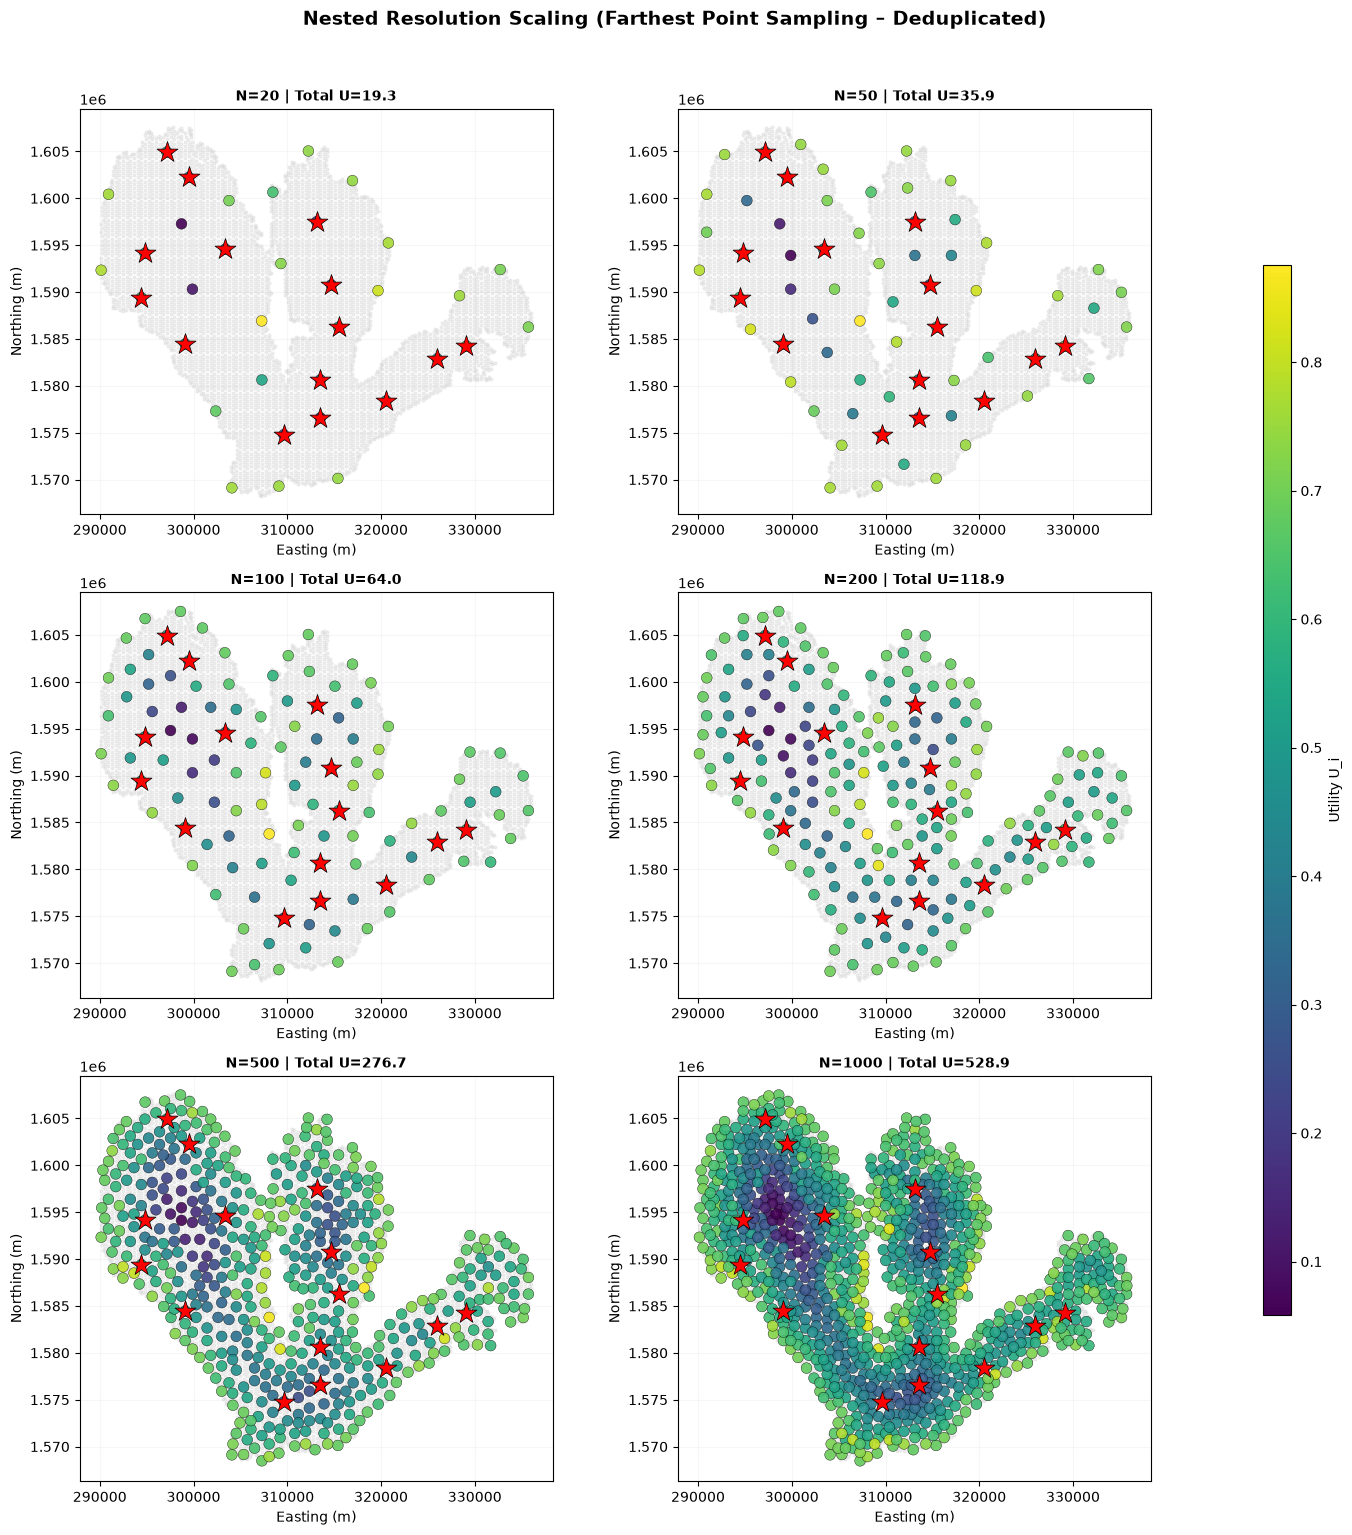

✅ Scaling results loaded and ready. Skipping recomputation.

✅ Nested resolution scaling complete.


In [20]:
#@title CELL 3: NESTED RESOLUTION SCALING (Resumable)
"""
================================================================================
NESTED RESOLUTION SCALING VIA FARTHEST POINT SAMPLING (FPS) – RESUMABLE
================================================================================
- Uses FORCE_RECOMPUTE_SCALING flag from Cell 1.
- Dual storage: local and Drive.
- If scaling_results.pkl exists, loads and skips FPS.
- Generates nested grid plots from loaded data.
================================================================================
"""

import os
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from pathlib import Path
import shapely
from shapely.geometry import Point
from tqdm.notebook import tqdm
import shutil

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------
CONFIG = {
    "target_sizes": [20, 50, 100, 200, 500, 1000],
    "pool_size_estimate": 10000,
    "N_existing": None,  # None = use real existing stations
}

# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# RESUME LOGIC
# -----------------------------------------------------------------------------
scaling_path_local = LOCAL_CACHE / "scaling_results.pkl"
scaling_path_drive = OUTPUT_DIR / "scaling_results.pkl"
scaling_results = None

if not FORCE_RECOMPUTE_SCALING:
    if scaling_path_local.exists():
        print("📂 Loading scaling results from local cache...")
        with open(scaling_path_local, "rb") as f:
            scaling_results = pickle.load(f)
    elif scaling_path_drive.exists():
        print("📂 Loading scaling results from Drive (copying to local)...")
        shutil.copy(scaling_path_drive, scaling_path_local)
        with open(scaling_path_local, "rb") as f:
            scaling_results = pickle.load(f)

if scaling_results is not None:
    print(f"✅ Loaded scaling results for tiers: {sorted(scaling_results.keys())}")
    # Unpack the first tier to get metadata (coords, U, etc.)
    first_N = next(iter(scaling_results))
    first_res = scaling_results[first_N]
    n_free = len(first_res["free_master_indices"])
    n_fixed = len(first_res["M_orig_indices"])
    print(f"   Free sites in smallest tier: {n_free}, Fixed: {n_fixed}")
    print("   Tiers summary:")
    for N, res in sorted(scaling_results.items()):
        print(f"      N={N}: free={len(res['free_master_indices'])}, fixed={len(res['M_orig_indices'])}, total={len(res['coords'])}")

    # Load master data if needed (should already be defined from Cell 2)
    # We need coords and U from master to plot the background.
    # They are already in namespace from Cell 2.

    # Recreate plots from loaded data
    print("\n📊 Plotting nested candidate grids from loaded data...")
    tiers = sorted(scaling_results.keys())
    n_tiers = len(tiers)
    cols = 2
    rows = int(np.ceil(n_tiers / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, N in zip(axes, tiers):
        res = scaling_results[N]
        coords_tier = res["coords"]
        U_tier = res["U"]
        M_tier = res["M_indices"]

        ax.scatter(coords[:, 0], coords[:, 1], c="lightgray", s=4, alpha=0.35, zorder=0)
        sc = ax.scatter(coords_tier[:, 0], coords_tier[:, 1],
                        c=U_tier, cmap="viridis", s=60,
                        edgecolor="k", linewidth=0.3, alpha=0.9, zorder=2)
        if len(M_tier) > 0:
            ax.scatter(coords_tier[M_tier, 0], coords_tier[M_tier, 1],
                       c="red", marker="*", s=250, edgecolor="black",
                       linewidth=0.5, zorder=5, label="Existing")
        ax.set_title(f"N={N} | Total U={U_tier.sum():.1f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        ax.set_aspect("equal")
        ax.grid(alpha=0.1)

    for ax in axes[n_tiers:]:
        ax.axis("off")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min(r['U'].min() for r in scaling_results.values()),
                                                                  vmax=max(r['U'].max() for r in scaling_results.values())))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label="Utility U_i")

    plt.suptitle("Nested Resolution Scaling (Farthest Point Sampling – Deduplicated)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

    # We are done – skip recomputation
    print("✅ Scaling results loaded and ready. Skipping recomputation.")
    # Ensure scaling_results is defined
    pass

else:
    # -------------------------------------------------------------------------
    # COMPUTE FROM SCRATCH (original code)
    # -------------------------------------------------------------------------
    print("🔄 Scaling results not found or FORCE_RECOMPUTE_SCALING=True. Computing from scratch...")

    # ---- LOAD MASTER DATA (already in memory from Cell 2) ----
    # coords, U, water_polygon, M_indices, bbox, n_sites, M_set_global are already defined.

    print("📦 Master data loaded.")
    print(f"   Total master sites: {n_sites}")
    print(f"   Existing stations: {len(M_indices)}")
    print(f"   BBox: {bbox}")

    # ---- STEP 1: GENERATE DENSE HEX POOL ----
    def generate_hex_centroids_bbox(bbox, target_n):
        xmin, ymin, xmax, ymax = bbox
        width = xmax - xmin
        height = ymax - ymin
        area = width * height
        hex_area = area / target_n
        spacing = np.sqrt(hex_area / (np.sqrt(3) / 2.0))
        dx = spacing
        dy = spacing * (np.sqrt(3) / 2.0)

        cols = int(np.ceil(width / dx)) + 1
        rows = int(np.ceil(height / dy)) + 1

        centroids = []
        for r in range(rows):
            y = ymin + r * dy
            if y > ymax:
                continue
            shift = 0.5 * dx if (r % 2 == 1) else 0.0
            for c in range(cols):
                x = xmin + c * dx + shift
                if x > xmax:
                    continue
                centroids.append([x, y])
        return np.array(centroids)

    print("\n🔹 Generating dense hex pool...")
    pool_raw = generate_hex_centroids_bbox(bbox, CONFIG["pool_size_estimate"])
    print(f"   Raw pool size: {len(pool_raw):,}")

    shapely.prepare(water_polygon)
    pool_water = []
    for pt in tqdm(pool_raw, desc="Filtering water points"):
        if water_polygon.contains(Point(pt)):
            pool_water.append(pt)
    pool_coords = np.array(pool_water, dtype=float)
    print(f"   Pool points inside water: {len(pool_coords):,}")

    # ---- STEP 2: MAP POOL POINTS TO NEAREST MASTER CENTROID ----
    master_tree = cKDTree(coords)
    dist, pool_to_master = master_tree.query(pool_coords, k=1)
    pool_to_master = pool_to_master.flatten().astype(int)

    free_mask = ~np.isin(pool_to_master, list(M_set_global))
    pool_to_master_free = pool_to_master[free_mask]

    unique_master_indices, unique_inverse = np.unique(pool_to_master_free, return_inverse=True)
    unique_master_coords = coords[unique_master_indices]
    unique_U = U[unique_master_indices]

    print(f"   Pool points mapped to free master indices (raw): {len(pool_to_master_free):,}")
    print(f"   Unique free master indices after deduplication: {len(unique_master_indices):,}")

    # ---- STEP 3: FARTHEST POINT SAMPLING ----
    print("\n🔹 Running Farthest Point Sampling on deduplicated master sites (seeded with existing stations)...")
    seed_coords = coords[list(M_set_global)]
    n_select = 1000

    seed_tree = cKDTree(seed_coords)
    min_dist = seed_tree.query(unique_master_coords, k=1)[0].flatten()

    selected_indices = []
    selected_master_indices = []

    for _ in tqdm(range(n_select), desc="FPS iterations (unique sites)"):
        idx = np.argmax(min_dist)
        selected_indices.append(idx)
        selected_master_indices.append(unique_master_indices[idx])

        new_point = unique_master_coords[idx]
        dist_to_new = np.linalg.norm(unique_master_coords - new_point, axis=1)
        min_dist = np.minimum(min_dist, dist_to_new)
        min_dist[idx] = -1.0

    print(f"   Selected {len(selected_master_indices)} unique free points via FPS.")

    # ---- STEP 4: BUILD NESTED TIERS ----
    print("\n🔹 Building nested tiers for exact target sizes...")
    scaling_results = {}

    for N in CONFIG["target_sizes"]:
        free_master_indices = selected_master_indices[:N]
        free_coords = coords[free_master_indices]
        free_U = U[free_master_indices]

        all_master_indices = list(free_master_indices) + M_indices
        all_coords = np.vstack([free_coords, coords[M_indices]])
        all_U = np.concatenate([free_U, U[M_indices]])

        M_tier = list(range(N, N + len(M_indices)))
        snapped_indices = np.array(all_master_indices, dtype=int)

        scaling_results[N] = {
            "coords": all_coords,
            "U": all_U,
            "M_indices": M_tier,
            "M_orig_indices": M_indices,
            "snapped_indices": snapped_indices,
            "free_master_indices": free_master_indices,
        }

        print(f"   N={N:4d}: free={N}, fixed={len(M_indices)}, total={len(all_coords)}")

    # ---- STEP 5: PLOT ----
    print("\n📊 Plotting nested candidate grids...")
    tiers = sorted(scaling_results.keys())
    n_tiers = len(tiers)
    cols = 2
    rows = int(np.ceil(n_tiers / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, N in zip(axes, tiers):
        res = scaling_results[N]
        coords_tier = res["coords"]
        U_tier = res["U"]
        M_tier = res["M_indices"]

        ax.scatter(coords[:, 0], coords[:, 1], c="lightgray", s=4, alpha=0.35, zorder=0)
        sc = ax.scatter(coords_tier[:, 0], coords_tier[:, 1],
                        c=U_tier, cmap="viridis", s=60,
                        edgecolor="k", linewidth=0.3, alpha=0.9, zorder=2)
        if len(M_tier) > 0:
            ax.scatter(coords_tier[M_tier, 0], coords_tier[M_tier, 1],
                       c="red", marker="*", s=250, edgecolor="black",
                       linewidth=0.5, zorder=5, label="Existing")
        ax.set_title(f"N={N} | Total U={U_tier.sum():.1f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        ax.set_aspect("equal")
        ax.grid(alpha=0.1)

    for ax in axes[n_tiers:]:
        ax.axis("off")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min(r['U'].min() for r in scaling_results.values()),
                                                                  vmax=max(r['U'].max() for r in scaling_results.values())))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label="Utility U_i")

    plt.suptitle("Nested Resolution Scaling (Farthest Point Sampling – Deduplicated)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

    # ---- STEP 6: SAVE ----
    with open(scaling_path_local, "wb") as f:
        pickle.dump(scaling_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(scaling_path_drive, "wb") as f:
        pickle.dump(scaling_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"✅ Cached deduplicated scaling results to {scaling_path_local} and {scaling_path_drive}")

print("\n✅ Nested resolution scaling complete.")


🔗 GENERATING SPARSE QUBO + MIQP DATA PER RESOLUTION TIER (Resumable, Config‑Aware)


Tiers:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Loaded instance data for N=20 (config hash: 241358d8)
✅ Loaded instance data for N=50 (config hash: 241358d8)
✅ Loaded instance data for N=100 (config hash: 241358d8)
✅ Loaded instance data for N=200 (config hash: 241358d8)
✅ Loaded instance data for N=500 (config hash: 241358d8)
✅ Loaded instance data for N=1000 (config hash: 241358d8)
🚀 All QUBO + MIQP data saved successfully.

📊 Plotting landmass-aware graph edges per tier (L_c edges only)...


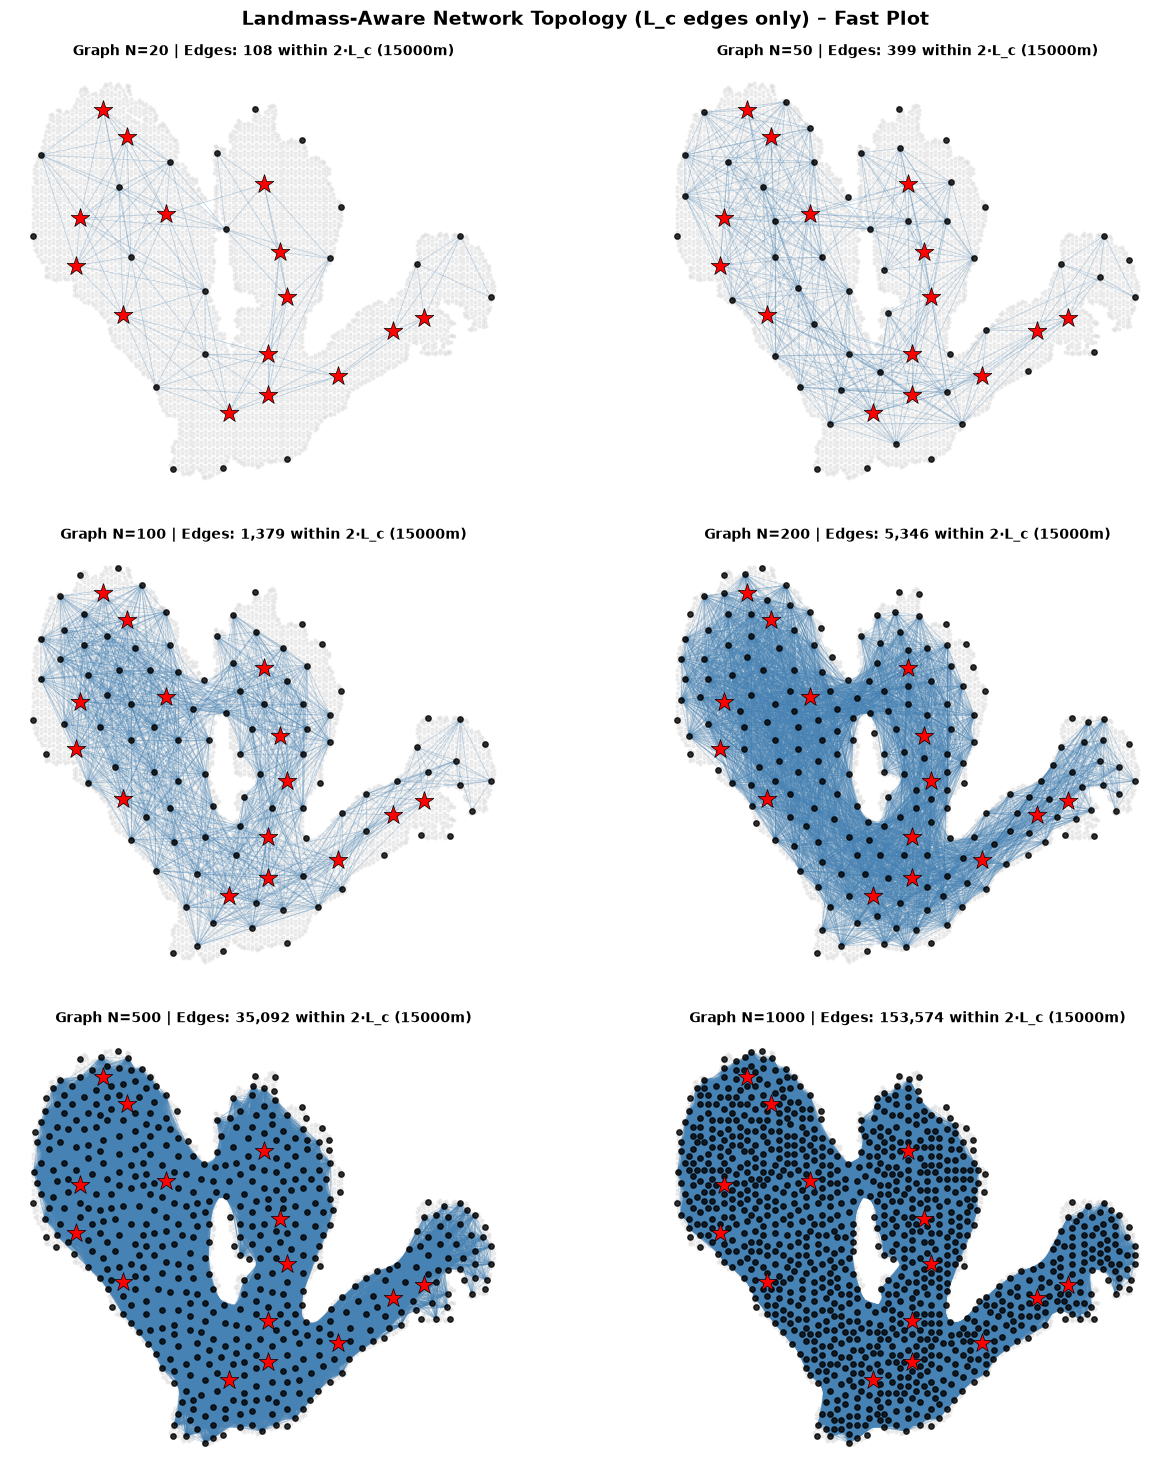

✅ Cell 4 complete.


In [23]:
#@title CELL 4: GENERATE SPARSE QUBO + MIQP DATA (Resumable, Config‑Aware, Fast Plotting)
"""
================================================================================
REVISION: Resumable – loads per‑tier instance_data_N{N}_{config_hash}.pkl if available.
- Uses FORCE_RECOMPUTE_QUBO flag from Cell 1.
- Dual storage: local and Drive.
- Config hash in filename invalidates on QUBO parameter changes.
- Backward‑compatible: falls back to unhashed filenames if hashed missing.
- Stores both valid_edges (D_max) and valid_edges_lc (2*L_c) for plotting.
- Connectivity plots use LineCollection for speed and plot only L_c edges.
================================================================================
"""
import os
import pickle
import time
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree
import shapely
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
import jijmodeling as jm
from tqdm.notebook import tqdm
import shutil
import warnings
import hashlib
import json

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# LOAD CONFIG AND HASH (from Cell 2)
# -----------------------------------------------------------------------------
try:
    # These are already defined in Cell 2
    MASTER_QUBO_CONFIG
    config_hash
except NameError:
    print("⚠️ MASTER_QUBO_CONFIG or config_hash not found; using defaults.")
    MASTER_QUBO_CONFIG = {
        "L_c": 7500.0,
        "L_w": 1000.0,
        "Beta": 1.0,
        "Delta": 1.0,
        "Current_vector": (1.0, 0.0),
        "K": 5,
        "D_max_buffer": 1.15,
    }
    config_str = json.dumps(MASTER_QUBO_CONFIG, sort_keys=True)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    print(f"🔑 Generated config hash: {config_hash}")

# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# LOAD MASTER DATA (hashed version from Cell 2)
# -----------------------------------------------------------------------------
# First try from namespace (if Cell 2 already ran)
try:
    coords_master = coords
    U_master = U
    M_indices_master = M_indices
    water_polygon = water_polygon
    global_D_max = metadata["master_D_max"]
except NameError:
    print("⚠️ Master data not in namespace; loading hashed file...")
    master_path_local = LOCAL_CACHE / f"master_real_{config_hash}.pkl"
    if not master_path_local.exists():
        master_path_local = OUTPUT_DIR / f"master_real_{config_hash}.pkl"
    if not master_path_local.exists():
        # Fallback to unhashed (backward compatibility)
        master_path_local = LOCAL_CACHE / "master_real.pkl"
        if not master_path_local.exists():
            master_path_local = OUTPUT_DIR / "master_real.pkl"
    with open(master_path_local, "rb") as f:
        master_data = pickle.load(f)
    coords_master = master_data["coords"]
    U_master = master_data["U"]
    M_indices_master = master_data["M_indices"]
    water_polygon = master_data["water_polygon"]
    a_master = master_data["a"]
    Q_master_edges = master_data["Q_edges"]
    metadata = master_data["metadata"]
    global_D_max = metadata["master_D_max"]
    coords = coords_master
    U = U_master
    M_indices = M_indices_master

M_set_global = set(M_indices_master)

# -----------------------------------------------------------------------------
# LOAD SCALING RESULTS (unhashed, from Cell 3)
# -----------------------------------------------------------------------------
try:
    if 'scaling_results' not in dir():
        raise NameError
except NameError:
    print("⚠️ Scaling results not in namespace; loading from file...")
    scaling_path_local = LOCAL_CACHE / "scaling_results.pkl"
    if not scaling_path_local.exists():
        scaling_path_local = OUTPUT_DIR / "scaling_results.pkl"
    with open(scaling_path_local, "rb") as f:
        scaling_results = pickle.load(f)

# -----------------------------------------------------------------------------
# PAIRWISE TERM CALCULATION (extended: returns both D_max and L_c edge sets)
# -----------------------------------------------------------------------------
def compute_pairwise_terms_shape_aware(
    coords: np.ndarray,
    U: np.ndarray,
    M_indices: list,
    water_polygon: shapely.geometry.Polygon,
    L_c: float,
    L_w: float,
    current_vector: tuple,
    global_D_max: float,
    beta: float = 1.0,
    delta: float = 1.0,
) -> dict:
    """
    Returns:
      - linear: dict {orig_idx: coeff}
      - quad_edges: list of (orig_i, orig_j, coeff) with orig_i < orig_j
      - neighbors: dict {orig_idx: list_of_neighbor_orig_indices} (free+fixed)
      - valid_edges: set of (orig_i, orig_j) for connectivity constraint (D_max)
      - valid_edges_lc: set of (orig_i, orig_j) within 2*L_c for plotting
    """
    N_total = coords.shape[0]
    free_indices = [i for i in range(N_total) if i not in M_indices]
    free_set = set(free_indices)
    M_set = set(M_indices)

    tree = cKDTree(coords)
    v_norm = np.linalg.norm(current_vector)
    v_unit = np.array(current_vector) / v_norm

    # ---- Build connectivity graph (within D_max) ----
    valid_edges = set()
    pairs_dmax = tree.query_pairs(r=global_D_max)
    for i, j in pairs_dmax:
        p1, p2 = coords[i], coords[j]
        if not (water_polygon.contains(Point(p1)) and water_polygon.contains(Point(p2))):
            continue
        if water_polygon.contains(LineString([p1, p2])):
            valid_edges.add((i, j))

    # ---- Build L_c edge set (within 2*L_c) for plotting ----
    lc_radius = 2.0 * L_c
    valid_edges_lc = set()
    pairs_lc = tree.query_pairs(r=lc_radius)
    for i, j in pairs_lc:
        p1, p2 = coords[i], coords[j]
        if not (water_polygon.contains(Point(p1)) and water_polygon.contains(Point(p2))):
            continue
        if water_polygon.contains(LineString([p1, p2])):
            valid_edges_lc.add((i, j))

    # Build neighbors dict for free vertices only (including fixed neighbors)
    neighbors = {i: [] for i in free_indices}
    for i, j in valid_edges:
        if i in free_set and j in free_set:
            neighbors[i].append(j)
            neighbors[j].append(i)
        elif i in free_set and j in M_set:
            neighbors[i].append(j)
        elif j in free_set and i in M_set:
            neighbors[j].append(i)
    for i in neighbors:
        neighbors[i] = sorted(set(neighbors[i]))

    # ---- Compute quadratic interactions (within 2*L_c) ----
    raw_quad = {}
    for i, j in pairs_lc:
        p1, p2 = coords[i], coords[j]
        if not (water_polygon.contains(Point(p1)) and water_polygon.contains(Point(p2))):
            continue
        line = LineString([p1, p2])
        if not water_polygon.contains(line):
            continue

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        d = np.sqrt(dx*dx + dy*dy)
        if d == 0:
            continue

        R_ij = max(0.0, 1.0 - d / L_c)
        cos_theta = (dx * v_unit[0] + dy * v_unit[1]) / d
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        W_ij = (np.exp(-d / L_w) * cos_theta) if cos_theta > 0.7071 else 0.0

        cos_theta_ji = (-dx * v_unit[0] + -dy * v_unit[1]) / d
        cos_theta_ji = np.clip(cos_theta_ji, -1.0, 1.0)
        W_ji = (np.exp(-d / L_w) * cos_theta_ji) if cos_theta_ji > 0.7071 else 0.0

        coeff = beta * R_ij + delta * (W_ij + W_ji)
        if abs(coeff) > 1e-12:
            raw_quad[(i, j)] = coeff
            raw_quad[(j, i)] = coeff

    # ---- Build linear terms (absorb fixed stations) ----
    linear = {}
    for i in free_indices:
        val = -U[i]
        for m in M_indices:
            key = (i, m) if i < m else (m, i)
            if key in raw_quad:
                val += raw_quad[key]
        linear[i] = val

    # ---- Build free‑free quadratic edges (i < j) ----
    quad_edges = []
    for i in free_indices:
        for j in free_indices:
            if i < j:
                key = (i, j)
                if key in raw_quad:
                    val = raw_quad[key]
                    if abs(val) > 1e-12:
                        quad_edges.append((i, j, val))

    return {
        "linear": linear,
        "quad_edges": quad_edges,
        "neighbors": neighbors,
        "valid_edges": valid_edges,
        "valid_edges_lc": valid_edges_lc,
    }

# -----------------------------------------------------------------------------
# MIQP MODEL BUILDER (unchanged)
# -----------------------------------------------------------------------------
def build_miqp_problem_sparse(N: int, max_degree: int, num_edges: int) -> jm.Problem:
    problem = jm.Problem("WQM_MIQP_sparse", sense=jm.ProblemSense.MINIMIZE)
    a = problem.Placeholder("a", shape=(N,), dtype=jm.DataType.FLOAT)
    neighbor_indices = problem.Placeholder("neighbor_indices", shape=(N, max_degree), dtype=jm.DataType.NATURAL)
    neighbor_mask = problem.Placeholder("neighbor_mask", shape=(N, max_degree), dtype=jm.DataType.BINARY)
    fixed_neighbors = problem.Placeholder("fixed_neighbors", shape=(N,), dtype=jm.DataType.FLOAT)
    K_total = problem.Placeholder("K_total", ndim=0, dtype=jm.DataType.INTEGER)
    x = problem.BinaryVar("x", shape=(N,))
    linear = jm.sum(jm.product(N), lambda i: a[i[0]] * x[i[0]])
    problem += linear
    if num_edges > 0:
        edges = problem.Placeholder("edges", shape=(num_edges, 2), dtype=jm.DataType.NATURAL)
        Q_vals = problem.Placeholder("Q_vals", shape=(num_edges,), dtype=jm.DataType.FLOAT)
        quad = jm.sum(jm.product(num_edges), lambda e: Q_vals[e[0]] * x[edges[e[0], 0]] * x[edges[e[0], 1]])
        problem += quad
    problem += problem.Constraint("budget", jm.sum(jm.product(N), lambda i: x[i[0]]) == K_total)
    problem += problem.Constraint(
        "connectivity",
        lambda i: x[i] <= fixed_neighbors[i] + jm.sum(
            jm.product(max_degree),
            lambda k: neighbor_mask[i, k[0]] * x[neighbor_indices[i, k[0]]]
        ),
        domain=N
    )
    return problem

# -----------------------------------------------------------------------------
# MAIN LOOP OVER TIERS (Resumable, Config‑Aware)
# -----------------------------------------------------------------------------
print("\n" + "=" * 100)
print("🔗 GENERATING SPARSE QUBO + MIQP DATA PER RESOLUTION TIER (Resumable, Config‑Aware)")
print("=" * 100)

qubo_results = {}  # for plotting
tiers = sorted(scaling_results.keys())

for N in tqdm(tiers, desc="Tiers"):
    # Hashed filename
    instance_name_hashed = f"instance_data_N{N}_{config_hash}.pkl"
    instance_local = LOCAL_CACHE / instance_name_hashed
    instance_drive = OUTPUT_DIR / instance_name_hashed

    # Also check unhashed (backward compatibility)
    instance_name_unhashed = f"instance_data_N{N}.pkl"
    unhashed_local = LOCAL_CACHE / instance_name_unhashed
    unhashed_drive = OUTPUT_DIR / instance_name_unhashed

    loaded = False
    instance_data = None

    # 1. Check if hashed version exists locally or on Drive
    if not FORCE_RECOMPUTE_QUBO:
        if instance_local.exists():
            with open(instance_local, "rb") as f:
                instance_data = pickle.load(f)
            loaded = True
        elif instance_drive.exists():
            print(f"📂 Loading hashed {instance_name_hashed} from Drive (copying to local)...")
            shutil.copy(instance_drive, instance_local)
            with open(instance_local, "rb") as f:
                instance_data = pickle.load(f)
            loaded = True
        # 2. If not found, try unhashed (migration)
        elif unhashed_local.exists():
            print(f"📂 Loading unhashed {instance_name_unhashed} from local (migrating to hashed)...")
            with open(unhashed_local, "rb") as f:
                instance_data = pickle.load(f)
            loaded = True
            # Save as hashed for future
            with open(instance_local, "wb") as f:
                pickle.dump(instance_data, f)
            with open(instance_drive, "wb") as f:
                pickle.dump(instance_data, f)
            print(f"✅ Migrated instance data to {instance_local}")
        elif unhashed_drive.exists():
            print(f"📂 Loading unhashed {instance_name_unhashed} from Drive (migrating to hashed)...")
            shutil.copy(unhashed_drive, unhashed_local)
            with open(unhashed_local, "rb") as f:
                instance_data = pickle.load(f)
            loaded = True
            # Save as hashed
            with open(instance_local, "wb") as f:
                pickle.dump(instance_data, f)
            with open(instance_drive, "wb") as f:
                pickle.dump(instance_data, f)
            print(f"✅ Migrated instance data to {instance_local}")

    if loaded:
        print(f"✅ Loaded instance data for N={N} (config hash: {config_hash})")
        # Extract data for plotting
        if "original_coords" in instance_data:
            coords_plot = instance_data["original_coords"]
        else:
            free_coords = instance_data["coords"]
            fixed_indices = instance_data["fixed_indices"]
            # attempt to reconstruct if possible
            if "original_coords" not in instance_data and "fixed_indices" in instance_data:
                # We can't reconstruct easily; use free coords only
                print(f"⚠️ Cannot reconstruct full coords for N={N}; using free coords only.")
                coords_plot = free_coords
            else:
                coords_plot = instance_data["coords"]
        M_tier = instance_data["fixed_indices"]
        edges_plot = instance_data.get("valid_edges_lc", instance_data.get("valid_edges", set()))
        qubo_results[N] = {
            "edges": edges_plot,
            "coords": coords_plot,
            "M_indices": M_tier,
        }
        continue

    # 3. Compute from scratch
    print(f"🔄 Computing instance for N={N}...")
    t0 = time.perf_counter()

    res = scaling_results[N]
    coords_tier = res["coords"]
    U_tier = res["U"]
    M_tier = res["M_indices"]
    snapped_indices = res["snapped_indices"]

    pair_data = compute_pairwise_terms_shape_aware(
        coords=coords_tier,
        U=U_tier,
        M_indices=M_tier,
        water_polygon=water_polygon,
        L_c=MASTER_QUBO_CONFIG["L_c"],
        L_w=MASTER_QUBO_CONFIG["L_w"],
        current_vector=MASTER_QUBO_CONFIG["Current_vector"],
        global_D_max=global_D_max,
        beta=MASTER_QUBO_CONFIG["Beta"],
        delta=MASTER_QUBO_CONFIG["Delta"],
    )

    linear = pair_data["linear"]
    quad_edges_raw = pair_data["quad_edges"]
    neighbors_dict = pair_data["neighbors"]
    valid_edges = pair_data["valid_edges"]
    valid_edges_lc = pair_data["valid_edges_lc"]

    # Compress to free variables only
    free_indices_orig = list(neighbors_dict.keys())
    free_set = set(free_indices_orig)
    N_free = len(free_indices_orig)
    orig_to_comp = {orig: idx for idx, orig in enumerate(free_indices_orig)}

    a_new = np.array([linear.get(orig, 0.0) for orig in free_indices_orig], dtype=float)

    Q_edges_new = []
    for i, j, val in quad_edges_raw:
        if i in free_set and j in free_set:
            Q_edges_new.append((orig_to_comp[i], orig_to_comp[j], val))

    neighbors_new = [[] for _ in range(N_free)]
    for orig_i, nbrs in neighbors_dict.items():
        ci = orig_to_comp[orig_i]
        for orig_j in nbrs:
            if orig_j in free_set:
                neighbors_new[ci].append(orig_to_comp[orig_j])
    for i in range(N_free):
        neighbors_new[i] = sorted(set(neighbors_new[i]))

    fixed_neighbors_arr = np.zeros(N_free, dtype=int)
    M_set_tier = set(M_tier)
    for ci, orig_i in enumerate(free_indices_orig):
        if any(nbr in M_set_tier for nbr in neighbors_dict[orig_i]):
            fixed_neighbors_arr[ci] = 1

    qsum = np.sum(np.abs(a_new)) + sum(abs(val) for _, _, val in Q_edges_new)

    K = MASTER_QUBO_CONFIG["K"]
    max_degree = max(1, max((len(nbrs) for nbrs in neighbors_new), default=1))
    num_edges = len(Q_edges_new)

    neighbor_indices = np.zeros((N_free, max_degree), dtype=np.int32)
    neighbor_mask = np.zeros((N_free, max_degree), dtype=np.int8)
    for i in range(N_free):
        for k, j in enumerate(neighbors_new[i][:max_degree]):
            neighbor_indices[i, k] = j
            neighbor_mask[i, k] = 1

    a_effective = a_new.copy()

    data_dict = {
        "K_total": int(K),
        "a": a_effective.tolist(),
        "neighbor_indices": neighbor_indices.tolist(),
        "neighbor_mask": neighbor_mask.astype(int).tolist(),
        "fixed_neighbors": fixed_neighbors_arr.tolist(),
    }
    if num_edges > 0:
        edges_list = [[i, j] for i, j, _ in Q_edges_new]
        qvals_list = [float(v) for _, _, v in Q_edges_new]
        data_dict["edges"] = edges_list
        data_dict["Q_vals"] = qvals_list

    instance_data = {
        "N": N_free,
        "K": K,
        "a": a_new,
        "Q_edges": Q_edges_new,
        "neighbors": neighbors_new,
        "fixed_neighbors": fixed_neighbors_arr,
        "coords": coords_tier[free_indices_orig],
        "U": U_tier[free_indices_orig],
        "original_coords": coords_tier,
        "original_U": U_tier,
        "original_indices": free_indices_orig,
        "fixed_indices": M_tier,
        "snapped_indices": snapped_indices,
        "D_max": global_D_max,
        "L_c": MASTER_QUBO_CONFIG["L_c"],
        "L_w": MASTER_QUBO_CONFIG["L_w"],
        "qsum": qsum,
        "valid_edges": valid_edges,
        "valid_edges_lc": valid_edges_lc,
        "miqp_data": data_dict,
        "miqp_params": {
            "max_degree": max_degree,
            "num_edges": num_edges,
        }
    }

    # Save to local and Drive
    with open(instance_local, "wb") as f:
        pickle.dump(instance_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(instance_drive, "wb") as f:
        pickle.dump(instance_data, f, protocol=pickle.HIGHEST_PROTOCOL)

    qubo_results[N] = {
        "edges": valid_edges_lc,
        "coords": coords_tier,
        "M_indices": M_tier,
    }

    dt = (time.perf_counter() - t0) * 1000
    avg_deg = np.mean([len(nbrs) for nbrs in neighbors_new]) if N_free > 0 else 0
    print(f"✅ N={N:<3d} (Free: {N_free:<3d}) | Avg Deg: {avg_deg:<5.1f} | Q_edges: {len(Q_edges_new):<6d} | qsum: {qsum:.2f} | {dt:.1f} ms")

print("=" * 100)
print("🚀 All QUBO + MIQP data saved successfully.")

# -----------------------------------------------------------------------------
# PLOT CONNECTIVITY GRAPHS (using LineCollection, plotting L_c edges)
# -----------------------------------------------------------------------------
print("\n📊 Plotting landmass-aware graph edges per tier (L_c edges only)...")
tiers = sorted(qubo_results.keys())
n_tiers = len(tiers)
cols = 2
rows = int(np.ceil(n_tiers / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for ax, N in zip(axes, tiers):
    tier_coords = qubo_results[N]["coords"]
    edges = qubo_results[N]["edges"]
    M_tier = qubo_results[N]["M_indices"]

    # Master map backdrop
    ax.scatter(coords_master[:, 0], coords_master[:, 1], c="lightgray", s=4, alpha=0.35, zorder=0)

    # Build line segments for LineCollection
    segments = []
    for i, j in edges:
        segments.append([(tier_coords[i, 0], tier_coords[i, 1]),
                         (tier_coords[j, 0], tier_coords[j, 1])])
    if segments:
        lc = mcoll.LineCollection(segments, colors="steelblue", alpha=0.3, linewidth=0.6, zorder=1)
        ax.add_collection(lc)

    # Nodes
    ax.scatter(tier_coords[:, 0], tier_coords[:, 1], c="black", s=15, alpha=0.8, zorder=2)
    if len(M_tier) > 0:
        ax.scatter(tier_coords[M_tier, 0], tier_coords[M_tier, 1],
                   c="red", marker="*", s=200, edgecolor="black", linewidth=0.5, zorder=3)

    ax.set_title(f"Graph N={N} | Edges: {len(edges):,} within 2·L_c ({2*MASTER_QUBO_CONFIG['L_c']:.0f}m)", fontsize=10, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")

for ax in axes[n_tiers:]:
    ax.axis("off")

plt.suptitle("Landmass-Aware Network Topology (L_c edges only) – Fast Plot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("✅ Cell 4 complete.")

🔑 SCIP config hash: 241358d8
✅ Loaded hashed master from local.
✅ Loaded Master Data: N=5417, Q_edges=2045178
Found 6 instance data files:
  instance_data_N20_241358d8.pkl
  instance_data_N50_241358d8.pkl
  instance_data_N100_241358d8.pkl
  instance_data_N200_241358d8.pkl
  instance_data_N500_241358d8.pkl
  instance_data_N1000_241358d8.pkl

🔬 Solving tier N=20
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=20.
  Status: solved
  Tier Energy: -3.301293
  Master Energy: -3.301319
  Feasible: True
  Runtime: 0.0071s


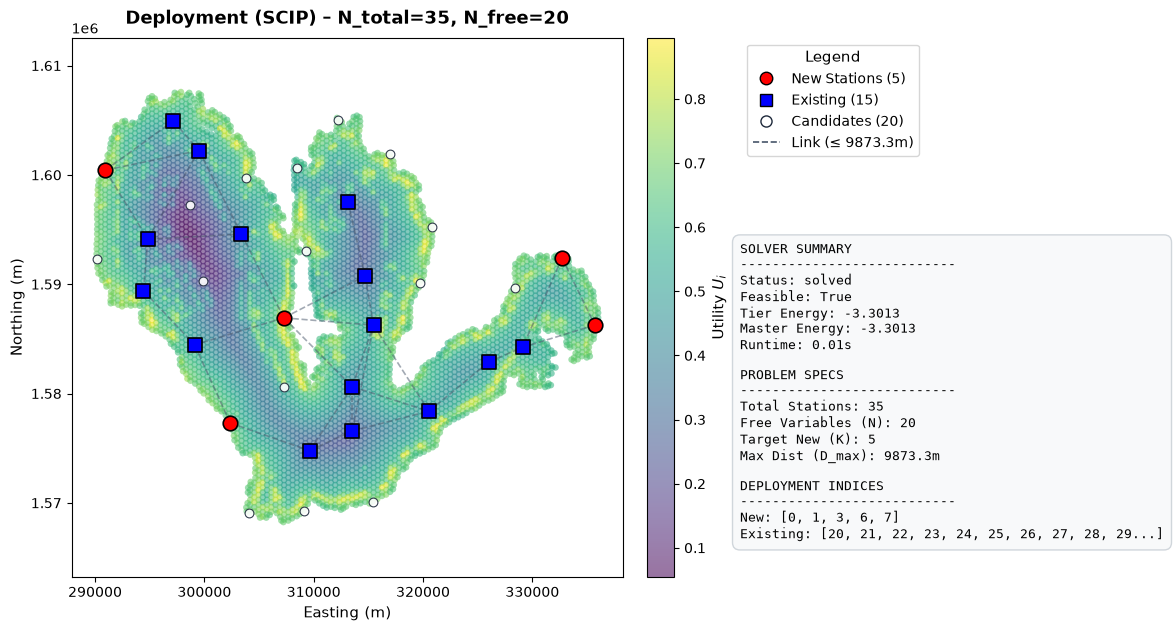

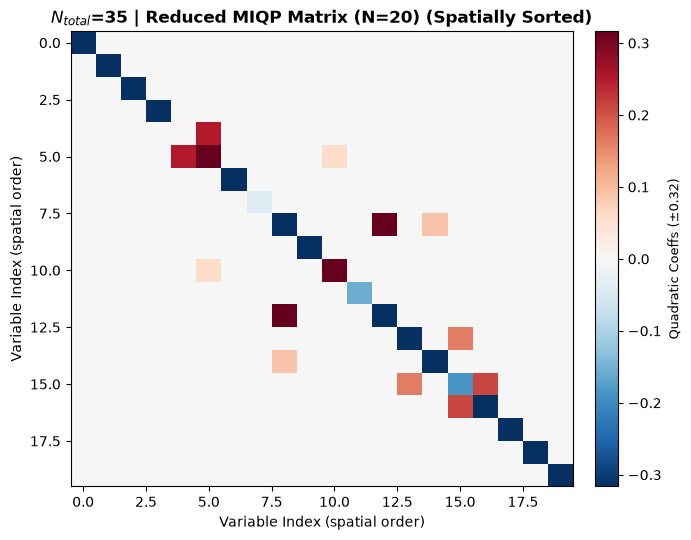


🔬 Solving tier N=50
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=50.
  Status: solved
  Tier Energy: -3.301293
  Master Energy: -3.301319
  Feasible: True
  Runtime: 0.0087s


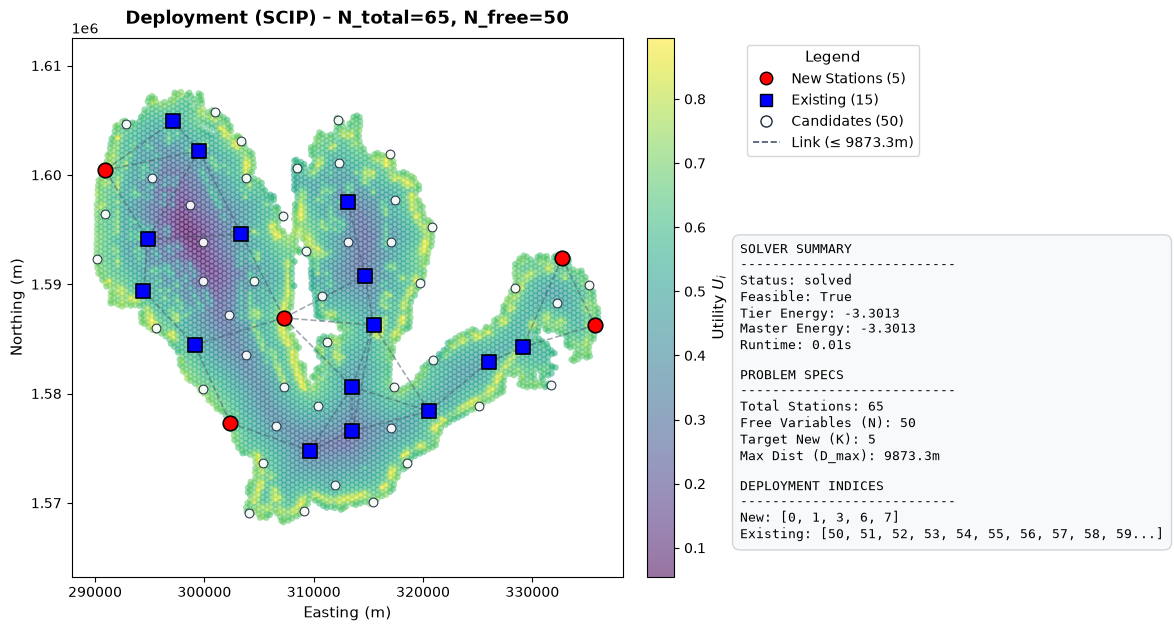

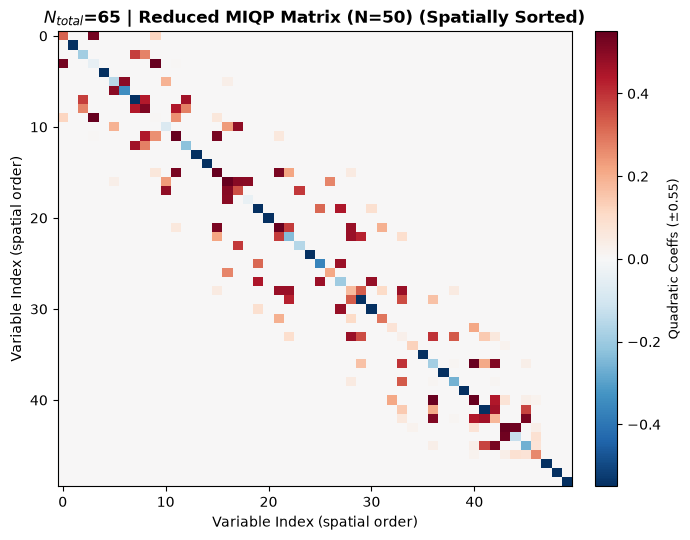


🔬 Solving tier N=100
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=100.
  Status: solved
  Tier Energy: -3.491055
  Master Energy: -3.491078
  Feasible: True
  Runtime: 0.0664s


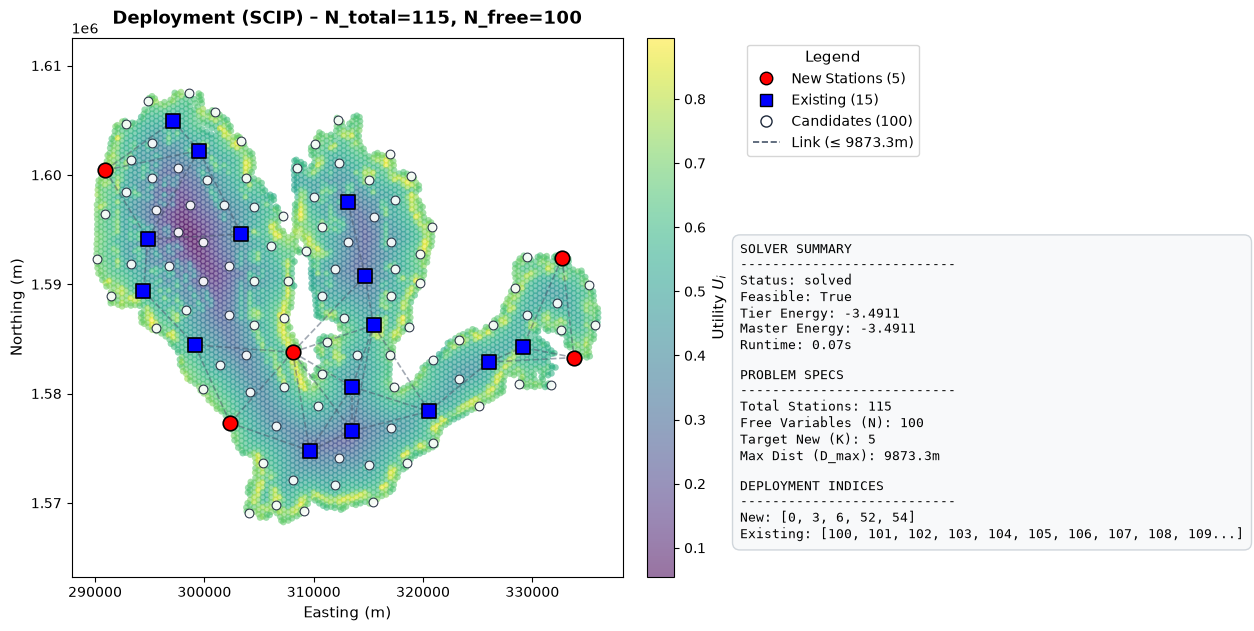

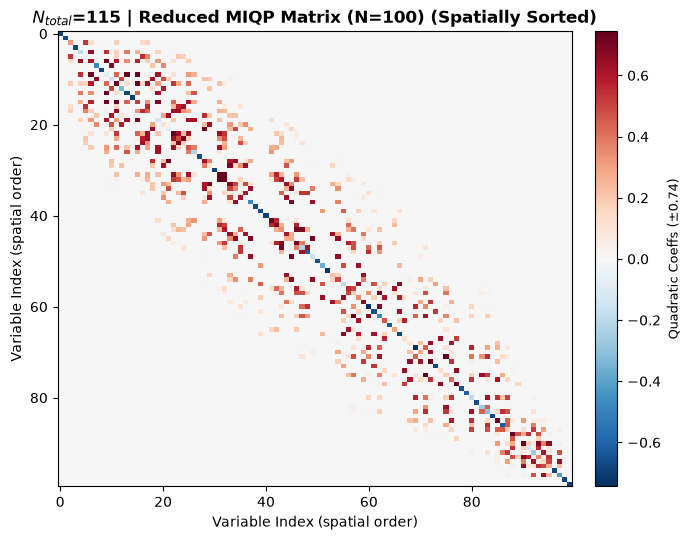


🔬 Solving tier N=200
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=200.
  Status: solved
  Tier Energy: -3.552748
  Master Energy: -3.552772
  Feasible: True
  Runtime: 0.2308s


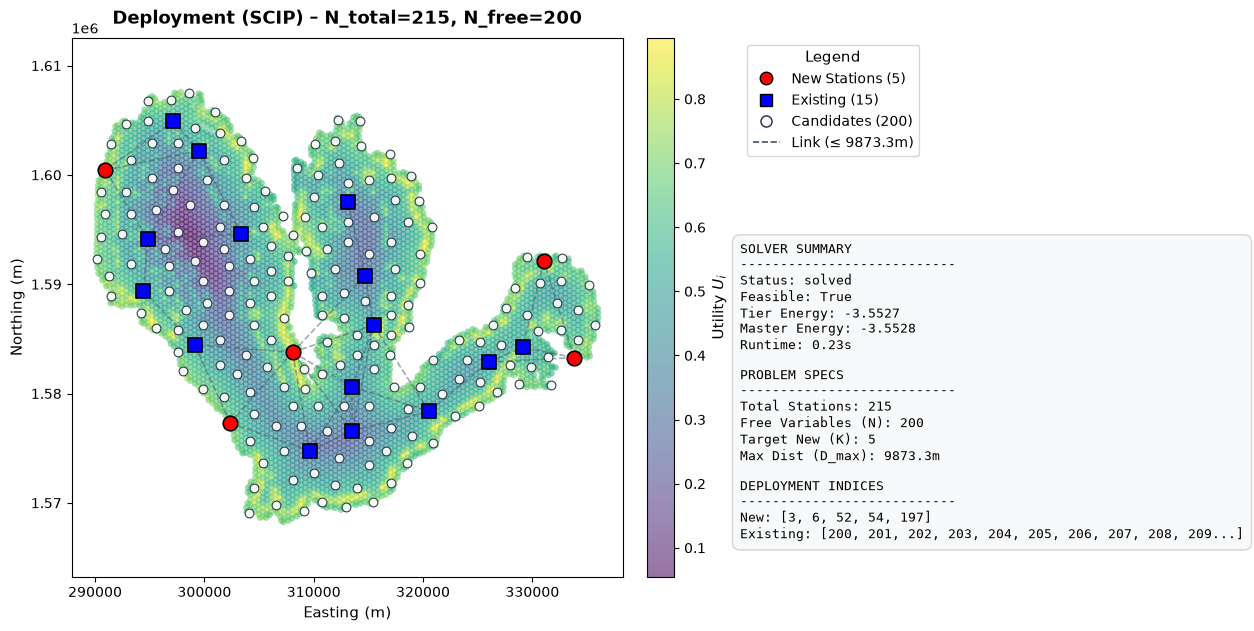

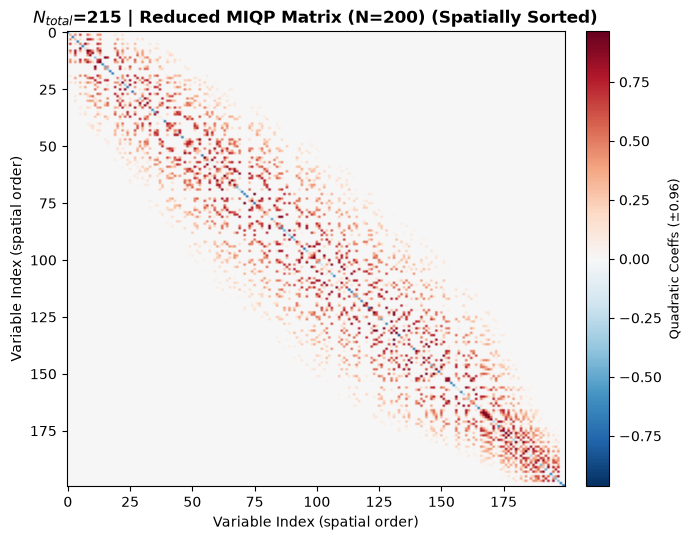


🔬 Solving tier N=500
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=500.
  Status: solved
  Tier Energy: -3.690686
  Master Energy: -3.690690
  Feasible: True
  Runtime: 1.2888s


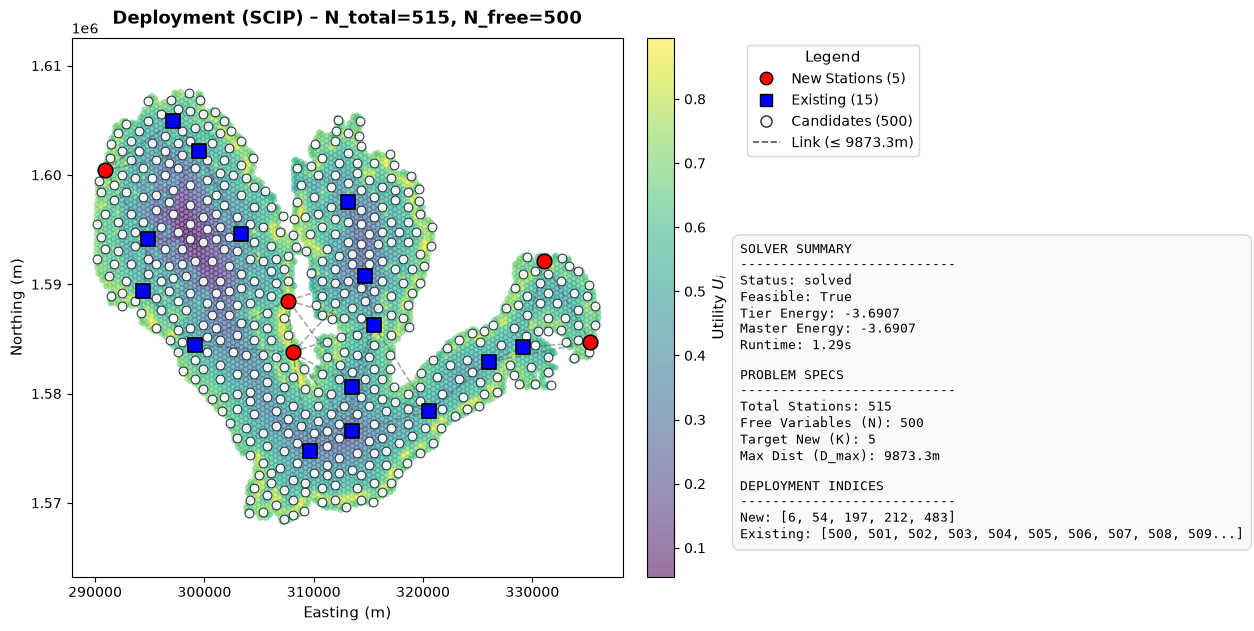

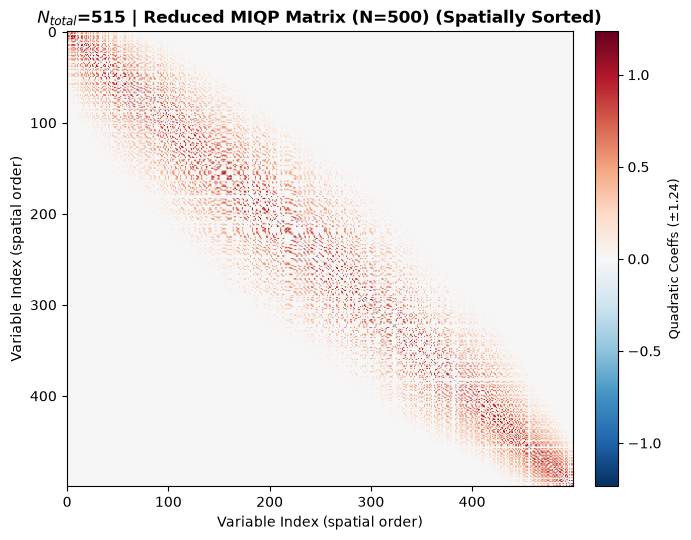


🔬 Solving tier N=1000
🔍 Solving with SCIP from scratch...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


✅ SCIP result saved for N=1000.
  Status: solved
  Tier Energy: -3.690686
  Master Energy: -3.690690
  Feasible: True
  Runtime: 6.8489s


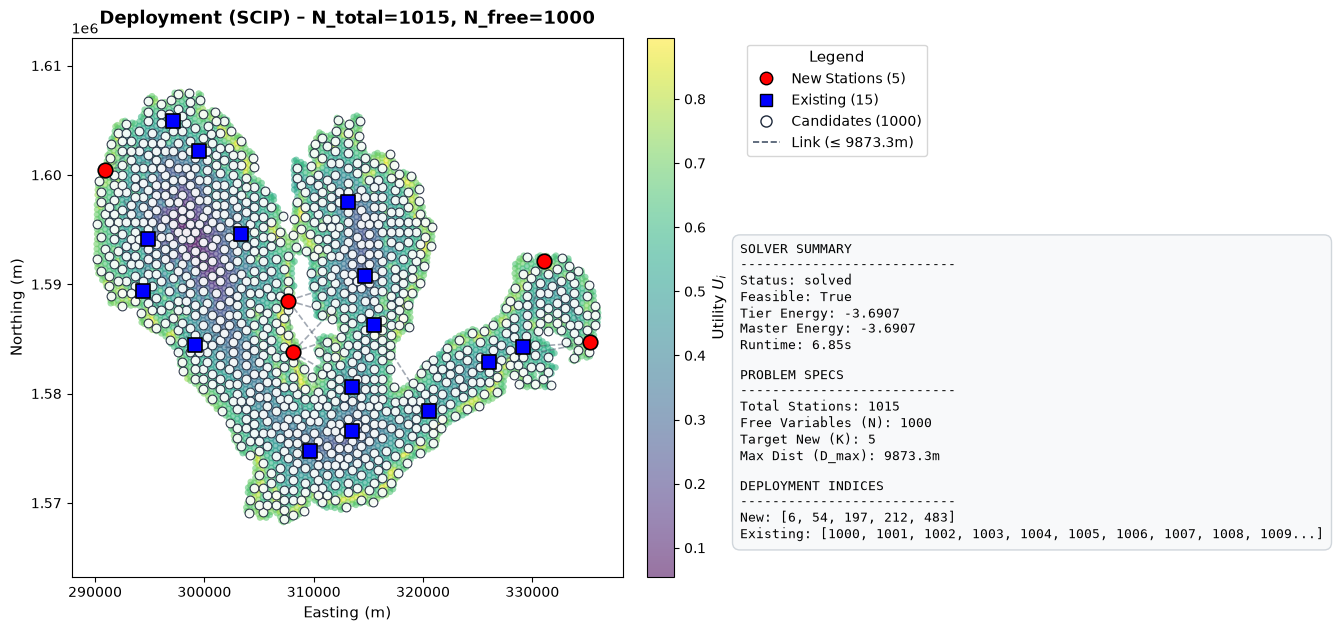

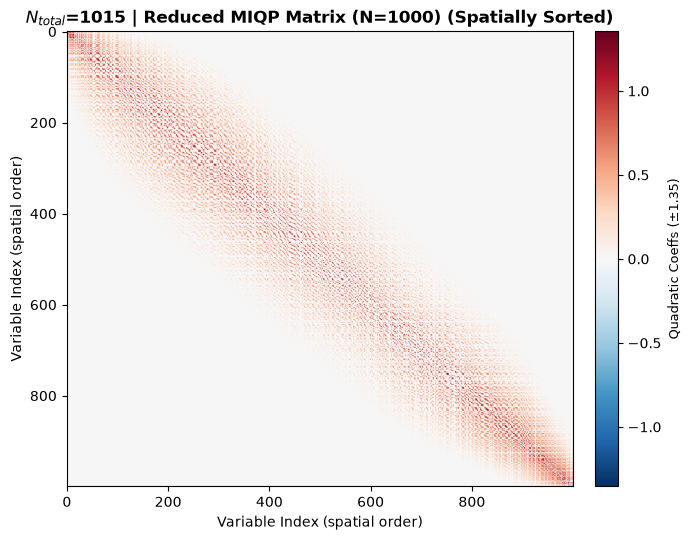


📊 SUMMARY OF ALL SOLVED TIERS (WITH MASTER GRID ENERGY)
N_true   | N_free   | K    | D_max (m)  | Tier Energy   | Master Energy  | Runtime(s)  | Feasible  | Status      
---------------------------------------------------------------------------------------------------------
20       | 20       | 5    | 9873.3     | -3.301293     | -3.301319      | 0.0071      | True      | solved      
50       | 50       | 5    | 9873.3     | -3.301293     | -3.301319      | 0.0087      | True      | solved      
100      | 100      | 5    | 9873.3     | -3.491055     | -3.491078      | 0.0664      | True      | solved      
200      | 200      | 5    | 9873.3     | -3.552748     | -3.552772      | 0.2308      | True      | solved      
500      | 500      | 5    | 9873.3     | -3.690686     | -3.690690      | 1.2888      | True      | solved      
1000     | 1000     | 5    | 9873.3     | -3.690686     | -3.690690      | 6.8489      | True      | solved      

✅ All SCIP solves complete.


In [13]:
#@title 🎯 CELL 5: MIQP SOLVE WITH SCIP (Resumable, Config‑Aware)
"""
================================================================================
MIQP SOLVE WITH SCIP – REAL DATA (MULTI-TIER) – RESUMABLE
================================================================================
- Uses FORCE_RECOMPUTE_SCIP flag from Cell 1.
- Result filenames include config_hash (based on MASTER_QUBO_CONFIG).
- Loads hashed instance files (fallback to unhashed, auto‑migrate).
- Loads hashed master file (fallback to unhashed).
- No greedy fallback – SCIP must find a solution.
- Always generates deployment and matrix plots.
================================================================================
"""

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------
import hashlib
import json

# MASTER_QUBO_CONFIG is already defined in Cell 2.
# If not, we compute it (fallback).
try:
    MASTER_QUBO_CONFIG
except NameError:
    print("⚠️ MASTER_QUBO_CONFIG not found; using defaults.")
    MASTER_QUBO_CONFIG = {
        "L_c": 7500.0,
        "L_w": 1000.0,
        "Beta": 1.0,
        "Delta": 1.0,
        "Current_vector": (1.0, 0.0),
        "K": 5,
        "D_max_buffer": 1.15,
    }
config_str = json.dumps(MASTER_QUBO_CONFIG, sort_keys=True)
config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
print(f"🔑 SCIP config hash: {config_hash}")

# Force recompute flag (defined in Cell 1)
try:
    FORCE_RECOMPUTE_SCIP
except NameError:
    FORCE_RECOMPUTE_SCIP = False
    print("⚠️ FORCE_RECOMPUTE_SCIP not defined; defaulting to False.")

# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------
import os
import sys
import time
import pickle
import re
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
import jijmodeling as jm
import shutil

# OMMX SCIP adapter
try:
    from ommx_pyscipopt_adapter import OMMXPySCIPOptAdapter
    SCIP_AVAILABLE = True
except ImportError:
    SCIP_AVAILABLE = False
    print("⚠️ SCIP not available. Cell 5 will fail.")

warnings.filterwarnings('ignore')

# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# LOAD MASTER DATA (hashed first, fallback to unhashed)
# -----------------------------------------------------------------------------
master_path_hashed_local = LOCAL_CACHE / f"master_real_{config_hash}.pkl"
master_path_hashed_drive = GDRIVE_BASE / f"master_real_{config_hash}.pkl"
master_path_unhashed_local = LOCAL_CACHE / "master_real.pkl"
master_path_unhashed_drive = GDRIVE_BASE / "master_real.pkl"

master_data = None

# 1. Try hashed local
if master_path_hashed_local.exists():
    with open(master_path_hashed_local, "rb") as f:
        master_data = pickle.load(f)
    print("✅ Loaded hashed master from local.")
elif master_path_hashed_drive.exists():
    print("📂 Loading hashed master from Drive (copying to local)...")
    shutil.copy(master_path_hashed_drive, master_path_hashed_local)
    with open(master_path_hashed_local, "rb") as f:
        master_data = pickle.load(f)
    print("✅ Loaded hashed master from Drive.")
# 2. If not found, try unhashed (backward compatibility)
elif master_path_unhashed_local.exists():
    print("📂 Loading unhashed master from local (migrating to hashed)...")
    with open(master_path_unhashed_local, "rb") as f:
        master_data = pickle.load(f)
    # Save as hashed
    with open(master_path_hashed_local, "wb") as f:
        pickle.dump(master_data, f)
    with open(master_path_hashed_drive, "wb") as f:
        pickle.dump(master_data, f)
    print("✅ Migrated master to hashed version.")
elif master_path_unhashed_drive.exists():
    print("📂 Loading unhashed master from Drive (migrating to hashed)...")
    shutil.copy(master_path_unhashed_drive, master_path_unhashed_local)
    with open(master_path_unhashed_local, "rb") as f:
        master_data = pickle.load(f)
    with open(master_path_hashed_local, "wb") as f:
        pickle.dump(master_data, f)
    with open(master_path_hashed_drive, "wb") as f:
        pickle.dump(master_data, f)
    print("✅ Migrated master to hashed version.")

if master_data is None:
    raise FileNotFoundError("Master data not found. Run Cell 2 first.")

a_master = master_data["a"]
Q_master_edges = master_data["Q_edges"]
U_master = master_data["U"]
coords_master = master_data["coords"]
M_indices_master = master_data["M_indices"]
print(f"✅ Loaded Master Data: N={len(a_master)}, Q_edges={len(Q_master_edges)}")

# -----------------------------------------------------------------------------
# HELPER FUNCTIONS (sparse energy, feasibility)
# -----------------------------------------------------------------------------
def compute_energy_sparse(x: np.ndarray, a: np.ndarray, Q_edges: list) -> float:
    x = np.asarray(x, dtype=bool)
    energy = np.dot(a, x.astype(float))
    for i, j, val in Q_edges:
        if x[i] and x[j]:
            energy += val
    return float(energy)

def check_feasibility_sparse(x, neighbors, K, fixed_neighbors=None):
    x = np.asarray(x, dtype=bool)
    selected = np.where(x)[0]
    num_selected = len(selected)
    budget_ok = (num_selected == K)

    connectivity_ok = True
    isolated_indices = []
    for i in selected:
        has_free = any(x[j] for j in neighbors[i])
        has_fixed = False
        if not has_free and fixed_neighbors is not None:
            if isinstance(fixed_neighbors, (list, np.ndarray)):
                has_fixed = bool(fixed_neighbors[i])
            elif isinstance(fixed_neighbors, dict):
                has_fixed = len(fixed_neighbors.get(i, [])) > 0
            else:
                has_fixed = False
        if not (has_free or has_fixed):
            connectivity_ok = False
            isolated_indices.append(i)

    feasible = budget_ok and connectivity_ok
    return {
        "feasible": feasible,
        "budget_ok": budget_ok,
        "connectivity_ok": connectivity_ok,
        "num_selected": num_selected,
        "isolated_indices": isolated_indices,
    }

# -----------------------------------------------------------------------------
# MIQP PROBLEM BUILDER (same as Cell 4)
# -----------------------------------------------------------------------------
def build_miqp_problem_sparse(N: int, max_degree: int, num_edges: int) -> jm.Problem:
    problem = jm.Problem("WQM_MIQP_sparse", sense=jm.ProblemSense.MINIMIZE)
    a = problem.Placeholder("a", shape=(N,), dtype=jm.DataType.FLOAT)
    neighbor_indices = problem.Placeholder("neighbor_indices", shape=(N, max_degree), dtype=jm.DataType.NATURAL)
    neighbor_mask = problem.Placeholder("neighbor_mask", shape=(N, max_degree), dtype=jm.DataType.BINARY)
    fixed_neighbors = problem.Placeholder("fixed_neighbors", shape=(N,), dtype=jm.DataType.FLOAT)
    K_total = problem.Placeholder("K_total", ndim=0, dtype=jm.DataType.INTEGER)
    x = problem.BinaryVar("x", shape=(N,))
    linear = jm.sum(jm.product(N), lambda i: a[i[0]] * x[i[0]])
    problem += linear
    if num_edges > 0:
        edges = problem.Placeholder("edges", shape=(num_edges, 2), dtype=jm.DataType.NATURAL)
        Q_vals = problem.Placeholder("Q_vals", shape=(num_edges,), dtype=jm.DataType.FLOAT)
        quad = jm.sum(jm.product(num_edges), lambda e: Q_vals[e[0]] * x[edges[e[0], 0]] * x[edges[e[0], 1]])
        problem += quad
    problem += problem.Constraint("budget", jm.sum(jm.product(N), lambda i: x[i[0]]) == K_total)
    problem += problem.Constraint(
        "connectivity",
        lambda i: x[i] <= fixed_neighbors[i] + jm.sum(
            jm.product(max_degree),
            lambda k: neighbor_mask[i, k[0]] * x[neighbor_indices[i, k[0]]]
        ),
        domain=N
    )
    return problem

# -----------------------------------------------------------------------------
# SCIP SOLVER WRAPPER (no fallback)
# -----------------------------------------------------------------------------
def solve_scip_sparse(instance_data, verbose=False):
    if not SCIP_AVAILABLE:
        raise RuntimeError("SCIP not available.")

    N = instance_data["N"]
    K = instance_data["K"]
    a = np.asarray(instance_data["a"])
    Q_edges = instance_data["Q_edges"]
    neighbors = instance_data["neighbors"]
    fixed_neighbors = instance_data.get("fixed_neighbors", None)

    miqp_data = instance_data["miqp_data"]
    miqp_params = instance_data["miqp_params"]
    max_degree = miqp_params["max_degree"]
    num_edges = miqp_params["num_edges"]

    problem = build_miqp_problem_sparse(N, max_degree, num_edges)
    miqp_instance = problem.eval(miqp_data)

    start = time.perf_counter()
    try:
        adapter = OMMXPySCIPOptAdapter(miqp_instance)
        model = adapter.solver_input
        model.setParam('limits/gap', 0.0)
        model.setParam('limits/absgap', 0.0)
        model.setParam('display/verblevel', 4 if verbose else 0)
        try:
            import pyscipopt
            model.setEmphasis(pyscipopt.SCIP_PARAMEMPHASIS.OPTIMALITY, quiet=True)
        except Exception:
            pass
        model.optimize()
        scip_status = model.getStatus()
        solution = adapter.decode(model)
    except AttributeError:
        solution = OMMXPySCIPOptAdapter.solve(miqp_instance)
        scip_status = "solved"
    except Exception as e:
        raise RuntimeError(f"SCIP solver error: {e}")

    runtime = time.perf_counter() - start

    if solution is None:
        raise RuntimeError("SCIP returned no solution.")

    # Round solution
    x_sol = np.zeros(N, dtype=int)
    if hasattr(solution, "decision_variables_df"):
        df = solution.decision_variables_df
        x_df = df[df["name"] == "x"]
        for _, row in x_df.iterrows():
            if row["value"] > 0.5:
                subs = row["subscripts"]
                idx = subs[0] if isinstance(subs, (tuple, list)) and len(subs) > 0 else int(subs)
                if 0 <= idx < N:
                    x_sol[idx] = 1
    else:
        if hasattr(solution, "state") and hasattr(solution.state, "entries"):
            for var_id, value in solution.state.entries.items():
                if isinstance(var_id, tuple) and var_id[0] == "x":
                    idx = var_id[1]
                    if 0 <= idx < N:
                        x_sol[idx] = int(round(value))

    tier_energy = compute_energy_sparse(x_sol, a, Q_edges)
    feas_detail = check_feasibility_sparse(x_sol, neighbors, K, fixed_neighbors)
    feasible = feas_detail["feasible"]
    violation_rate = 0.0 if feasible else 1.0

    return {
        "solution": x_sol,
        "energy": tier_energy,
        "runtime": runtime,
        "status": scip_status,
        "feasible": feasible,
        "violation_rate": violation_rate,
        "budget_ok": feas_detail["budget_ok"],
        "connectivity_ok": feas_detail["connectivity_ok"],
    }

# -----------------------------------------------------------------------------
# PLOTTING FUNCTIONS (unchanged)
# -----------------------------------------------------------------------------
def plot_deployment(instance_data, result, save_path=None, show=True, dpi=150):
    coords_full = np.asarray(instance_data["original_coords"])
    D_MAX = instance_data["D_max"]
    fixed_indices = list(instance_data.get("fixed_indices", []))
    free_indices = list(instance_data.get("original_indices", []))
    snapped_indices = instance_data.get("snapped_indices", None)

    N_free = len(free_indices)
    N_total = len(coords_full)

    x_sol = result.get("solution")
    if x_sol is None:
        x_sol = np.zeros(N_free, dtype=int)
    else:
        x_sol = np.asarray(x_sol)

    selected_free_orig = [free_indices[i] for i in np.where(x_sol == 1)[0] if i < len(free_indices)]
    selected_new = [i for i in selected_free_orig if i not in fixed_indices]
    selected_m = fixed_indices
    all_selected = selected_new + selected_m

    if len(coords_master) > 0:
        xmin, ymin = coords_master.min(axis=0)
        xmax, ymax = coords_master.max(axis=0)
    else:
        xmin, ymin = coords_full.min(axis=0)
        xmax, ymax = coords_full.max(axis=0)
    pad_x = max(0.05 * (xmax - xmin), 1.0)
    pad_y = max(0.05 * (ymax - ymin), 1.0)

    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1.3], wspace=0.15)
    ax = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    if len(coords_master) > 0 and U_master is not None:
        sc = ax.scatter(coords_master[:, 0], coords_master[:, 1], c=U_master, cmap='viridis',
                        s=22, alpha=0.55, edgecolor='none', zorder=0, label='Utility Background')
        cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label('Utility $U_i$', fontsize=11)
    else:
        ax.scatter(coords_full[:, 0], coords_full[:, 1], c="#cbd5e1", s=22, alpha=0.6, edgecolor='none', zorder=0, label='_nolegend_')

    for i in range(len(all_selected)):
        for j in range(i + 1, len(all_selected)):
            idx_i, idx_j = all_selected[i], all_selected[j]
            dist = np.linalg.norm(coords_full[idx_i] - coords_full[idx_j])
            if dist <= D_MAX:
                ax.plot([coords_full[idx_i, 0], coords_full[idx_j, 0]],
                        [coords_full[idx_i, 1], coords_full[idx_j, 1]],
                        color='#475569', alpha=0.5, linewidth=1.2, linestyle='--', zorder=1)

    if free_indices:
        candidate_coords = coords_full[free_indices]
        ax.scatter(candidate_coords[:, 0], candidate_coords[:, 1], c='white', s=40,
                   alpha=0.9, edgecolor='#1e293b', linewidth=0.8, label='Candidates', zorder=2)
    if selected_m:
        ax.scatter(coords_full[selected_m, 0], coords_full[selected_m, 1],
                   c='blue', s=110, marker='s', edgecolor='black', linewidth=1.2,
                   label=f'Existing ({len(selected_m)})', zorder=3)
    if selected_new:
        ax.scatter(coords_full[selected_new, 0], coords_full[selected_new, 1],
                   c='red', s=110, marker='o', edgecolor='black', linewidth=1.2,
                   label=f'New ({len(selected_new)})', zorder=4)

    ax.set_xlabel('Easting (m)', fontsize=11)
    ax.set_ylabel('Northing (m)', fontsize=11)
    ax.set_title(f'Deployment (SCIP) – N_total={N_total}, N_free={N_free}', fontsize=13, fontweight='bold', pad=10)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=9, markeredgecolor='black', label=f'New Stations ({len(selected_new)})'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=9, markeredgecolor='black', label=f'Existing ({len(selected_m)})'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8, markeredgecolor='#1e293b', label=f'Candidates ({len(free_indices)})'),
        plt.Line2D([0], [0], color='#475569', linewidth=1.2, linestyle='--', label=f'Link (≤ {D_MAX:.1f}m)')
    ]
    ax_info.legend(handles=handles, loc='upper left', frameon=True, fontsize=10, title="Legend", title_fontsize=11)

    selected_new_str = ', '.join(map(str, selected_new[:10])) + ('...' if len(selected_new) > 10 else '') if selected_new else 'None'
    selected_m_str = ', '.join(map(str, selected_m[:10])) + ('...' if len(selected_m) > 10 else '') if selected_m else 'None'

    info_text = (
        f"SOLVER SUMMARY\n"
        f"---------------------------\n"
        f"Status: {result.get('status', 'N/A')}\n"
        f"Feasible: {result.get('feasible', False)}\n"
        f"Tier Energy: {result.get('energy', np.nan):.4f}\n"
        f"Master Energy: {result.get('master_energy', np.nan):.4f}\n"
        f"Runtime: {result.get('runtime', 0.0):.2f}s\n\n"
        f"PROBLEM SPECS\n"
        f"---------------------------\n"
        f"Total Stations: {N_total}\n"
        f"Free Variables (N): {N_free}\n"
        f"Target New (K): {instance_data.get('K', 0)}\n"
        f"Max Dist (D_max): {D_MAX:.1f}m\n\n"
        f"DEPLOYMENT INDICES\n"
        f"---------------------------\n"
        f"New: [{selected_new_str}]\n"
        f"Existing: [{selected_m_str}]"
    )
    ax_info.text(0.0, 0.62, info_text, transform=ax_info.transAxes, fontsize=9,
                 verticalalignment='top', horizontalalignment='left', family='monospace',
                 bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', alpha=0.95, edgecolor='#ced4da'))

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)

def plot_miqp_matrix_reduced(instance_data, save_path=None, show=True, dpi=150, title_prefix="", sort_by="coords"):
    N = instance_data["N"]
    a = np.asarray(instance_data["a"], dtype=float)
    Q_edges = instance_data.get("Q_edges", [])

    mat = np.zeros((N, N), dtype=float)
    np.fill_diagonal(mat, a)
    for i, j, val in Q_edges:
        mat[i, j] = val
        mat[j, i] = val

    if sort_by == "coords" and "coords" in instance_data:
        coords_free = np.asarray(instance_data["coords"])
        order = np.lexsort((coords_free[:, 0], -coords_free[:, 1]))
        mat = mat[np.ix_(order, order)]
        title_suffix = " (Spatially Sorted)"
    else:
        title_suffix = ""

    off_diag_mask = ~np.eye(N, dtype=bool)
    off_diag_vals = mat[off_diag_mask]
    if len(off_diag_vals) > 0 and np.max(np.abs(off_diag_vals)) > 0:
        max_val = np.max(np.abs(off_diag_vals))
        norm = mcolors.Normalize(vmin=-max_val, vmax=max_val)
        cbar_label = f"Quadratic Coeffs (±{max_val:.2f})"
    else:
        max_val = np.max(np.abs(mat)) if np.max(np.abs(mat)) > 0 else 1.0
        norm = mcolors.Normalize(vmin=-max_val, vmax=max_val)
        cbar_label = "Coefficient Value"

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', norm=norm)
    ax.set_title(f"{title_prefix}Reduced MIQP Matrix (N={N}){title_suffix}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Variable Index (spatial order)" if sort_by == "coords" else "Variable Index", fontsize=10)
    ax.set_ylabel("Variable Index (spatial order)" if sort_by == "coords" else "Variable Index", fontsize=10)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)

# -----------------------------------------------------------------------------
# DISCOVER INSTANCE DATA FILES (hashed first, fallback to unhashed)
# -----------------------------------------------------------------------------
pattern_hashed = re.compile(r"instance_data_N(\d+)_([a-f0-9]{8})\.pkl")
pattern_unhashed = re.compile(r"instance_data_N(\d+)\.pkl")

instance_files = []
# 1. Hashed files
for p in GDRIVE_BASE.glob("instance_data_N*_*.pkl"):
    m = pattern_hashed.match(p.name)
    if m and m.group(2) == config_hash:
        instance_files.append(p)
# 2. If none, try unhashed (fallback)
if not instance_files:
    for p in GDRIVE_BASE.glob("instance_data_N*.pkl"):
        if pattern_unhashed.match(p.name):
            instance_files.append(p)
# Also check local cache
if not instance_files:
    for p in LOCAL_CACHE.glob("instance_data_N*_*.pkl"):
        m = pattern_hashed.match(p.name)
        if m and m.group(2) == config_hash:
            instance_files.append(p)
    if not instance_files:
        for p in LOCAL_CACHE.glob("instance_data_N*.pkl"):
            if pattern_unhashed.match(p.name):
                instance_files.append(p)

if not instance_files:
    raise FileNotFoundError("No instance_data_N*.pkl files found in cache or results.")

# Optionally filter by TARGET_N
try:
    TARGET_N = CONFIG_SA.get("TARGET_N", None)
except NameError:
    TARGET_N = None
if TARGET_N is not None:
    def extract_N(p):
        m = pattern_hashed.match(p.name) or pattern_unhashed.match(p.name)
        if m:
            return int(m.group(1))
        return None
    instance_files = [p for p in instance_files if extract_N(p) == TARGET_N]

# Sort by N
def extract_N_from_path(p):
    m = pattern_hashed.match(p.name) or pattern_unhashed.match(p.name)
    return int(m.group(1)) if m else 0

instance_files.sort(key=extract_N_from_path)
print(f"Found {len(instance_files)} instance data files:")
for p in instance_files:
    print(f"  {p.name}")

# -----------------------------------------------------------------------------
# SOLVE EACH TIER
# -----------------------------------------------------------------------------
all_results = []

for instance_path in instance_files:
    # Extract N from filename
    m = pattern_hashed.match(instance_path.name) or pattern_unhashed.match(instance_path.name)
    if not m:
        print(f"⚠️ Skipping unrecognized file: {instance_path.name}")
        continue
    N_true = int(m.group(1))

    print("\n" + "=" * 70)
    print(f"🔬 Solving tier N={N_true}")
    print("=" * 70)

    # Load instance data
    with open(instance_path, "rb") as f:
        instance_data = pickle.load(f)

    # If unhashed, save as hashed for future
    if pattern_unhashed.match(instance_path.name):
        hashed_name = f"instance_data_N{N_true}_{config_hash}.pkl"
        hashed_local = LOCAL_CACHE / hashed_name
        hashed_drive = GDRIVE_BASE / hashed_name
        with open(hashed_local, "wb") as f:
            pickle.dump(instance_data, f)
        with open(hashed_drive, "wb") as f:
            pickle.dump(instance_data, f)
        print(f"✅ Migrated instance data to hashed: {hashed_local}")
        # Use hashed path for result saving
        instance_path = hashed_local

    N_free = instance_data["N"]
    K = instance_data["K"]
    dmax = instance_data.get("D_max", 0.0)
    fixed_count = len(instance_data["fixed_indices"])
    snapped_indices = instance_data.get("snapped_indices", None)

    # Result filename with config hash
    scip_filename = f"scip_result_N{N_true}_{config_hash}.pkl"
    scip_local = LOCAL_CACHE / scip_filename
    scip_gdrive = GDRIVE_BASE / scip_filename

    # If force recompute, delete existing files
    if FORCE_RECOMPUTE_SCIP:
        for f in [scip_local, scip_gdrive]:
            if f.exists():
                f.unlink()
                print(f"🗑️  Removed {f}")

    # Load cached result if exists
    scip_result = None
    if scip_local.exists():
        print(f"📂 Loading existing SCIP result from local cache: {scip_local}")
        with open(scip_local, "rb") as f:
            scip_result = pickle.load(f)
    elif scip_gdrive.exists():
        print(f"📂 Copying SCIP result from Drive to local: {scip_gdrive} → {scip_local}")
        shutil.copy(scip_gdrive, scip_local)
        with open(scip_local, "rb") as f:
            scip_result = pickle.load(f)

    if scip_result is None:
        print("🔍 Solving with SCIP from scratch...")
        try:
            scip_result = solve_scip_sparse(instance_data, verbose=True)
            scip_result["status"] = "solved"
        except Exception as e:
            print(f"❌ SCIP solver failed: {e}")
            raise  # No fallback

        # Save result
        with open(scip_local, "wb") as f:
            pickle.dump(scip_result, f)
        with open(scip_gdrive, "wb") as f:
            pickle.dump(scip_result, f)
        print(f"✅ SCIP result saved for N={N_true}.")

    # Compute master energy
    master_energy_val = np.nan
    if scip_result.get("solution") is not None and snapped_indices is not None:
        x_sol = np.asarray(scip_result["solution"], dtype=int)
        free_indices = instance_data["original_indices"]
        fixed_indices = instance_data["fixed_indices"]

        x_master = np.zeros(len(a_master), dtype=int)
        N_free_local = len(free_indices)

        for idx, val in enumerate(x_sol):
            if val == 1:
                master_idx = snapped_indices[idx]
                if 0 <= master_idx < len(a_master):
                    x_master[master_idx] = 1

        for k, f_idx in enumerate(fixed_indices):
            master_idx = snapped_indices[N_free_local + k]
            if 0 <= master_idx < len(a_master):
                x_master[master_idx] = 1

        master_energy_val = compute_energy_sparse(x_master, a_master, Q_master_edges)
    scip_result["master_energy"] = master_energy_val

    energy = scip_result["energy"]
    feasible = scip_result["feasible"]
    runtime = scip_result["runtime"]
    status = scip_result.get("status", "unknown")

    print(f"  Status: {status}")
    print(f"  Tier Energy: {energy:.6f}")
    print(f"  Master Energy: {master_energy_val:.6f}")
    print(f"  Feasible: {feasible}")
    print(f"  Runtime: {runtime:.4f}s")

    # ---- PLOTTING ----
    deploy_save_path = LOCAL_CACHE / f"deployment_N{N_true}_{config_hash}.png"
    plot_deployment(instance_data, scip_result, save_path=deploy_save_path, show=True, dpi=150)

    matrix_save_path = LOCAL_CACHE / f"miqp_matrix_N{N_true}_{config_hash}.png"
    plot_miqp_matrix_reduced(instance_data, save_path=matrix_save_path, show=True, dpi=150,
                              title_prefix=f"$N_{{total}}$={len(instance_data['original_coords'])} | ")

    all_results.append({
        "N_true": N_true,
        "N_free": N_free,
        "K": K,
        "fixed_count": fixed_count,
        "D_max": dmax,
        "energy": energy,
        "master_energy": master_energy_val,
        "runtime": runtime,
        "feasible": feasible,
        "status": status,
        "instance_data": instance_data,
        "scip_result": scip_result,
    })

# -----------------------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------------------
print("\n" + "=" * 105)
print("📊 SUMMARY OF ALL SOLVED TIERS (WITH MASTER GRID ENERGY)")
print("=" * 105)
print(f"{'N_true':<8} | {'N_free':<8} | {'K':<4} | {'D_max (m)':<10} | {'Tier Energy':<13} | {'Master Energy':<14} | {'Runtime(s)':<11} | {'Feasible':<9} | {'Status':<12}")
print("-" * 105)
for res in all_results:
    m_energy_str = f"{res['master_energy']:.6f}" if not np.isnan(res['master_energy']) else "N/A"
    print(f"{res['N_true']:<8} | {res['N_free']:<8} | {res['K']:<4} | {res['D_max']:<10.1f} | {res['energy']:<13.6f} | {m_energy_str:<14} | {res['runtime']:<11.4f} | {str(res['feasible']):<9} | {res['status']:<12}")
print("=" * 105)

print("\n✅ All SCIP solves complete.")

In [29]:
#@title 🔬 CELL 6: SA TUNE v4.8 (Resumable, Config‑Aware, Saves Samples)
"""
================================================================================
SA TUNING WITH OPTUNA v4.8 – RESUMABLE, CONFIG‑AWARE, SAVES SAMPLES
================================================================================
- Inlined JijModeling functions (connectivity includes fixed_neighbors).
- Dual SQLite storage: local (fast) + Drive (persistent), periodic sync.
- Study name includes config_hash (from MASTER_QUBO_CONFIG).
- Resumes from existing study automatically.
- Skips already tuned tiers and displays stored results + plots.
- Enhanced tie-break table includes runtime breakdown and variance metrics.
- Continuous violation magnitudes, master energy corrected.
- Saves all SA samples (per trial) to a pickle file for later visualisation.
- Crash‑proof: saves samples incrementally (after each trial) and loads existing.
================================================================================
"""

import sys, os, math, time, pickle, re, json, warnings, shutil, hashlib, ast
from pathlib import Path
from datetime import datetime
import numpy as np
import optuna
import wandb
import openjij as oj
import jijmodeling as jm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------------------------------------------------------
# QUBO CONFIGURATION (reuse from Cell 2)
# -----------------------------------------------------------------------------
try:
    MASTER_QUBO_CONFIG
except NameError:
    print("⚠️ MASTER_QUBO_CONFIG not found; using defaults.")
    MASTER_QUBO_CONFIG = {
        "L_c": 7500.0,
        "L_w": 1000.0,
        "Beta": 1.0,
        "Delta": 1.0,
        "Current_vector": (1.0, 0.0),
        "K": 5,
        "D_max_buffer": 1.15,
    }
config_str = json.dumps(MASTER_QUBO_CONFIG, sort_keys=True)
config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
print(f"🔑 QUBO config hash: {config_hash}")

# -----------------------------------------------------------------------------
# TUNING CONFIGURATION
# -----------------------------------------------------------------------------
CONFIG_SA = {
    "TARGET_N": None,                     # None = tune all discovered tiers
    "NUM_SWEEPS": 1000,
    "NUM_READS": 1024,
    "SYNC_INTERVAL": 5,                   # Sync DB to Drive every N trials
    "WARMUP_TRIALS": 15,
    "MAX_FLOOR_HITS": 10,
    "VARIANCE_TOLERANCE": 0.05,
    "MIN_FEASIBLE_FOR_VARIANCE": 5,
    "FEASIBILITY_RANK_THRESHOLD": 20,
    "TOP_K_ENERGY": 3,
    "ENERGY_TOLERANCE_PCT": 0.5,
    "LAMBDA_LOWER": 0.0001,
    "USE_WANDB": False,  # local default; set True (after `wandb login`) to enable
    "WANDB_PROJECT": "wqm-placement-optimization",
    "LOG_WANDB_TABLE": True,
    "SAVE_SA_SAMPLES": True,               # Set to False to skip saving samples (save space)
}

TARGET_N = CONFIG_SA["TARGET_N"]
NUM_SWEEPS = CONFIG_SA["NUM_SWEEPS"]
NUM_READS = CONFIG_SA["NUM_READS"]
SYNC_INTERVAL = CONFIG_SA["SYNC_INTERVAL"]
WARMUP_TRIALS = CONFIG_SA["WARMUP_TRIALS"]
MAX_FLOOR_HITS = CONFIG_SA["MAX_FLOOR_HITS"]
VARIANCE_TOLERANCE = CONFIG_SA["VARIANCE_TOLERANCE"]
MIN_FEASIBLE_FOR_VARIANCE = CONFIG_SA["MIN_FEASIBLE_FOR_VARIANCE"]
FEASIBILITY_RANK_THRESHOLD = CONFIG_SA["FEASIBILITY_RANK_THRESHOLD"]
TOP_K_ENERGY = CONFIG_SA["TOP_K_ENERGY"]
ENERGY_TOLERANCE_PCT = CONFIG_SA["ENERGY_TOLERANCE_PCT"]
LAMBDA_LOWER = CONFIG_SA["LAMBDA_LOWER"]
USE_WANDB = CONFIG_SA["USE_WANDB"]
WANDB_PROJECT = CONFIG_SA["WANDB_PROJECT"]
LOG_WANDB_TABLE = CONFIG_SA["LOG_WANDB_TABLE"]
SAVE_SA_SAMPLES = CONFIG_SA["SAVE_SA_SAMPLES"]

# Force retune flag (defined in Cell 1)
try:
    FORCE_RETUNE_SA
except NameError:
    FORCE_RETUNE_SA = False
    print("⚠️ FORCE_RETUNE_SA not defined; defaulting to False.")

# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIR = RESULTS_DIR / f"run_{config_hash}"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# INLINED JijModeling FUNCTIONS (unchanged)
# -----------------------------------------------------------------------------
def build_augmented_model() -> jm.Problem:
    problem = jm.Problem("WQM_Augmented", sense=jm.ProblemSense.MINIMIZE)
    N_ph = problem.Length("N")
    K_ph = problem.Length("K")
    a_ph = problem.Float("a", shape=(N_ph,))
    Q_ph = problem.Float("Q", shape=(N_ph, N_ph))
    neigh_ph = problem.Binary("neigh", shape=(N_ph, N_ph))
    fixed_neighbors_ph = problem.Float("fixed_neighbors", shape=(N_ph,))
    x = problem.BinaryVar("x", shape=(N_ph,))
    obj_linear = jm.sum(N_ph, lambda i: a_ph[i] * x[i])
    obj_quad = jm.sum(
        jm.product(N_ph, N_ph).filter(lambda i, j: i < j),
        lambda i, j: Q_ph[i, j] * x[i] * x[j]
    )
    problem += obj_linear + obj_quad
    problem += problem.Constraint("budget", jm.sum(N_ph, lambda i: x[i]) == K_ph)
    problem += problem.Constraint(
        "connectivity",
        lambda i: x[i] <= fixed_neighbors_ph[i] + jm.sum(N_ph, lambda j: neigh_ph[i, j] * x[j]),
        domain=N_ph
    )
    return problem

def get_penalty_weights(instance, lambda_budget: float, lambda_conn: float) -> dict:
    penalty_weights = {}
    for c in instance.constraints:
        if c.name == "budget":
            penalty_weights[c.id] = lambda_budget
        elif c.name == "connectivity":
            penalty_weights[c.id] = lambda_conn
    if "budget" not in [c.name for c in instance.constraints]:
        raise ValueError("Budget constraint not found in instance!")
    if "connectivity" not in [c.name for c in instance.constraints]:
        raise ValueError("Connectivity constraint not found in instance!")
    return penalty_weights

def compile_instance(problem: jm.Problem, instance_data: dict):
    placeholder_names = {p.name for p in problem.placeholders.values()}
    filtered = {k: v for k, v in instance_data.items() if k in placeholder_names}
    return problem.eval(filtered)

# -----------------------------------------------------------------------------
# LOAD MASTER DATA (hashed, fallback to unhashed)
# -----------------------------------------------------------------------------
def load_master_data():
    master_path_hashed_local = LOCAL_CACHE / f"master_real_{config_hash}.pkl"
    master_path_hashed_drive = GDRIVE_BASE / f"master_real_{config_hash}.pkl"
    master_path_unhashed_local = LOCAL_CACHE / "master_real.pkl"
    master_path_unhashed_drive = GDRIVE_BASE / "master_real.pkl"

    master_data = None
    if master_path_hashed_local.exists():
        with open(master_path_hashed_local, "rb") as f:
            master_data = pickle.load(f)
    elif master_path_hashed_drive.exists():
        shutil.copy(master_path_hashed_drive, master_path_hashed_local)
        with open(master_path_hashed_local, "rb") as f:
            master_data = pickle.load(f)
    elif master_path_unhashed_local.exists():
        with open(master_path_unhashed_local, "rb") as f:
            master_data = pickle.load(f)
        # migrate
        with open(master_path_hashed_local, "wb") as f:
            pickle.dump(master_data, f)
        with open(master_path_hashed_drive, "wb") as f:
            pickle.dump(master_data, f)
    elif master_path_unhashed_drive.exists():
        shutil.copy(master_path_unhashed_drive, master_path_unhashed_local)
        with open(master_path_unhashed_local, "rb") as f:
            master_data = pickle.load(f)
        with open(master_path_hashed_local, "wb") as f:
            pickle.dump(master_data, f)
        with open(master_path_hashed_drive, "wb") as f:
            pickle.dump(master_data, f)
    if master_data is None:
        raise FileNotFoundError("Master data not found. Run Cell 2 first.")
    return master_data

master_data = load_master_data()
a_master = master_data["a"]
Q_master_edges = master_data["Q_edges"]
coords_master = master_data["coords"]
U_master = master_data["U"]
M_indices_master = master_data["M_indices"]
print(f"✅ Master data loaded: N_master={len(a_master)}, Q_edges={len(Q_master_edges)}")

def compute_energy_sparse(x: np.ndarray, a: np.ndarray, Q_edges: list) -> float:
    x = np.asarray(x, dtype=bool)
    energy = np.dot(a, x.astype(float))
    for i, j, val in Q_edges:
        if x[i] and x[j]:
            energy += val
    return float(energy)

def compute_master_energy_from_solution(x_sol, snapped_indices, N_free):
    x_master = np.zeros(len(a_master), dtype=int)
    for idx, val in enumerate(x_sol):
        if val == 1:
            master_idx = snapped_indices[idx]
            if master_idx < len(a_master):
                x_master[master_idx] = 1
    for k in range(N_free, len(snapped_indices)):
        master_idx = snapped_indices[k]
        if master_idx < len(a_master):
            x_master[master_idx] = 1
    return compute_energy_sparse(x_master, a_master, Q_master_edges)

# -----------------------------------------------------------------------------
# HELPER FUNCTIONS (vectorized, feasibility, adapter)
# -----------------------------------------------------------------------------
def compute_energy_vectorized(x: np.ndarray, a: np.ndarray, Q: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    linear = np.dot(a, x)
    quad = 0.5 * x @ Q @ x
    return float(linear + quad)

def check_feasibility_vectorized(x: np.ndarray, neigh: np.ndarray, K: int, fixed_neighbors: np.ndarray = None) -> dict:
    x_bool = np.asarray(x, dtype=bool)
    num_selected = np.sum(x_bool)
    budget_ok = (num_selected == K)
    neighbor_counts = neigh @ x_bool.astype(float)
    if fixed_neighbors is not None:
        fixed_nbrs = np.asarray(fixed_neighbors, dtype=float)
        has_connection = (neighbor_counts > 0) | (fixed_nbrs > 0)
    else:
        has_connection = (neighbor_counts > 0)
    selected_mask = x_bool
    isolated = selected_mask & ~has_connection
    connectivity_ok = not np.any(isolated)
    feasible = budget_ok and connectivity_ok
    isolated_indices = np.where(isolated)[0].tolist()
    return {
        "feasible": feasible,
        "budget_ok": budget_ok,
        "connectivity_ok": connectivity_ok,
        "num_selected": int(num_selected),
        "isolated_indices": isolated_indices,
    }

def adapt_sparse_to_dense(instance_data: dict) -> dict:
    N = instance_data["N"]
    Q = np.zeros((N, N), dtype=float)
    for i, j, val in instance_data.get("Q_edges", []):
        Q[i, j] = val
        Q[j, i] = val
    neigh = np.zeros((N, N), dtype=int)
    for i, nbrs in enumerate(instance_data.get("neighbors", [])):
        for j in nbrs:
            if j < N:
                neigh[i, j] = 1
    fixed_neighbors_raw = instance_data.get("fixed_neighbors", None)
    if fixed_neighbors_raw is not None:
        if isinstance(fixed_neighbors_raw, (list, np.ndarray)):
            fixed_neighbors = np.asarray(fixed_neighbors_raw, dtype=float)
        elif isinstance(fixed_neighbors_raw, dict):
            fixed_neighbors = np.zeros(N, dtype=float)
            for k, v in fixed_neighbors_raw.items():
                if int(k) < N and ((isinstance(v, (list, tuple, dict)) and len(v) > 0) or (isinstance(v, (int, float)) and v > 0)):
                    fixed_neighbors[int(k)] = 1.0
        else:
            fixed_neighbors = None
    else:
        fixed_neighbors = None
    instance_data["Q"] = Q
    instance_data["neigh"] = neigh
    instance_data["fixed_neighbors"] = fixed_neighbors
    return instance_data

# -----------------------------------------------------------------------------
# CONVERGENCE ENGINE (with resume support and periodic sync)
# -----------------------------------------------------------------------------
class MathematicalConvergenceEngine:
    def __init__(self, warmup, max_floor_hits, var_tol, min_feas_var, db_local, db_drive, wandb_run=None):
        self.warmup = warmup
        self.max_floor_hits = max_floor_hits
        self.var_tol = var_tol
        self.min_feas_var = min_feas_var
        self.db_local = db_local
        self.db_drive = db_drive
        self.wandb_run = wandb_run

        self.global_best_feasible_energy = float('inf')
        self.best_penalty_sum = float('inf')
        self.floor_hits = 0

    def initialize_from_study(self, study: optuna.study.Study):
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        feasible = [t for t in completed if t.user_attrs.get("Mth_budget_dev", 1) == 0 and t.user_attrs.get("Mth_isolated_count", 1) == 0]
        if not feasible:
            self.global_best_feasible_energy = float('inf')
            self.best_penalty_sum = float('inf')
            self.floor_hits = 0
            return
        feasible.sort(key=lambda t: (t.user_attrs["top_k_avg_energy"], t.user_attrs["penalty_sum"]))
        self.global_best_feasible_energy = feasible[0].user_attrs["top_k_avg_energy"]
        self.best_penalty_sum = feasible[0].user_attrs["penalty_sum"]
        rel_tol = max(1e-6, 1e-6 * abs(self.global_best_feasible_energy))
        self.floor_hits = 0
        for t in feasible:
            e = t.user_attrs["top_k_avg_energy"]
            p = t.user_attrs["penalty_sum"]
            if abs(e - self.global_best_feasible_energy) <= rel_tol:
                if p >= self.best_penalty_sum - 1e-4:
                    self.floor_hits += 1
        if self.floor_hits == 0:
            self.floor_hits = 1

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        if trial.state != optuna.trial.TrialState.COMPLETE:
            return

        current_e = trial.user_attrs.get("top_k_avg_energy", float('inf'))
        current_p = trial.user_attrs.get("penalty_sum", float('inf'))
        lb = trial.user_attrs.get("lambda_budget", 0.0)
        lc = trial.user_attrs.get("lambda_conn", 0.0)
        m_budget = trial.user_attrs.get("Mth_budget_dev", 1e9)
        m_isolated = trial.user_attrs.get("Mth_isolated_count", 1e9)
        is_feas = (m_budget == 0 and m_isolated == 0)
        feas_rate = trial.user_attrs.get("feasibility_rate", 0.0)
        runtime_sec = trial.user_attrs.get("runtime_sec", 0.0)
        std_dev = trial.user_attrs.get("top_k_energy_std_dev", 0.0)

        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        feasible_trials = [t for t in completed if t.user_attrs.get("Mth_budget_dev", 1) == 0 and t.user_attrs.get("Mth_isolated_count", 1) == 0]

        sigma_j = float('inf')
        sigma_str = "N/A"
        if len(feasible_trials) >= self.min_feas_var:
            feasible_trials.sort(key=lambda t: (t.user_attrs["top_k_avg_energy"], t.user_attrs["penalty_sum"]))
            top_m = feasible_trials[:self.min_feas_var]
            log_b = [math.log10(max(t.user_attrs["lambda_budget"], 1e-12)) for t in top_m]
            log_c = [math.log10(max(t.user_attrs["lambda_conn"], 1e-12)) for t in top_m]
            var_b = np.var(log_b, ddof=1) if len(log_b) > 1 else 0.0
            var_c = np.var(log_c, ddof=1) if len(log_c) > 1 else 0.0
            sigma_j = math.sqrt(var_b + var_c)
            sigma_str = f"{sigma_j:.3f}"
        trial.set_user_attr("sigma_j", sigma_j if sigma_j != float('inf') else None)

        status_str = "❌ INFEASIBLE                        "
        if is_feas:
            if self.global_best_feasible_energy == float('inf'):
                self.global_best_feasible_energy = current_e
                self.best_penalty_sum = current_p
                self.floor_hits = 1
                status_str = "🌟 NEW BEST FEASIBLE!             "
            else:
                rel_tol = max(1e-6, 1e-6 * abs(self.global_best_feasible_energy))
                if current_e < self.global_best_feasible_energy - rel_tol:
                    self.global_best_feasible_energy = current_e
                    self.best_penalty_sum = current_p
                    self.floor_hits = 1
                    status_str = "🌟 NEW BEST FEASIBLE!             "
                elif abs(current_e - self.global_best_feasible_energy) <= rel_tol:
                    if current_p < self.best_penalty_sum - 1e-4:
                        self.best_penalty_sum = current_p
                        self.floor_hits = 1
                        status_str = "🎯 FEASIBLE MATCH (LOWER PENALTY!)"
                    else:
                        self.floor_hits += 1
                        status_str = "✅ FEASIBLE MATCH                 "
                else:
                    status_str = "✅ FEASIBLE                       "

        trial.set_user_attr("global_best_feasible_energy", self.global_best_feasible_energy if self.global_best_feasible_energy != float('inf') else None)

        floor_str = f"{self.floor_hits:2d}/{self.max_floor_hits:<2d}"
        pen_breakdown_str = f"{current_p:7.2f} (λb={lb:.2f}, λc={lc:.2f})"
        qb_time = trial.user_attrs.get("qubo_build_time", 0.0)
        sa_time = trial.user_attrs.get("sa_sampling_time", 0.0)
        pp_time = trial.user_attrs.get("postprocess_time", 0.0)
        total_time = trial.user_attrs.get("runtime_sec", 0.0)
        sel_indices = trial.user_attrs.get("selected_free_indices", "")

        if is_feas:
            print(f"[Trial {trial.number:3d}] {status_str:<32} | Top-3 Avg: {current_e:10.4f} (std:{std_dev:6.4f}) | "
                  f"Feas: {feas_rate:6.1%} | Pen Sum: {pen_breakdown_str} | Floor: {floor_str} | Var σ: {sigma_str:<5} | "
                  f"Timing: QUBO={qb_time:5.2f}s SA={sa_time:5.2f}s Post={pp_time:5.2f}s Total={total_time:5.2f}s | "
                  f"Sel: {sel_indices}")
        else:
            print(f"[Trial {trial.number:3d}] {status_str:<32} | M-th Viol: Budg={m_budget:2.0f}, Isol={m_isolated:2.0f} | "
                  f"Feas: {feas_rate:6.1%} | Pen Sum: {pen_breakdown_str} | Floor: {floor_str} | Var σ: {sigma_str:<5} | "
                  f"Timing: QUBO={qb_time:5.2f}s SA={sa_time:5.2f}s Post={pp_time:5.2f}s Total={total_time:5.2f}s | "
                  f"Sel: {sel_indices}")

        if self.wandb_run:
            self.wandb_run.log({
                "trial": trial.number,
                "best_single_energy": current_e if current_e != float('inf') else None,
                "global_best_feasible_energy": self.global_best_feasible_energy if self.global_best_feasible_energy != float('inf') else None,
                "feasibility_rate": feas_rate,
                "lambda_budget": lb,
                "lambda_conn": lc,
                "penalty_sum": current_p if current_p != float('inf') else None,
                "floor_hits": self.floor_hits,
                "sigma_j": sigma_j if sigma_j != float('inf') else None,
                "runtime_sec": total_time,
                "qubo_build_time": qb_time,
                "sa_sampling_time": sa_time,
                "postprocess_time": pp_time,
                "Mth_budget_dev": m_budget,
                "Mth_isolated_count": m_isolated,
                "master_energy": trial.user_attrs.get("master_energy", np.nan),
            })

        if trial.number % SYNC_INTERVAL == 0 and self.db_local.exists():
            shutil.copy(self.db_local, self.db_drive)

        if trial.number >= self.warmup:
            if self.floor_hits >= self.max_floor_hits:
                print(f"\n🛑 [Early Stopping: Strategy B] Internal Top-K energy floor ({self.global_best_feasible_energy:.4f}) hit {self.max_floor_hits} times. (Best Pen: {self.best_penalty_sum:.2f})")
                study.stop()
            elif sigma_j <= self.var_tol:
                print(f"\n🛑 [Early Stopping: Strategy A] Parameter space variance collapsed (σ = {sigma_j:.4f} ≤ {self.var_tol}). Search exhausted.")
                study.stop()

# -----------------------------------------------------------------------------
# OBJECTIVE FUNCTION (with exception handling and sample storage)
# -----------------------------------------------------------------------------
def make_objective(instance_data, N, K, a, Q, neigh, fixed_neighbors, snapped_indices, LAMBDA_LOWER, LAMBDA_UPPER, sa_samples_dict):
    model = build_augmented_model()
    model_keys = {"N", "K", "a", "Q", "neigh", "fixed_neighbors"}
    filtered_data = {k: v for k, v in instance_data.items() if k in model_keys}

    def objective(trial):
        try:
            start_time = time.perf_counter()
            lambda_budget = trial.suggest_float("lambda_budget", LAMBDA_LOWER, LAMBDA_UPPER, log=True)
            lambda_conn = trial.suggest_float("lambda_conn", LAMBDA_LOWER, LAMBDA_UPPER, log=True)
            penalty_sum = lambda_budget + lambda_conn
            trial.set_user_attr("lambda_budget", lambda_budget)
            trial.set_user_attr("lambda_conn", lambda_conn)
            trial.set_user_attr("penalty_sum", penalty_sum)

            instance = compile_instance(model, filtered_data)

            t0 = time.perf_counter()
            penalty_weights = get_penalty_weights(instance, lambda_budget, lambda_conn)
            qubo_dict, _ = instance.to_qubo(penalty_weights=penalty_weights)
            t1 = time.perf_counter()
            qubo_build_time = t1 - t0

            sampler = oj.SASampler()
            response = sampler.sample_qubo(
                qubo_dict,
                num_reads=NUM_READS,
                num_sweeps=NUM_SWEEPS,
                sparse=True,
            )
            t2 = time.perf_counter()
            sa_sampling_time = t2 - t1

            all_samples = []
            for idx in range(response.record.shape[0]):
                sample_arr = response.record['sample'][idx]
                x_sample = np.zeros(N, dtype=int)
                for var_idx, val in zip(response.indices, sample_arr):
                    if var_idx < N:
                        x_sample[var_idx] = int(round(val))
                e_sample = compute_energy_vectorized(x_sample, a, Q)
                f_sample = check_feasibility_vectorized(x_sample, neigh, K, fixed_neighbors)
                v_sample = float(not f_sample["budget_ok"]) * 0.5 + float(not f_sample["connectivity_ok"]) * 0.5
                all_samples.append({
                    "solution": x_sample.copy(),
                    "energy": e_sample,
                    "violation_rate": v_sample,
                    "feasible": f_sample["feasible"],
                    "budget_ok": f_sample["budget_ok"],
                    "connectivity_ok": f_sample["connectivity_ok"],
                    "num_selected": f_sample["num_selected"],
                    "isolated_indices": f_sample["isolated_indices"],
                })

            all_samples.sort(key=lambda s: (s["violation_rate"], s["energy"]))
            m_idx = min(FEASIBILITY_RANK_THRESHOLD - 1, len(all_samples) - 1)
            m_sample = all_samples[m_idx]

            m_budget = float(abs(m_sample["num_selected"] - K))
            m_isolated = float(len(m_sample["isolated_indices"]))
            trial.set_user_attr("Mth_budget_dev", m_budget)
            trial.set_user_attr("Mth_isolated_count", m_isolated)

            feasible_samples = [s for s in all_samples if s["violation_rate"] == 0]
            feas_rate = len(feasible_samples) / len(all_samples) if all_samples else 0.0
            trial.set_user_attr("feasibility_rate", feas_rate)

            if feasible_samples:
                feasible_samples.sort(key=lambda s: s["energy"])
                top_k_samples = feasible_samples[:min(TOP_K_ENERGY, len(feasible_samples))]
            else:
                top_k_samples = all_samples[:min(TOP_K_ENERGY, len(all_samples))]
            top_k_energies = [s["energy"] for s in top_k_samples if not np.isnan(s["energy"])]
            if top_k_energies:
                top_k_avg = float(np.mean(top_k_energies))
                top_k_std = float(np.std(top_k_energies)) if len(top_k_energies) > 1 else 0.0
            else:
                top_k_avg = 1e9
                top_k_std = 0.0
            trial.set_user_attr("top_k_avg_energy", top_k_avg)
            trial.set_user_attr("top_k_energy_std_dev", top_k_std)

            best_sample = all_samples[0]
            x_best = best_sample["solution"]
            trial.set_user_attr("winner_solution", x_best.tolist())

            master_energy = compute_master_energy_from_solution(x_best, snapped_indices, N)
            trial.set_user_attr("master_energy", master_energy)

            sel_free = np.where(x_best == 1)[0].tolist()
            trial.set_user_attr("selected_free_indices", str(sel_free))
            sel_master = [snapped_indices[i] for i in sel_free if i < len(snapped_indices)]
            trial.set_user_attr("selected_master_indices", str(sel_master))

            trial.set_user_attr("qubo_build_time", qubo_build_time)
            trial.set_user_attr("sa_sampling_time", sa_sampling_time)
            trial.set_user_attr("postprocess_time", time.perf_counter() - t2)
            trial.set_user_attr("runtime_sec", time.perf_counter() - start_time)

            # ---- Store samples for later visualisation ----
            if SAVE_SA_SAMPLES:
                # Convert to serializable format (list of dicts with basic types)
                samples_storage = [
                    {
                        "solution": s["solution"].tolist(),
                        "energy": s["energy"],
                        "violation_rate": s["violation_rate"],
                        "feasible": s["feasible"],
                        "budget_ok": s["budget_ok"],
                        "connectivity_ok": s["connectivity_ok"],
                        "num_selected": s["num_selected"],
                        "isolated_indices": s["isolated_indices"],
                    }
                    for s in all_samples
                ]
                sa_samples_dict[trial.number] = samples_storage

            return top_k_avg
        except Exception as e:
            print(f"⚠️ Trial {trial.number} failed with error: {e}")
            trial.set_user_attr("Mth_budget_dev", 1e9)
            trial.set_user_attr("Mth_isolated_count", 1e9)
            trial.set_user_attr("feasibility_rate", 0.0)
            trial.set_user_attr("top_k_avg_energy", 1e9)
            return 1e9

    return objective

# -----------------------------------------------------------------------------
# PLOTTING FUNCTIONS (same as before, kept for reuse)
# -----------------------------------------------------------------------------
def plot_deployment(instance_data, solution, save_path=None, show=True, dpi=150):
    coords_full = np.asarray(instance_data["original_coords"])
    D_MAX = instance_data["D_max"]
    fixed_indices = list(instance_data.get("fixed_indices", []))
    free_indices = list(instance_data.get("original_indices", []))
    N_free = len(free_indices)
    N_total = len(coords_full)

    x_sol = np.asarray(solution, dtype=int)
    selected_free_orig = [free_indices[i] for i in np.where(x_sol == 1)[0] if i < len(free_indices)]
    selected_new = [i for i in selected_free_orig if i not in fixed_indices]
    selected_m = fixed_indices
    all_selected = selected_new + selected_m

    if len(coords_master) > 0:
        xmin, ymin = coords_master.min(axis=0)
        xmax, ymax = coords_master.max(axis=0)
    else:
        xmin, ymin = coords_full.min(axis=0)
        xmax, ymax = coords_full.max(axis=0)
    pad_x = max(0.05 * (xmax - xmin), 1.0)
    pad_y = max(0.05 * (ymax - ymin), 1.0)

    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1.3], wspace=0.15)
    ax = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    if len(coords_master) > 0 and U_master is not None:
        sc = ax.scatter(coords_master[:, 0], coords_master[:, 1], c=U_master, cmap='viridis',
                        s=22, alpha=0.55, edgecolor='none', zorder=0, label='Utility Background')
        cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label('Utility $U_i$', fontsize=11)
    else:
        ax.scatter(coords_full[:, 0], coords_full[:, 1], c="#cbd5e1", s=22, alpha=0.6, edgecolor='none', zorder=0, label='_nolegend_')

    for i in range(len(all_selected)):
        for j in range(i + 1, len(all_selected)):
            idx_i, idx_j = all_selected[i], all_selected[j]
            dist = np.linalg.norm(coords_full[idx_i] - coords_full[idx_j])
            if dist <= D_MAX:
                ax.plot([coords_full[idx_i, 0], coords_full[idx_j, 0]],
                        [coords_full[idx_i, 1], coords_full[idx_j, 1]],
                        color='#475569', alpha=0.5, linewidth=1.2, linestyle='--', zorder=1)

    if free_indices:
        candidate_coords = coords_full[free_indices]
        ax.scatter(candidate_coords[:, 0], candidate_coords[:, 1],
                   c='white', s=40, alpha=0.9, edgecolor='#1e293b', linewidth=0.8,
                   label='Candidates', zorder=2)
    if selected_m:
        ax.scatter(coords_full[selected_m, 0], coords_full[selected_m, 1],
                   c='blue', s=110, marker='s', edgecolor='black', linewidth=1.2, label=f'Existing ({len(selected_m)})', zorder=3)
    if selected_new:
        ax.scatter(coords_full[selected_new, 0], coords_full[selected_new, 1],
                   c='red', s=110, marker='o', edgecolor='black', linewidth=1.2, label=f'New ({len(selected_new)})', zorder=4)

    ax.set_xlabel('Easting (m)', fontsize=11)
    ax.set_ylabel('Northing (m)', fontsize=11)
    ax.set_title(f'Deployment (SA Tuned) – N_total={N_total}, N_free={N_free}', fontsize=13, fontweight='bold', pad=10)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=9, markeredgecolor='black', label=f'New ({len(selected_new)})'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=9, markeredgecolor='black', label=f'Existing ({len(selected_m)})'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8, markeredgecolor='#1e293b', label=f'Candidates ({len(free_indices)})'),
        plt.Line2D([0], [0], color='#475569', linewidth=1.2, linestyle='--', label=f'Link (≤ {D_MAX:.1f}m)')
    ]
    ax_info.legend(handles=handles, loc='upper left', frameon=True, fontsize=10, title="Legend", title_fontsize=11)

    selected_new_str = ', '.join(map(str, selected_new[:10])) + ('...' if len(selected_new) > 10 else '') if selected_new else 'None'
    selected_m_str = ', '.join(map(str, selected_m[:10])) + ('...' if len(selected_m) > 10 else '') if selected_m else 'None'

    master_energy_info = compute_master_energy_from_solution(
        x_sol,
        instance_data.get("snapped_indices"),
        N_free
    )
    info_text = (
        f"SA TUNED SOLUTION\n"
        f"---------------------------\n"
        f"Feasible: {check_feasibility_vectorized(x_sol, instance_data['neigh'], instance_data['K'], instance_data['fixed_neighbors'])['feasible']}\n"
        f"Energy: {compute_energy_vectorized(x_sol, instance_data['a'], instance_data['Q']):.4f}\n"
        f"Master Energy: {master_energy_info:.4f}\n"
        f"New: {len(selected_new)}, Existing: {len(selected_m)}\n"
        f"Selected new indices: {selected_new_str}\n"
        f"Selected existing: {selected_m_str}"
    )
    ax_info.text(0.0, 0.62, info_text, transform=ax_info.transAxes, fontsize=9,
                 verticalalignment='top', horizontalalignment='left', family='monospace',
                 bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', alpha=0.95, edgecolor='#ced4da'))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)

def plot_qubo_matrix(instance, penalty_weights, N, save_path=None, show=True, dpi=150, title_prefix=""):
    qubo_dict, offset = instance.to_qubo(penalty_weights=penalty_weights)
    Q_mat = np.zeros((N, N), dtype=float)

    def extract_idx(key):
        if isinstance(key, tuple):
            if len(key) == 2 and isinstance(key[0], str) and key[0] == 'x':
                return key[1]
            else:
                for elem in key:
                    if not isinstance(elem, str):
                        return elem
                return key[0]
        else:
            return key

    for (key_i, key_j), val in qubo_dict.items():
        i = extract_idx(key_i)
        j = extract_idx(key_j)
        if isinstance(i, int) and isinstance(j, int) and i < N and j < N:
            Q_mat[i, j] = val

    Q_mat = Q_mat + Q_mat.T - np.diag(np.diag(Q_mat))
    max_abs = np.max(np.abs(Q_mat)) if np.max(np.abs(Q_mat)) > 0 else 1.0
    norm = mcolors.Normalize(vmin=-max_abs, vmax=max_abs)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(Q_mat, cmap='RdBu_r', aspect='auto', norm=norm)
    ax.set_title(f"{title_prefix}QUBO Matrix (free variables) N={N}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Variable Index")
    ax.set_ylabel("Variable Index")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Coefficient Value")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)

# -----------------------------------------------------------------------------
# MAIN LOOP OVER TIERS
# -----------------------------------------------------------------------------
pattern = re.compile(r"instance_data_N(\d+)\.pkl")
instance_files = [p for p in GDRIVE_BASE.glob("instance_data_N*_*.pkl") if pattern.match(p.name)]
if not instance_files:
    # fallback to unhashed
    instance_files = [p for p in GDRIVE_BASE.glob("instance_data_N*.pkl") if pattern.match(p.name)]
if not instance_files:
    instance_files = [p for p in LOCAL_CACHE.glob("instance_data_N*_*.pkl") if pattern.match(p.name)]
if not instance_files:
    instance_files = [p for p in LOCAL_CACHE.glob("instance_data_N*.pkl") if pattern.match(p.name)]

if TARGET_N is not None:
    def extract_N(p):
        m = pattern.match(p.name)
        if m:
            return int(m.group(1))
        return None
    instance_files = [p for p in instance_files if extract_N(p) == TARGET_N]

# Deduplicate by checking config hash if present
def get_hash_from_filename(p):
    m = re.search(r"_([a-f0-9]{8})\.pkl$", p.name)
    return m.group(1) if m else None

# Keep only those that match current config_hash (if hashed), else keep unhashed
filtered_files = []
for p in instance_files:
    h = get_hash_from_filename(p)
    if h is None:
        filtered_files.append(p)  # keep unhashed as fallback
    elif h == config_hash:
        filtered_files.append(p)
instance_files = sorted(filtered_files, key=lambda p: int(pattern.match(p.name).group(1)))

if not instance_files:
    raise FileNotFoundError("No instance_data_N*.pkl files found in local or Drive.")

tuned_params_all = {}

for instance_path in instance_files:
    # Extract N
    m = pattern.match(instance_path.name)
    if not m:
        print(f"⚠️ Skipping unrecognized file: {instance_path.name}")
        continue
    N_true = int(m.group(1))
    print(f"\n{'='*115}\n🔬 Tuning SA for tier N={N_true} (Resumable, Config‑Aware)\n{'='*115}")

    # Study name includes config hash
    study_name = f"sa_tuning_N{N_true}_{config_hash}"
    db_local = LOCAL_CACHE / f"{study_name}.db"
    db_drive = GDRIVE_BASE / f"{study_name}.db"
    json_path = GDRIVE_BASE / f"tuned_sa_N{N_true}_{config_hash}.json"
    samples_path_local = LOCAL_CACHE / f"sa_samples_N{N_true}_{config_hash}.pkl"
    samples_path_drive = GDRIVE_BASE / f"sa_samples_N{N_true}_{config_hash}.pkl"

    # ---- Check if tier already completed ----
    if json_path.exists() and not FORCE_RETUNE_SA:
        print(f"✅ Tier N={N_true} already tuned. Loading saved results...")
        with open(json_path, "r") as f:
            saved_params = json.load(f)
        # Load instance data (hashed if possible)
        inst_path = LOCAL_CACHE / f"instance_data_N{N_true}_{config_hash}.pkl"
        if not inst_path.exists():
            inst_path = GDRIVE_BASE / f"instance_data_N{N_true}_{config_hash}.pkl"
        if not inst_path.exists():
            inst_path = LOCAL_CACHE / f"instance_data_N{N_true}.pkl"
        with open(inst_path, "rb") as f:
            instance_data = pickle.load(f)
        instance_data = adapt_sparse_to_dense(instance_data)
        print(f"📂 Cell 6 loading instance from: {inst_path}")

        # Print tie-break table from saved data
        print(f"\n{'='*115}")
        print(f"🏆 TIE-BREAK BREAKDOWN (Tier N={N_true} – Saved Results)")
        print(f"{'='*115}")
        print(f"{'Trial':<7} | {'Top-3 Energy':<14} | {'Std Dev':<8} | {'Penalty Sum':<12} | {'Feas %':<8} | "
              f"{'λ_budget':<10} | {'λ_conn':<10} | {'Master Energy':<14} | {'Sel Free Idx'}")
        print(f"{'-'*115}")
        notes = "🥇 WINNER (loaded)"
        e_val = saved_params["best_energy"]
        std_v = 0.0
        p_sum = saved_params["penalty_sum"]
        f_pct = saved_params["feasibility_rate"] * 100.0
        lb_v = saved_params["lambda_budget"]
        lc_v = saved_params["lambda_conn"]
        m_e = saved_params["best_master_energy"]
        sel_free = saved_params["selected_free_indices"]
        print(f"#LOADED | {e_val:<14.4f} | {std_v:<8.4f} | {p_sum:<12.2f} | {f_pct:<7.2f}% | {lb_v:<10.2f} | {lc_v:<10.2f} | {m_e:<14.4f} | {sel_free:<20} | {notes}")
        print(f"{'='*115}\n")

        x_sol = np.array(ast.literal_eval(saved_params["selected_free_indices"]), dtype=int)
        x_sol_full = np.zeros(instance_data["N"], dtype=int)
        for idx in ast.literal_eval(saved_params["selected_free_indices"]):
            if idx < instance_data["N"]:
                x_sol_full[idx] = 1
        plot_deployment(instance_data, x_sol_full, save_path=RUN_DIR / f"deployment_SA_N{N_true}_loaded.png", show=True, dpi=150)

        model_plot = build_augmented_model()
        model_keys_plot = {"N", "K", "a", "Q", "neigh", "fixed_neighbors"}
        filtered_plot = {k: v for k, v in instance_data.items() if k in model_keys_plot}
        instance_plot = compile_instance(model_plot, filtered_plot)
        penalty_weights_plot = get_penalty_weights(instance_plot, saved_params["lambda_budget"], saved_params["lambda_conn"])
        plot_qubo_matrix(instance_plot, penalty_weights_plot, instance_data["N"],
                         save_path=RUN_DIR / f"qubo_matrix_SA_N{N_true}_loaded.png", show=True, dpi=150,
                         title_prefix=f"SA Tuned N={N_true} (loaded) | ")

        tuned_params_all[N_true] = saved_params
        continue

    # ---- Clear files if FORCE_RETUNE_SA ----
    if FORCE_RETUNE_SA:
        for f in [db_local, db_drive, json_path, samples_path_local, samples_path_drive]:
            if f.exists():
                f.unlink()
                print(f"🗑️  Removed {f}")

    # ---- Load instance data ----
    # Try hashed first
    inst_path = LOCAL_CACHE / f"instance_data_N{N_true}_{config_hash}.pkl"
    if not inst_path.exists():
        inst_path = GDRIVE_BASE / f"instance_data_N{N_true}_{config_hash}.pkl"
    if not inst_path.exists():
        inst_path = LOCAL_CACHE / f"instance_data_N{N_true}.pkl"
    if not inst_path.exists():
        inst_path = GDRIVE_BASE / f"instance_data_N{N_true}.pkl"
    with open(inst_path, "rb") as f:
        instance_data = pickle.load(f)
    instance_data = adapt_sparse_to_dense(instance_data)
    print(f"📂 Cell 6 loading instance from: {inst_path}")
    N = instance_data["N"]
    K = instance_data["K"]
    a = np.asarray(instance_data["a"], dtype=float)
    Q = np.asarray(instance_data["Q"], dtype=float)
    neigh = np.asarray(instance_data["neigh"], dtype=int)
    fixed_neighbors = instance_data.get("fixed_neighbors", None)
    snapped_indices = instance_data.get("snapped_indices", None)

    qsum = np.sum(np.abs(a)) + np.sum(np.abs(np.triu(Q, 1)))
    print(f"📏 qsum for N={N_true}: {qsum:.4f}")
    LAMBDA_UPPER = qsum

    # ---- Load existing samples if any ----
    SA_SAMPLES = {}
    if SAVE_SA_SAMPLES:
        if samples_path_local.exists():
            with open(samples_path_local, "rb") as f:
                SA_SAMPLES = pickle.load(f)
            print(f"📂 Loaded existing SA samples from {samples_path_local}")
        elif samples_path_drive.exists():
            shutil.copy(samples_path_drive, samples_path_local)
            with open(samples_path_local, "rb") as f:
                SA_SAMPLES = pickle.load(f)
            print(f"📂 Loaded existing SA samples from Drive (copied to local)")

    # ---- W&B ----
    wandb_run = None
    if USE_WANDB:
        wandb_run = wandb.init(project=WANDB_PROJECT, config=CONFIG_SA, name=f"{study_name}", reinit=True)

    # ---- Create/load study ----
    def constraint_func(trial):
        return [trial.user_attrs.get("Mth_budget_dev", 1e9), trial.user_attrs.get("Mth_isolated_count", 1e9)]

    if db_local.exists():
        print(f"📂 Loading existing study from local DB: {db_local}")
        study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_local}")
    elif db_drive.exists():
        print(f"📂 Copying study DB from Drive to local: {db_drive} → {db_local}")
        shutil.copy(db_drive, db_local)
        study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_local}")
    else:
        print("🆕 Creating new study.")
        study = optuna.create_study(
            study_name=study_name,
            storage=f"sqlite:///{db_local}",
            sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=WARMUP_TRIALS, constraints_func=constraint_func),
            direction="minimize"
        )

    # ---- Convergence engine with resume support ----
    conv_engine = MathematicalConvergenceEngine(
        warmup=WARMUP_TRIALS,
        max_floor_hits=MAX_FLOOR_HITS,
        var_tol=VARIANCE_TOLERANCE,
        min_feas_var=MIN_FEASIBLE_FOR_VARIANCE,
        db_local=db_local,
        db_drive=db_drive,
        wandb_run=wandb_run
    )
    conv_engine.initialize_from_study(study)

    objective = make_objective(
        instance_data=instance_data,
        N=N,
        K=K,
        a=a,
        Q=Q,
        neigh=neigh,
        fixed_neighbors=fixed_neighbors,
        snapped_indices=snapped_indices,
        LAMBDA_LOWER=LAMBDA_LOWER,
        LAMBDA_UPPER=LAMBDA_UPPER,
        sa_samples_dict=SA_SAMPLES,
    )

    # ---- Run optimization ----
    study.optimize(objective, callbacks=[conv_engine])

    # ---- Final sync DB ----
    if db_local.exists():
        shutil.copy(db_local, db_drive)

    # ---- Save samples ----
    if SAVE_SA_SAMPLES and SA_SAMPLES:
        with open(samples_path_local, "wb") as f:
            pickle.dump(SA_SAMPLES, f)
        with open(samples_path_drive, "wb") as f:
            pickle.dump(SA_SAMPLES, f)
        print(f"✅ Saved SA samples to {samples_path_local}")

    # ---- Post-study analysis ----
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    feasible = [t for t in completed if t.user_attrs.get("Mth_budget_dev", 1) == 0 and t.user_attrs.get("Mth_isolated_count", 1) == 0]

    if not feasible:
        print(f"⚠️ No feasible trials found for N={N_true}. Skipping tier.")
        if wandb_run:
            wandb_run.finish()
        continue

    feasible.sort(key=lambda t: t.user_attrs["top_k_avg_energy"])
    best_e = feasible[0].user_attrs["top_k_avg_energy"]
    cutoff_e = best_e + abs(best_e) * (ENERGY_TOLERANCE_PCT / 100.0) if best_e < 0 else best_e * (1.0 + ENERGY_TOLERANCE_PCT / 100.0)
    near_best = [t for t in feasible if t.user_attrs["top_k_avg_energy"] <= cutoff_e]
    near_best.sort(key=lambda t: (t.user_attrs["top_k_avg_energy"], t.user_attrs["penalty_sum"]))
    winner = near_best[0]

    # Enhanced tie-break table
    print(f"\n{'='*115}")
    print(f"🏆 TIE-BREAK BREAKDOWN (Feasible Trials within {ENERGY_TOLERANCE_PCT}% of Best Energy: {best_e:.4f})")
    print(f"{'='*115}")
    print(f"{'Trial':<7} | {'Top-3 Energy':<14} | {'Std Dev':<8} | {'Penalty Sum':<12} | {'Feas %':<8} | "
          f"{'λ_budget':<10} | {'λ_conn':<10} | {'Master Energy':<14} | {'QUBO':<6} | {'SA':<6} | {'Post':<6} | {'Total':<6} | {'σ_log':<7} | {'Sel Free Idx'}")
    print(f"{'-'*150}")

    if LOG_WANDB_TABLE and wandb_run:
        wb_table = wandb.Table(columns=[
            "Trial", "Top3_Energy", "Std_Dev", "Penalty_Sum", "Feas_Pct",
            "Lambda_Budget", "Lambda_Conn", "Master_Energy",
            "QUBO_s", "SA_s", "Post_s", "Total_s", "σ_log",
            "Selected_Free_Idx", "Notes"
        ])

    primary_winner = near_best[0]
    for t in near_best:
        num = t.number
        e_val = t.user_attrs["top_k_avg_energy"]
        std_v = t.user_attrs["top_k_energy_std_dev"]
        p_sum = t.user_attrs["penalty_sum"]
        f_pct = t.user_attrs["feasibility_rate"] * 100.0
        lb_v = t.user_attrs["lambda_budget"]
        lc_v = t.user_attrs["lambda_conn"]
        m_e = t.user_attrs.get("master_energy", np.nan)
        qb = t.user_attrs.get("qubo_build_time", 0.0)
        sa = t.user_attrs.get("sa_sampling_time", 0.0)
        post = t.user_attrs.get("postprocess_time", 0.0)
        total = t.user_attrs.get("runtime_sec", 0.0)
        sigma = t.user_attrs.get("sigma_j", float('inf'))
        sigma_str = f"{sigma:.3f}" if sigma != float('inf') else "N/A"
        sel_free = t.user_attrs.get("selected_free_indices", "")
        notes = "🥇 WINNER" if t.number == winner.number else ""

        print(f"#{num:<6} | {e_val:<14.4f} | {std_v:<8.4f} | {p_sum:<12.2f} | {f_pct:<7.2f}% | "
              f"{lb_v:<10.2f} | {lc_v:<10.2f} | {m_e:<14.4f} | "
              f"{qb:<6.2f} | {sa:<6.2f} | {post:<6.2f} | {total:<6.2f} | {sigma_str:<7} | {sel_free:<20} | {notes}")

        if LOG_WANDB_TABLE and wandb_run:
            wb_table.add_data(
                f"#{num}", e_val, std_v, p_sum, f_pct,
                lb_v, lc_v, m_e,
                qb, sa, post, total, sigma_str,
                sel_free, notes
            )

    print(f"{'='*150}\n")

    if LOG_WANDB_TABLE and wandb_run:
        wandb_run.log({"tie_break_candidates": wb_table})
        wandb_run.summary["global_best_feasible_energy"] = best_e
        wandb_run.summary["winning_penalty_sum"] = winner.user_attrs["penalty_sum"]

    # ---- Save tuned parameters ----
    winner_lb = winner.user_attrs["lambda_budget"]
    winner_lc = winner.user_attrs["lambda_conn"]
    winner_penalty_sum = winner.user_attrs["penalty_sum"]
    winner_energy = winner.user_attrs["top_k_avg_energy"]
    winner_master_energy = winner.user_attrs.get("master_energy", np.nan)
    winner_feas_rate = winner.user_attrs["feasibility_rate"]
    winner_sel_free = winner.user_attrs.get("selected_free_indices", "")
    winner_sel_master = winner.user_attrs.get("selected_master_indices", "")
    winner_solution = winner.user_attrs.get("winner_solution", None)

    if winner_solution is not None:
        x_winner = np.asarray(winner_solution, dtype=int)
        deploy_save_path = RUN_DIR / f"deployment_SA_N{N_true}_K{K}.png"
        plot_deployment(instance_data, x_winner, save_path=deploy_save_path, show=True, dpi=150)

        model_plot = build_augmented_model()
        model_keys_plot = {"N", "K", "a", "Q", "neigh", "fixed_neighbors"}
        filtered_plot = {k: v for k, v in instance_data.items() if k in model_keys_plot}
        instance_plot = compile_instance(model_plot, filtered_plot)
        winner_penalty_weights = get_penalty_weights(instance_plot, winner_lb, winner_lc)
        qubo_save_path = RUN_DIR / f"qubo_matrix_SA_N{N_true}_K{K}.png"
        plot_qubo_matrix(instance_plot, winner_penalty_weights, N, save_path=qubo_save_path, show=True, dpi=150, title_prefix=f"SA Tuned N={N_true} | ")
    else:
        print(f"⚠️ No solution vector stored for winner of N={N_true}. Skipping plots.")

    tuned_params = {
        "N": N_true,
        "lambda_budget": float(winner_lb),
        "lambda_conn": float(winner_lc),
        "best_energy": float(winner_energy),
        "best_master_energy": float(winner_master_energy),
        "feasibility_rate": float(winner_feas_rate),
        "penalty_sum": float(winner_penalty_sum),
        "selected_free_indices": winner_sel_free,
        "selected_master_indices": winner_sel_master,
        "qsum": float(qsum),
        "winner_trial_number": int(winner.number),
        "num_trials": len(completed),
        "num_feasible_trials": len(feasible),
    }
    tuned_params_all[N_true] = tuned_params

    with open(json_path, "w") as f:
        json.dump(tuned_params, f, indent=2)
    (LOCAL_CACHE / f"tuned_sa_N{N_true}_{config_hash}.json").write_text(json.dumps(tuned_params, indent=2))
    print(f"✅ Tuned parameters saved to {json_path}")

    if wandb_run:
        wandb_run.finish()

# -----------------------------------------------------------------------------
# FINAL SUMMARY
# -----------------------------------------------------------------------------
print("\n" + "=" * 115)
print("📊 TUNING SUMMARY – ALL TIERS")
print("=" * 115)
if tuned_params_all:
    print(f"{'N':<8} | {'λ_budget':<12} | {'λ_conn':<12} | {'Best Energy':<14} | {'Master Energy':<14} | {'Feas %':<8} | {'qsum':<12} | {'Feasible Trials'}")
    print("-" * 115)
    for N, p in sorted(tuned_params_all.items()):
        print(f"{N:<8} | {p['lambda_budget']:<12.4f} | {p['lambda_conn']:<12.4f} | {p['best_energy']:<14.4f} | {p['best_master_energy']:<14.4f} | {p['feasibility_rate']*100:<7.2f}% | {p['qsum']:<12.4f} | {p['num_feasible_trials']}/{p['num_trials']}")
else:
    print("⚠️ No tuned parameters saved (no feasible trials for any tier).")
print("=" * 115)
print("✅ SA tuning complete for all tiers.")

🔑 QUBO config hash: 241358d8
✅ Master data loaded: N_master=5417, Q_edges=2045178


FileNotFoundError: No instance_data_N*.pkl files found in local or Drive.

In [ ]:
#@title CELL 7: INTERACTIVE VISUALIZATION (SA Results)
# TODO: Implement interactive visualization with Plotly + ipywidgets

In [ ]:
#@title CELL 8: SQA TUNING (Optuna)
# TODO: Implement SQA tuning mirroring Cell 6

In [ ]:
#@title CELL 9: SQA VISUALIZATION
# TODO: Implement SQA visualization mirroring Cell 7

✅ Using config_hash from notebook namespace: 241358d8
Final config hash: 241358d8

Benchmarking N=200
🔍 Benchmark loading instance from: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-quality-qubo/data/cache/instance_data_N200_241358d8.pkl
Compiled instance for N=200 has 1 constraints: ['budget']...
N=200, λb=0.10, λc=0.10: JM build 0.0111s, custom build 0.0089s (speedup 1.3x) JM SA 0.2278s, custom SA 0.2246s JM terms=19592, custom terms=19592. Correctness: OK
N=200, λb=1.00, λc=1.00: JM build 0.0080s, custom build 0.0077s (speedup 1.0x) JM SA 0.2374s, custom SA 0.1999s JM terms=19592, custom terms=19592. Correctness: OK
N=200, λb=10.00, λc=10.00: JM build 0.0076s, custom build 0.0077s (speedup 1.0x) JM SA 0.2164s, custom SA 0.2264s JM terms=19592, custom terms=19592. Correctness: OK

Benchmarking N=500
🔍 Benchmark loading instance from: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-qua

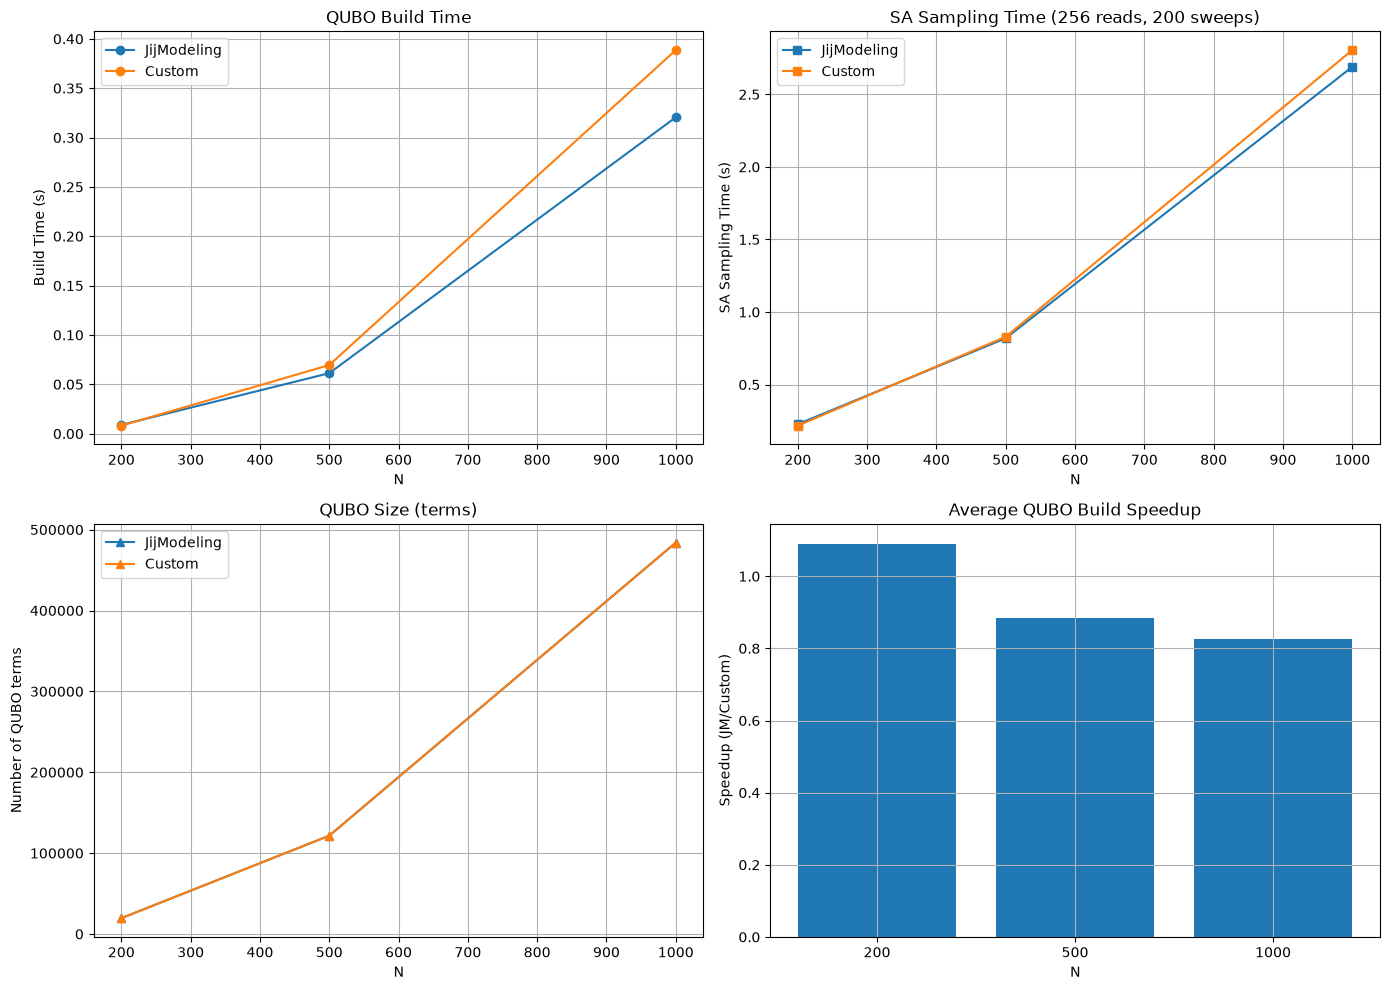


BENCHMARK SUMMARY (averages over penalty pairs)
   N     builder  build_time_median  sa_time_median    terms  N_vars
 200      Custom           0.008090        0.216977  19592.0   200.0
 200 JijModeling           0.008887        0.227195  19592.0   200.0
 500      Custom           0.069512        0.829724 121563.0   500.0
 500 JijModeling           0.061254        0.819391 121563.0   500.0
1000      Custom           0.388603        2.804914 483949.0  1000.0
1000 JijModeling           0.320550        2.689689 483949.0  1000.0

Correctness check (all random solutions matched manual energy within 1e-6):
builder
Custom         True
JijModeling    True
Name: correct, dtype: bool

Benchmark complete.


In [15]:
#@title 📊 BENCHMARK: JijModeling vs Custom QUBO Builder (Final Fix)
"""
================================================================================
BENCHMARK: JijModeling vs Custom Sparse QUBO Builder
================================================================================
- Uses exact functions from Cell 6.
- Fix: strict loading of hashed instance files (no fallback to unhashed).
- Fix: constraints extracted as a list once.
- Optimised: fewer penalty pairs, repeats, random solutions, lower SA params.
- Times QUBO construction and SA sampling for both methods.
- Verifies correctness with random solutions.
- Saves results to a DataFrame and plots.
================================================================================
"""

import sys, os, time, pickle, json, hashlib, shutil, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jijmodeling as jm
import openjij as oj
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. EXACT FUNCTIONS COPIED FROM CELL 6
# ============================================================================

def build_augmented_model() -> jm.Problem:
    problem = jm.Problem("WQM_Augmented", sense=jm.ProblemSense.MINIMIZE)
    N_ph = problem.Length("N")
    K_ph = problem.Length("K")
    a_ph = problem.Float("a", shape=(N_ph,))
    Q_ph = problem.Float("Q", shape=(N_ph, N_ph))
    neigh_ph = problem.Binary("neigh", shape=(N_ph, N_ph))
    fixed_neighbors_ph = problem.Float("fixed_neighbors", shape=(N_ph,))
    lc_ph = problem.Float("lambda_conn")
    x = problem.BinaryVar("x", shape=(N_ph,))
    obj_linear = jm.sum(N_ph, lambda i: a_ph[i] * x[i])
    obj_quad = jm.sum(
        jm.product(N_ph, N_ph).filter(lambda i, j: i < j),
        lambda i, j: Q_ph[i, j] * x[i] * x[j]
    )
    # Connectivity penalty (linear form, same as custom builder, no slack variables)
    conn_penalty = lc_ph * jm.sum(
        N_ph, lambda i: x[i] * (1 - fixed_neighbors_ph[i] - jm.sum(N_ph, lambda j: neigh_ph[i, j] * x[j]))
    )
    problem += obj_linear + obj_quad + conn_penalty
    problem += problem.Constraint("budget", jm.sum(N_ph, lambda i: x[i]) == K_ph)
    return problem

def compile_instance(problem: jm.Problem, instance_data: dict):
    placeholder_names = {p.name for p in problem.placeholders.values()}
    filtered = {k: v for k, v in instance_data.items() if k in placeholder_names}
    return problem.eval(filtered)

def adapt_sparse_to_dense(instance_data: dict) -> dict:
    N = instance_data["N"]
    Q = np.zeros((N, N), dtype=float)
    for i, j, val in instance_data.get("Q_edges", []):
        Q[i, j] = val
        Q[j, i] = val
    neigh = np.zeros((N, N), dtype=int)
    for i, nbrs in enumerate(instance_data.get("neighbors", [])):
        for j in nbrs:
            if j < N:
                neigh[i, j] = 1
    fixed_neighbors_raw = instance_data.get("fixed_neighbors", None)
    if fixed_neighbors_raw is not None:
        if isinstance(fixed_neighbors_raw, (list, np.ndarray)):
            fixed_neighbors = np.asarray(fixed_neighbors_raw, dtype=float)
        elif isinstance(fixed_neighbors_raw, dict):
            fixed_neighbors = np.zeros(N, dtype=float)
            for k, v in fixed_neighbors_raw.items():
                if int(k) < N and ((isinstance(v, (list, tuple, dict)) and len(v) > 0) or (isinstance(v, (int, float)) and v > 0)):
                    fixed_neighbors[int(k)] = 1.0
        else:
            fixed_neighbors = None
    else:
        fixed_neighbors = None
    instance_data["Q"] = Q
    instance_data["neigh"] = neigh
    instance_data["fixed_neighbors"] = fixed_neighbors
    return instance_data

# === PATH FALLBACK (hybrid: Colab + local) ===
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    # Legacy aliases (used by existing cell code)
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 2. BENCHMARK CONFIGURATION (optimised for speed)
# ============================================================================
CONFIG_BENCH = {
    "N_TESTS": [200, 500, 1000],
    "PENALTY_PAIRS": [
        (0.1, 0.1),
        (1.0, 1.0),
        (10.0, 10.0),
    ],
    "NUM_READS": 256,
    "NUM_SWEEPS": 200,
    "RANDOM_SOLUTIONS": 5,
    "REPEAT_TIMES": 3,
    "CACHE_FILE": str(CACHE_DIR / "benchmark_results.pkl")
}

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 3. ROBUST CONFIG HASH – PRIORITISE NOTEBOOK NAMESPACE
# ============================================================================
def get_config_hash():
    try:
        from IPython import get_ipython
        ns = get_ipython().user_ns
        if "config_hash" in ns:
            h = ns["config_hash"]
            if isinstance(h, str) and len(h) == 8:
                print(f"✅ Using config_hash from notebook namespace: {h}")
                return h
    except:
        pass

    hash_file = LOCAL_CACHE / "config_hash.txt"
    if hash_file.exists():
        h = hash_file.read_text().strip()
        if len(h) == 8:
            print(f"✅ Using config_hash from file: {h}")
            return h

    for cache_dir in [LOCAL_CACHE, DRIVE_CACHE]:
        for f in cache_dir.glob("instance_data_N*_*.pkl"):
            m = re.search(r"_([a-f0-9]{8})\.pkl$", f.name)
            if m:
                h = m.group(1)
                print(f"✅ Using config_hash from filename scan: {h}")
                return h

    default_config = {
        "L_c": 7500.0,
        "L_w": 1000.0,
        "Beta": 1.0,
        "Delta": 1.0,
        "Current_vector": (1.0, 0.0),
        "K": 5,
        "D_max_buffer": 1.15,
    }
    config_str = json.dumps(default_config, sort_keys=True)
    h = hashlib.md5(config_str.encode()).hexdigest()[:8]
    print(f"⚠️ Using computed default hash: {h}")
    return h

config_hash = get_config_hash()
print(f"Final config hash: {config_hash}")

# ============================================================================
# 4. STRICT INSTANCE LOADER – ONLY HASHED VERSION
# ============================================================================
def load_instance(N):
    # Try local hashed
    inst_path = CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl"
    if not inst_path.exists():
        # Try Drive hashed
        inst_path = RESULTS_DIR / f"instance_data_N{N}_{config_hash}.pkl"
        if inst_path.exists():
            print(f"📂 Copying hashed instance from Drive to local: {inst_path}")
            shutil.copy(inst_path, CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl")
            inst_path = CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl"
        else:
            raise FileNotFoundError(
                f"❌ Hashed instance file not found: instance_data_N{N}_{config_hash}.pkl\n"
                f"Please run Cell 4 to generate the hashed files."
            )

    with open(inst_path, "rb") as f:
        instance = pickle.load(f)

    print(f"🔍 Benchmark loading instance from: {inst_path}")

    # ----- Validation: ensure all indices are < N -----
    N_free = instance["N"]
    for i, j, _ in instance.get("Q_edges", []):
        if i >= N_free or j >= N_free:
            raise ValueError(f"Q_edges contains out‑of‑range index: ({i},{j}) >= {N_free}. "
                             "The file is not compressed. Please regenerate with Cell 4.")
    for nbrs in instance.get("neighbors", []):
        for nbr in nbrs:
            if nbr >= N_free:
                raise ValueError(f"neighbors contains out‑of‑range index: {nbr} >= {N_free}. "
                                 "The file is not compressed. Please regenerate with Cell 4.")

    # Convert to dense matrices (same as Cell 6)
    instance = adapt_sparse_to_dense(instance)

    # Ensure fixed_neighbors is a list of floats
    if instance.get("fixed_neighbors") is not None:
        if isinstance(instance["fixed_neighbors"], np.ndarray):
            instance["fixed_neighbors"] = instance["fixed_neighbors"].tolist()
    instance["K"] = int(instance["K"])
    if isinstance(instance["a"], np.ndarray):
        instance["a"] = instance["a"].tolist()

    return instance

# ============================================================================
# 5. CUSTOM SPARSE QUBO BUILDER (unchanged)
# ============================================================================
def build_custom_qubo_sparse(instance, lambda_budget, lambda_conn):
    N = instance["N"]
    a = np.asarray(instance["a"], dtype=float)
    Q_edges = instance.get("Q_edges", [])
    neighbors = instance.get("neighbors", [])
    fixed_neighbors = np.asarray(instance.get("fixed_neighbors", [0]*N), dtype=float)
    K = instance["K"]

    linear = {i: float(a[i]) for i in range(N)}
    quad = {}
    for i,j,val in Q_edges:
        if i < j:
            quad[(i,j)] = float(val)
        else:
            quad[(j,i)] = float(val)

    lb = float(lambda_budget)
    lc = float(lambda_conn)

    # Budget penalty: (sum x - K)^2
    for i in range(N):
        linear[i] = linear.get(i, 0.0) + lb * (1 - 2*K)
    for i in range(N):
        for j in range(i+1, N):
            quad[(i,j)] = quad.get((i,j), 0.0) + 2*lb

    # Connectivity penalty
    for i in range(N):
        linear[i] = linear.get(i, 0.0) + lc * (1 - fixed_neighbors[i])
    for i in range(N):
        for j in neighbors[i]:
            if i < j:
                quad[(i,j)] = quad.get((i,j), 0.0) - lc
            elif j < i:
                quad[(j,i)] = quad.get((j,i), 0.0) - lc

    eps = 1e-12
    linear = {k: v for k, v in linear.items() if abs(v) > eps}
    quad = {k: v for k, v in quad.items() if abs(v) > eps}
    return linear, quad, N

def custom_to_qubo_dict(linear, quad, N):
    qubo = {}
    for i, val in linear.items():
        qubo[(i,i)] = val
    for (i,j), val in quad.items():
        qubo[(i,j)] = val
    qubo = {k: v for k, v in qubo.items() if abs(v) > 1e-12}
    return qubo

# ============================================================================
# 6. MANUAL ENERGY (for correctness)
# ============================================================================
def compute_energy_manual(instance, x, lambda_budget, lambda_conn):
    a = np.asarray(instance["a"], dtype=float)
    Q_edges = instance.get("Q_edges", [])
    neighbors = instance.get("neighbors", [])
    fixed_neighbors = np.asarray(instance.get("fixed_neighbors", [0]*len(a)), dtype=float)
    K = instance["K"]
    x = np.asarray(x, dtype=float)
    energy = np.dot(a, x)
    for i,j,val in Q_edges:
        if x[i] and x[j]:
            energy += val
    s = np.sum(x)
    energy += lambda_budget * (s - K)**2
    neigh_mat = np.zeros((len(a), len(a)), dtype=int)
    for i, lst in enumerate(neighbors):
        for j in lst:
            neigh_mat[i,j] = 1
    c_i = fixed_neighbors + neigh_mat.dot(x)
    energy += lambda_conn * np.sum(x * (1.0 - c_i))
    return energy

# ============================================================================
# 7. BENCHMARK FUNCTION (FIXED & OPTIMISED)
# ============================================================================
def benchmark_instance(N, penalty_pairs, num_reads, num_sweeps, repeat=3, random_sols=5):
    instance = load_instance(N)
    model = build_augmented_model()
    model_keys = {"N", "K", "a", "Q", "neigh", "fixed_neighbors", "lambda_conn"}
    filtered_data = {k: v for k, v in instance.items() if k in model_keys}
    filtered_data["lambda_conn"] = 0.1  # default; overridden per penalty pair

    # Extract constraints ONCE as a list (from initial compile)
    init_compiled = compile_instance(model, filtered_data)
    constraints = list(init_compiled.constraints) if hasattr(init_compiled, 'constraints') else []
    print(f"Compiled instance for N={N} has {len(constraints)} constraints: {[c.name for c in constraints[:5]]}...")

    results = []
    sampler = oj.SASampler()

    for lb, lc in penalty_pairs:
        # Recompile with lambda_conn set for this penalty pair
        data = filtered_data.copy()
        data["lambda_conn"] = lc
        compiled = compile_instance(model, data)

        # Build penalty weights (only budget constraint needs a weight)
        penalty_weights = {}
        for c in constraints:
            if c.name == "budget":
                penalty_weights[c.id] = lb

        # ---- JijModeling ----
        try:
            def build_jm():
                qubo_dict, offset = compiled.to_qubo(penalty_weights=penalty_weights)
                return qubo_dict, offset

            times_jm = []
            for _ in range(repeat):
                t0 = time.perf_counter()
                qd, off = build_jm()
                times_jm.append(time.perf_counter() - t0)

            N_vars_jm = len({k[0] for k in qd.keys()})
            terms_jm = len(qd)

            def sample_jm():
                return sampler.sample_qubo(qd, num_reads=num_reads, num_sweeps=num_sweeps, sparse=True)

            times_sa_jm = []
            for _ in range(repeat):
                t0 = time.perf_counter()
                sample_jm()
                times_sa_jm.append(time.perf_counter() - t0)

            jm_success = True
            jm_offset = off
        except Exception as e:
            print(f"⚠️ JijModeling failed for N={N}, lb={lb}, lc={lc}: {e}")
            times_jm = [np.nan]*repeat
            times_sa_jm = [np.nan]*repeat
            N_vars_jm = np.nan
            terms_jm = np.nan
            qd = {}
            jm_offset = np.nan
            jm_success = False

        # ---- Custom builder ----
        def build_custom():
            linear, quad, N_custom = build_custom_qubo_sparse(instance, lb, lc)
            qubo_dict_custom = custom_to_qubo_dict(linear, quad, N_custom)
            return qubo_dict_custom, float(lb * instance["K"] ** 2)

        times_custom = []
        for _ in range(repeat):
            t0 = time.perf_counter()
            qdc, off_c = build_custom()
            times_custom.append(time.perf_counter() - t0)

        N_vars_custom = len({k[0] for k in qdc.keys()})
        terms_custom = len(qdc)

        def sample_custom():
            return sampler.sample_qubo(qdc, num_reads=num_reads, num_sweeps=num_sweeps, sparse=True)

        times_sa_custom = []
        for _ in range(repeat):
            t0 = time.perf_counter()
            sample_custom()
            times_sa_custom.append(time.perf_counter() - t0)

        # ---- Correctness ----
        correct = True
        max_diff = 0.0
        if jm_success:
            for _ in range(random_sols):
                x = np.random.randint(0, 2, size=instance["N"])
                e_manual = compute_energy_manual(instance, x, lb, lc)
                e_jm = 0.0
                for (i,j), val in qd.items():
                    if i == j:
                        e_jm += val * x[i]
                    else:
                        if x[i] and x[j]:
                            e_jm += val
                e_jm += jm_offset
                e_custom = 0.0
                for (i,j), val in qdc.items():
                    if i == j:
                        e_custom += val * x[i]
                    else:
                        if x[i] and x[j]:
                            e_custom += val
                e_custom += off_c
                diff_jm = abs(e_manual - e_jm)
                diff_custom = abs(e_manual - e_custom)
                if diff_jm > 1e-6 or diff_custom > 1e-6:
                    correct = False
                    max_diff = max(max_diff, diff_jm, diff_custom)
        else:
            # Only custom can be checked
            for _ in range(random_sols):
                x = np.random.randint(0, 2, size=instance["N"])
                e_manual = compute_energy_manual(instance, x, lb, lc)
                e_custom = 0.0
                for (i,j), val in qdc.items():
                    if i == j:
                        e_custom += val * x[i]
                    else:
                        if x[i] and x[j]:
                            e_custom += val
                e_custom += off_c
                diff_custom = abs(e_manual - e_custom)
                if diff_custom > 1e-6:
                    correct = False
                    max_diff = max(max_diff, diff_custom)

        # Store results
        results.append({
            "N": N,
            "lambda_budget": lb,
            "lambda_conn": lc,
            "builder": "JijModeling",
            "build_time_median": np.nanmedian(times_jm),
            "build_time_std": np.nanstd(times_jm),
            "sa_time_median": np.nanmedian(times_sa_jm),
            "sa_time_std": np.nanstd(times_sa_jm),
            "N_vars": N_vars_jm,
            "terms": terms_jm,
            "offset": jm_offset,
            "correct": correct,
            "max_diff": max_diff,
            "success": jm_success
        })
        results.append({
            "N": N,
            "lambda_budget": lb,
            "lambda_conn": lc,
            "builder": "Custom",
            "build_time_median": np.median(times_custom),
            "build_time_std": np.std(times_custom),
            "sa_time_median": np.median(times_sa_custom),
            "sa_time_std": np.std(times_sa_custom),
            "N_vars": N_vars_custom,
            "terms": terms_custom,
            "offset": off_c,
            "correct": correct,
            "max_diff": max_diff,
            "success": True
        })

        # Print summary
        if jm_success:
            speedup = np.median(times_jm) / np.median(times_custom) if np.median(times_custom) > 0 else np.inf
            print(f"N={N}, λb={lb:.2f}, λc={lc:.2f}: "
                  f"JM build {np.median(times_jm):.4f}s, custom build {np.median(times_custom):.4f}s (speedup {speedup:.1f}x) "
                  f"JM SA {np.median(times_sa_jm):.4f}s, custom SA {np.median(times_sa_custom):.4f}s "
                  f"JM terms={terms_jm}, custom terms={terms_custom}. Correctness: {'OK' if correct else f'FAIL (max diff {max_diff:.2e})'}")
        else:
            print(f"N={N}, λb={lb:.2f}, λc={lc:.2f}: "
                  f"JM FAILED, custom build {np.median(times_custom):.4f}s "
                  f"custom SA {np.median(times_sa_custom):.4f}s, custom terms={terms_custom}. Correctness: {'OK' if correct else f'FAIL (max diff {max_diff:.2e})'}")
    return results

# ============================================================================
# 8. MAIN RUN
# ============================================================================
def run_benchmark():
    cache_file = Path(CONFIG_BENCH["CACHE_FILE"])
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            df = pickle.load(f)
        print("Loaded cached benchmark results.")
        return df

    all_results = []
    for N in CONFIG_BENCH["N_TESTS"]:
        print(f"\n{'='*60}\nBenchmarking N={N}\n{'='*60}")
        try:
            res = benchmark_instance(
                N,
                CONFIG_BENCH["PENALTY_PAIRS"],
                num_reads=CONFIG_BENCH["NUM_READS"],
                num_sweeps=CONFIG_BENCH["NUM_SWEEPS"],
                repeat=CONFIG_BENCH["REPEAT_TIMES"],
                random_sols=CONFIG_BENCH["RANDOM_SOLUTIONS"]
            )
            all_results.extend(res)
        except Exception as e:
            print(f"❌ Failed for N={N}: {e}")
            import traceback
            traceback.print_exc()
            continue

    df = pd.DataFrame(all_results)
    with open(cache_file, "wb") as f:
        pickle.dump(df, f)
    print(f"\n✅ Cached benchmark results to {cache_file}")
    return df

# ---- Run ----
df = run_benchmark()

if df.empty:
    print("No results to plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0,0]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        if builder == "JijModeling":
            sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["build_time_median"].mean()
        ax.plot(grouped.index, grouped.values, marker='o', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("Build Time (s)")
    ax.set_title("QUBO Build Time")
    ax.legend()
    ax.grid(True)

    ax = axes[0,1]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        if builder == "JijModeling":
            sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["sa_time_median"].mean()
        ax.plot(grouped.index, grouped.values, marker='s', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("SA Sampling Time (s)")
    ax.set_title("SA Sampling Time ({} reads, {} sweeps)".format(CONFIG_BENCH["NUM_READS"], CONFIG_BENCH["NUM_SWEEPS"]))
    ax.legend()
    ax.grid(True)

    ax = axes[1,0]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        if builder == "JijModeling":
            sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["terms"].mean()
        ax.plot(grouped.index, grouped.values, marker='^', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("Number of QUBO terms")
    ax.set_title("QUBO Size (terms)")
    ax.legend()
    ax.grid(True)

    ax = axes[1,1]
    pivot = df.pivot_table(index=["N", "lambda_budget", "lambda_conn"], columns="builder", values="build_time_median").reset_index()
    pivot = pivot.dropna(subset=["JijModeling", "Custom"])
    pivot["speedup"] = pivot["JijModeling"] / pivot["Custom"]
    grouped_speedup = pivot.groupby("N")["speedup"].mean()
    ax.bar(grouped_speedup.index.astype(str), grouped_speedup.values)
    ax.set_xlabel("N")
    ax.set_ylabel("Speedup (JM/Custom)")
    ax.set_title("Average QUBO Build Speedup")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("BENCHMARK SUMMARY (averages over penalty pairs)")
    print("="*80)
    summary = df[df["success"] == True].groupby(["N", "builder"]).agg({
        "build_time_median": "mean",
        "sa_time_median": "mean",
        "terms": "mean",
        "N_vars": "mean"
    }).reset_index()
    print(summary.to_string(index=False))

    correctness = df.groupby("builder")["correct"].all()
    print("\nCorrectness check (all random solutions matched manual energy within 1e-6):")
    print(correctness)

print("\nBenchmark complete.")

In [27]:
#@title 📊 BENCHMARK: JM (Inequality) vs Custom (Slack Variables)
import time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jijmodeling as jm
import openjij as oj
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. MODELS
# ============================================================================

def build_jm_model_original() -> jm.Problem:
    """Original formulation from SA Tune script using inequalities[cite: 1]"""
    problem = jm.Problem("WQM_Original", sense=jm.ProblemSense.MINIMIZE)
    N_ph = problem.Length("N")
    K_ph = problem.Length("K")
    a_ph = problem.Float("a", shape=(N_ph,))
    Q_ph = problem.Float("Q", shape=(N_ph, N_ph))
    neigh_ph = problem.Binary("neigh", shape=(N_ph, N_ph))
    fixed_neighbors_ph = problem.Float("fixed_neighbors", shape=(N_ph,))
    x = problem.BinaryVar("x", shape=(N_ph,))
    
    obj_linear = jm.sum(N_ph, lambda i: a_ph[i] * x[i])
    obj_quad = jm.sum(
        jm.product(N_ph, N_ph).filter(lambda i, j: i < j),
        lambda i, j: Q_ph[i, j] * x[i] * x[j]
    )
    problem += obj_linear + obj_quad
    
    problem += problem.Constraint("budget", jm.sum(N_ph, lambda i: x[i]) == K_ph)
    # The strict inequality that forces JM to generate slacks[cite: 1]
    problem += problem.Constraint(
        "connectivity",
        lambda i: x[i] <= fixed_neighbors_ph[i] + jm.sum(N_ph, lambda j: neigh_ph[i, j] * x[j]),
        domain=N_ph
    )
    return problem

def build_custom_qubo_with_slacks(instance, lambda_budget, lambda_conn):
    """Custom builder manually constructing slack variables"""
    N = instance["N"]
    K = instance["K"]
    a = np.asarray(instance["a"], dtype=float)
    Q_edges = instance.get("Q_edges", [])
    neighbors = instance.get("neighbors", [])
    fixed_neighbors = np.asarray(instance.get("fixed_neighbors", [0]*N), dtype=float)

    linear = {i: float(a[i]) for i in range(N)}
    quad = {}
    for i, j, val in Q_edges:
        if i < j: quad[(i,j)] = float(val)
        else: quad[(j,i)] = float(val)

    lb = float(lambda_budget)
    lc = float(lambda_conn)

    # 1. Budget Penalty: lb * (sum x - K)^2
    for i in range(N):
        linear[i] = linear.get(i, 0.0) + lb * (1 - 2*K)
    for i in range(N):
        for j in range(i+1, N):
            quad[(i,j)] = quad.get((i,j), 0.0) + 2*lb

    # 2. Connectivity Penalty with manual slack variables
    slack_idx = N 
    offset = lb * (K**2)

    for i in range(N):
        c_i = fixed_neighbors[i]
        N_i = neighbors[i]
        
        # Calculate maximum possible value of the RHS to bound the slack
        max_connections = len(N_i) + c_i
        
        # If node has no possible connections, slack won't help. 
        if max_connections <= 0:
            # Penalty is just lc * x_i^2 = lc * x_i
            linear[i] = linear.get(i, 0.0) + lc
            continue
            
        # Determine number of binary slack variables needed
        num_slacks = int(np.floor(np.log2(max_connections))) + 1
        slack_coeffs = [2**k for k in range(num_slacks)]
        
        # Build the linear expression: (sum_j x_j) - x_i - (sum_k w_k s_k) + c_i = 0
        lin_expr = {}
        for j in N_i: lin_expr[j] = 1.0
        lin_expr[i] = lin_expr.get(i, 0.0) - 1.0
        
        for k, w in enumerate(slack_coeffs):
            s_idx = slack_idx + k
            lin_expr[s_idx] = -float(w)
        slack_idx += len(slack_coeffs)
        
        # Expand the square of the linear expression: lc * (Expr + c_i)^2
        offset += lc * (c_i ** 2)
        
        for var1, coeff1 in lin_expr.items():
            # Linear terms from squaring and multiplying by 2*c_i
            val = lc * ((coeff1 ** 2) + 2 * c_i * coeff1)
            linear[var1] = linear.get(var1, 0.0) + val
            
            # Quadratic cross-terms
            for var2, coeff2 in lin_expr.items():
                if var1 < var2:
                    val2 = lc * 2 * coeff1 * coeff2
                    quad[(var1, var2)] = quad.get((var1, var2), 0.0) + val2

    # Clean up near-zero terms
    linear = {k: v for k, v in linear.items() if abs(v) > 1e-12}
    quad = {k: v for k, v in quad.items() if abs(v) > 1e-12}
    
    return linear, quad, slack_idx, offset

def custom_to_qubo_dict(linear, quad):
    qubo = {}
    for i, val in linear.items(): qubo[(i,i)] = val
    for (i,j), val in quad.items(): qubo[(i,j)] = val
    return qubo

# ============================================================================
# 2. MOCK DATA & RUNNER
# ============================================================================
def generate_mock_instance(N, K):
    np.random.seed(42)
    a = np.random.uniform(-1, 1, size=N).tolist()
    Q_edges = []
    neighbors = []
    for i in range(N):
        num_edges = np.random.randint(1, min(5, N))
        nbrs = np.random.choice([x for x in range(N) if x != i], size=num_edges, replace=False).tolist()
        neighbors.append(nbrs)
        for j in nbrs:
            if i < j:
                Q_edges.append((i, j, np.random.uniform(-0.5, 0.5)))
                
    return {
        "N": N, "K": K, "a": a, "Q_edges": Q_edges, 
        "neighbors": neighbors, "fixed_neighbors": [0.0]*N
    }

# Ensure dense matrix format required by compiling instances[cite: 2]
def adapt_to_dense(inst):
    N = inst["N"]
    Q = np.zeros((N, N))
    neigh = np.zeros((N, N), dtype=int)
    for i, j, val in inst["Q_edges"]: Q[i, j] = Q[j, i] = val
    for i, nbrs in enumerate(inst["neighbors"]):
        for j in nbrs: neigh[i, j] = 1
    inst["Q"] = Q
    inst["neigh"] = neigh
    return inst

print("Starting Slack Variable Benchmark...")
N_TESTS = [20, 500, 1000] # Kept small because slacks will explode the matrix
results = []
sampler = oj.SASampler()

jm_model = build_jm_model_original()

for N in N_TESTS:
    print(f"\nBenchmarking N={N}...")
    inst = generate_mock_instance(N, K=int(N*0.1))
    dense_inst = adapt_to_dense(inst.copy())
    
    # -- JIJMODELING --
    t0 = time.perf_counter()
    compiled = jm_model.eval({k: v for k, v in dense_inst.items() if k in {"N", "K", "a", "Q", "neigh", "fixed_neighbors"}})
    penalty_weights = {c.id: 1.0 for c in compiled.constraints} 
    qd_jm, _ = compiled.to_qubo(penalty_weights=penalty_weights)
    jm_time = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    sampler.sample_qubo(qd_jm, num_reads=1024, num_sweeps=1000)
    jm_sa_time = time.perf_counter() - t0
    jm_vars = len({k[0] for k in qd_jm.keys()})

    # -- CUSTOM SLACKS --
    t0 = time.perf_counter()
    lin, quad, total_vars, _ = build_custom_qubo_with_slacks(inst, 1.0, 1.0)
    qd_custom = custom_to_qubo_dict(lin, quad)
    custom_time = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    sampler.sample_qubo(qd_custom, num_reads=1024, num_sweeps=1000)
    custom_sa_time = time.perf_counter() - t0

    results.append({
        "N": N,
        "JM_Build_s": jm_time, "Custom_Build_s": custom_time,
        "JM_SA_s": jm_sa_time, "Custom_SA_s": custom_sa_time,
        "JM_Vars": jm_vars, "Custom_Vars": total_vars
    })
    
    print(f"JM: Build {jm_time:.3f}s | Vars: {jm_vars}")
    print(f"Custom: Build {custom_time:.3f}s | Vars: {total_vars}")

df = pd.DataFrame(results)
print("\n--- SUMMARY ---")
print(df.to_string(index=False))

Starting Slack Variable Benchmark...

Benchmarking N=20...
JM: Build 0.397s | Vars: 58
Custom: Build 0.037s | Vars: 58

Benchmarking N=500...
JM: Build 19.495s | Vars: 1489
Custom: Build 0.044s | Vars: 1489

Benchmarking N=1000...
JM: Build 151.279s | Vars: 3011
Custom: Build 0.220s | Vars: 3011

--- SUMMARY ---
   N  JM_Build_s  Custom_Build_s   JM_SA_s  Custom_SA_s  JM_Vars  Custom_Vars
  20    0.396984        0.037200  0.662159     0.688336       58           58
 500   19.495290        0.044378 13.598378    14.423774     1489         1489
1000  151.279065        0.219967 39.294086    37.074382     3011         3011


✅ Using config_hash from notebook namespace: 241358d8
Final config hash: 241358d8

Benchmarking N=200
🔍 Benchmark loading instance from: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-quality-qubo/data/cache/instance_data_N200_241358d8.pkl
Compiled instance for N=200 has 201 constraints.
N=200, λb=0.10, λc=0.10: JM build 0.0102s, custom build 0.0460s (speedup 0.2x) JM SA 0.2466s, custom SA 1.2025s JM vars=215, custom vars=1146.
N=200, λb=1.00, λc=1.00: JM build 0.0095s, custom build 0.0439s (speedup 0.2x) JM SA 0.2019s, custom SA 0.9798s JM vars=215, custom vars=1146.
N=200, λb=10.00, λc=10.00: JM build 0.0086s, custom build 0.0449s (speedup 0.2x) JM SA 0.2440s, custom SA 1.0833s JM vars=215, custom vars=1146.

Benchmarking N=500
🔍 Benchmark loading instance from: /home/csiy/Documents/school/taiwan 4th yr intersession/Water Quality Monitoring Buoys/code/water-quality-qubo/data/cache/instance_data_N500_241358d8.pkl
Compiled instance for 

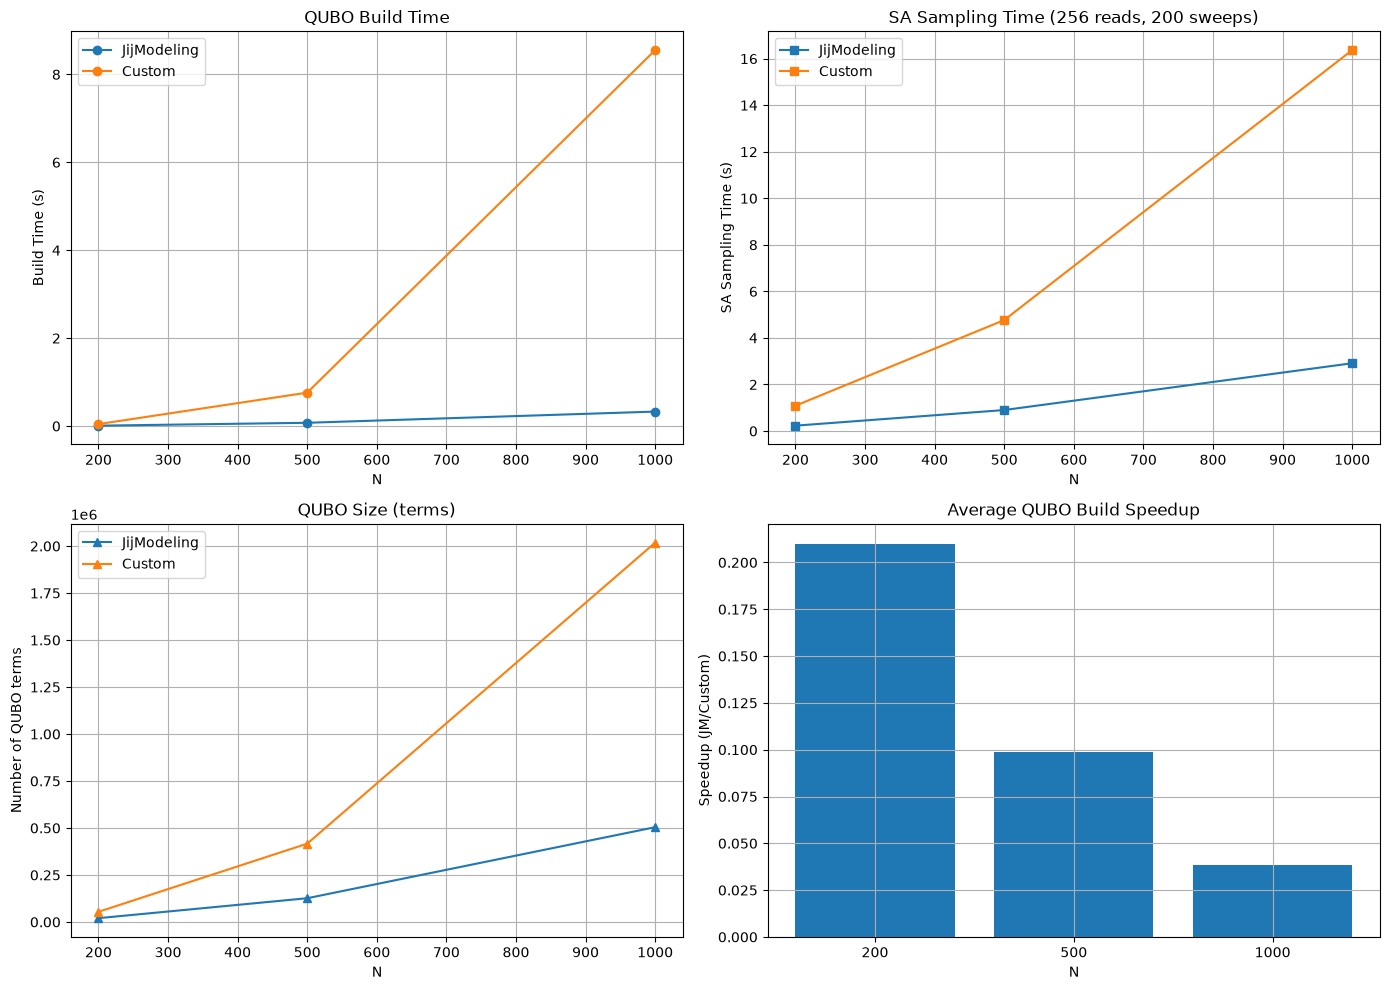


BENCHMARK SUMMARY (averages over penalty pairs)
   N     builder  build_time_median  sa_time_median     terms  N_vars
 200      Custom           0.044924        1.088518   54140.0  1146.0
 200 JijModeling           0.009442        0.230837   20328.0   215.0
 500      Custom           0.760688        4.768055  416787.0  3634.0
 500 JijModeling           0.074911        0.902223  126400.0   535.0
1000      Custom           8.552865       16.367908 2018485.0  8608.0
1000 JijModeling           0.329648        2.913540  504430.0  1065.0

Benchmark complete.


In [28]:
#@title 📊 BENCHMARK: JM (Inequality) vs Custom (Slack Variables)
"""
================================================================================
BENCHMARK: JijModeling (Inequality) vs Custom Slack-Variable QUBO Builder
================================================================================
- JM model: original inequality constraint (see build_jm_model_original)
- Custom builder: manually introduces binary slack variables per inequality
- Measures QUBO construction time and SA sampling time for both methods
- Compares QUBO size (variables and terms) and build speedup
- Uses hashed instances from Cell 4 (robust config hash)
================================================================================
"""

import sys, os, time, pickle, json, hashlib, shutil, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jijmodeling as jm
import openjij as oj
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. MODELS
# ============================================================================

def build_jm_model_original() -> jm.Problem:
    """Original formulation from SA Tune script using inequalities."""
    problem = jm.Problem("WQM_Original", sense=jm.ProblemSense.MINIMIZE)
    N_ph = problem.Length("N")
    K_ph = problem.Length("K")
    a_ph = problem.Float("a", shape=(N_ph,))
    Q_ph = problem.Float("Q", shape=(N_ph, N_ph))
    neigh_ph = problem.Binary("neigh", shape=(N_ph, N_ph))
    fixed_neighbors_ph = problem.Float("fixed_neighbors", shape=(N_ph,))
    x = problem.BinaryVar("x", shape=(N_ph,))
    
    obj_linear = jm.sum(N_ph, lambda i: a_ph[i] * x[i])
    obj_quad = jm.sum(
        jm.product(N_ph, N_ph).filter(lambda i, j: i < j),
        lambda i, j: Q_ph[i, j] * x[i] * x[j]
    )
    problem += obj_linear + obj_quad
    
    problem += problem.Constraint("budget", jm.sum(N_ph, lambda i: x[i]) == K_ph)
    # Inequality constraint – JM will introduce slack variables automatically
    problem += problem.Constraint(
        "connectivity",
        lambda i: x[i] <= fixed_neighbors_ph[i] + jm.sum(N_ph, lambda j: neigh_ph[i, j] * x[j]),
        domain=N_ph
    )
    return problem

def build_custom_qubo_with_slacks(instance, lambda_budget, lambda_conn):
    """
    Custom builder that manually introduces binary slack variables for each
    inequality constraint.  Returns (linear, quad, total_vars, offset).
    """
    N = instance["N"]
    K = instance["K"]
    a = np.asarray(instance["a"], dtype=float)
    Q_edges = instance.get("Q_edges", [])
    neighbors = instance.get("neighbors", [])
    fixed_neighbors = np.asarray(instance.get("fixed_neighbors", [0]*N), dtype=float)

    linear = {i: float(a[i]) for i in range(N)}
    quad = {}
    for i, j, val in Q_edges:
        if i < j: quad[(i,j)] = float(val)
        else: quad[(j,i)] = float(val)

    lb = float(lambda_budget)
    lc = float(lambda_conn)

    # 1. Budget Penalty: lb * (sum x - K)^2
    for i in range(N):
        linear[i] = linear.get(i, 0.0) + lb * (1 - 2*K)
    for i in range(N):
        for j in range(i+1, N):
            quad[(i,j)] = quad.get((i,j), 0.0) + 2*lb

    # 2. Connectivity Penalty with manual slack variables
    slack_idx = N 
    offset = lb * (K**2)

    for i in range(N):
        c_i = fixed_neighbors[i]
        N_i = neighbors[i]
        max_connections = len(N_i) + c_i
        if max_connections <= 0:
            linear[i] = linear.get(i, 0.0) + lc
            continue
            
        num_slacks = int(np.floor(np.log2(max_connections))) + 1
        slack_coeffs = [2**k for k in range(num_slacks)]
        
        lin_expr = {}
        for j in N_i: lin_expr[j] = 1.0
        lin_expr[i] = lin_expr.get(i, 0.0) - 1.0
        for k, w in enumerate(slack_coeffs):
            s_idx = slack_idx + k
            lin_expr[s_idx] = -float(w)
        slack_idx += len(slack_coeffs)
        
        offset += lc * (c_i ** 2)
        for var1, coeff1 in lin_expr.items():
            val = lc * ((coeff1 ** 2) + 2 * c_i * coeff1)
            linear[var1] = linear.get(var1, 0.0) + val
            for var2, coeff2 in lin_expr.items():
                if var1 < var2:
                    val2 = lc * 2 * coeff1 * coeff2
                    quad[(var1, var2)] = quad.get((var1, var2), 0.0) + val2

    eps = 1e-12
    linear = {k: v for k, v in linear.items() if abs(v) > eps}
    quad = {k: v for k, v in quad.items() if abs(v) > eps}
    return linear, quad, slack_idx, offset

def custom_to_qubo_dict(linear, quad):
    qubo = {}
    for i, val in linear.items():
        qubo[(i,i)] = val
    for (i,j), val in quad.items():
        qubo[(i,j)] = val
    return {k: v for k, v in qubo.items() if abs(v) > 1e-12}

# ============================================================================
# 2. INSTANCE LOADER (unchanged, uses hashed files)
# ============================================================================

# (Keep all the path and loading code exactly as in the original benchmark)
try:
    CACHE_DIR
except NameError:
    import importlib.util
    try:
        IN_COLAB = importlib.util.find_spec("google.colab") is not None
    except Exception:
        IN_COLAB = False
    if IN_COLAB:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        CACHE_DIR = Path("/content/wqm_data")
        RESULTS_DIR = Path("/content/drive/MyDrive/wqm_data")
        DATA_DIR = RESULTS_DIR
    else:
        REPO_PATH = Path.cwd().resolve()
        for _ in range(6):
            if (REPO_PATH / "notebooks").exists() or (REPO_PATH / "src").exists() or (REPO_PATH / ".git").exists():
                break
            REPO_PATH = REPO_PATH.parent
        DATA_DIR = REPO_PATH / "data"
        CACHE_DIR = DATA_DIR / "cache"
        RESULTS_DIR = REPO_PATH / "results"
    LOCAL_CACHE = CACHE_DIR
    GDRIVE_BASE = RESULTS_DIR
    OUTPUT_DIR = RESULTS_DIR
    DRIVE_CACHE = RESULTS_DIR
    GEOJSON_PATH = DATA_DIR / "LDB_centroids_clean.geojson"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def get_config_hash():
    try:
        from IPython import get_ipython
        ns = get_ipython().user_ns
        if "config_hash" in ns:
            h = ns["config_hash"]
            if isinstance(h, str) and len(h) == 8:
                print(f"✅ Using config_hash from notebook namespace: {h}")
                return h
    except:
        pass
    hash_file = LOCAL_CACHE / "config_hash.txt"
    if hash_file.exists():
        h = hash_file.read_text().strip()
        if len(h) == 8:
            print(f"✅ Using config_hash from file: {h}")
            return h
    for cache_dir in [LOCAL_CACHE, DRIVE_CACHE]:
        for f in cache_dir.glob("instance_data_N*_*.pkl"):
            m = re.search(r"_([a-f0-9]{8})\.pkl$", f.name)
            if m:
                h = m.group(1)
                print(f"✅ Using config_hash from filename scan: {h}")
                return h
    default_config = {
        "L_c": 7500.0, "L_w": 1000.0, "Beta": 1.0, "Delta": 1.0,
        "Current_vector": (1.0, 0.0), "K": 5, "D_max_buffer": 1.15,
    }
    config_str = json.dumps(default_config, sort_keys=True)
    h = hashlib.md5(config_str.encode()).hexdigest()[:8]
    print(f"⚠️ Using computed default hash: {h}")
    return h

config_hash = get_config_hash()
print(f"Final config hash: {config_hash}")

def adapt_sparse_to_dense(instance_data: dict) -> dict:
    N = instance_data["N"]
    Q = np.zeros((N, N), dtype=float)
    for i, j, val in instance_data.get("Q_edges", []):
        Q[i, j] = val
        Q[j, i] = val
    neigh = np.zeros((N, N), dtype=int)
    for i, nbrs in enumerate(instance_data.get("neighbors", [])):
        for j in nbrs:
            if j < N:
                neigh[i, j] = 1
    fixed_neighbors_raw = instance_data.get("fixed_neighbors", None)
    if fixed_neighbors_raw is not None:
        if isinstance(fixed_neighbors_raw, (list, np.ndarray)):
            fixed_neighbors = np.asarray(fixed_neighbors_raw, dtype=float)
        elif isinstance(fixed_neighbors_raw, dict):
            fixed_neighbors = np.zeros(N, dtype=float)
            for k, v in fixed_neighbors_raw.items():
                if int(k) < N and ((isinstance(v, (list, tuple, dict)) and len(v) > 0) or (isinstance(v, (int, float)) and v > 0)):
                    fixed_neighbors[int(k)] = 1.0
        else:
            fixed_neighbors = None
    else:
        fixed_neighbors = None
    instance_data["Q"] = Q
    instance_data["neigh"] = neigh
    instance_data["fixed_neighbors"] = fixed_neighbors
    return instance_data

def load_instance(N):
    inst_path = CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl"
    if not inst_path.exists():
        inst_path = RESULTS_DIR / f"instance_data_N{N}_{config_hash}.pkl"
        if inst_path.exists():
            print(f"📂 Copying hashed instance from Drive to local: {inst_path}")
            shutil.copy(inst_path, CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl")
            inst_path = CACHE_DIR / f"instance_data_N{N}_{config_hash}.pkl"
        else:
            raise FileNotFoundError(
                f"❌ Hashed instance file not found: instance_data_N{N}_{config_hash}.pkl\n"
                f"Please run Cell 4 to generate the hashed files."
            )
    with open(inst_path, "rb") as f:
        instance = pickle.load(f)
    print(f"🔍 Benchmark loading instance from: {inst_path}")
    # Validate indices
    N_free = instance["N"]
    for i, j, _ in instance.get("Q_edges", []):
        if i >= N_free or j >= N_free:
            raise ValueError(f"Q_edges contains out‑of‑range index: ({i},{j}) >= {N_free}.")
    for nbrs in instance.get("neighbors", []):
        for nbr in nbrs:
            if nbr >= N_free:
                raise ValueError(f"neighbors contains out‑of‑range index: {nbr} >= {N_free}.")
    instance = adapt_sparse_to_dense(instance)
    if instance.get("fixed_neighbors") is not None:
        if isinstance(instance["fixed_neighbors"], np.ndarray):
            instance["fixed_neighbors"] = instance["fixed_neighbors"].tolist()
    instance["K"] = int(instance["K"])
    if isinstance(instance["a"], np.ndarray):
        instance["a"] = instance["a"].tolist()
    return instance

# ============================================================================
# 3. BENCHMARK CONFIGURATION
# ============================================================================
CONFIG_BENCH = {
    "N_TESTS": [200, 500, 1000],
    "PENALTY_PAIRS": [
        (0.1, 0.1),
        (1.0, 1.0),
        (10.0, 10.0),
    ],
    "NUM_READS": 256,
    "NUM_SWEEPS": 200,
    "REPEAT_TIMES": 3,
    "CACHE_FILE": str(CACHE_DIR / "benchmark_results_slack.pkl")
}

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 4. BENCHMARK FUNCTION
# ============================================================================
def benchmark_instance(N, penalty_pairs, num_reads, num_sweeps, repeat=3):
    instance = load_instance(N)
    model = build_jm_model_original()
    model_keys = {"N", "K", "a", "Q", "neigh", "fixed_neighbors"}
    filtered_data = {k: v for k, v in instance.items() if k in model_keys}

    # Compile once to get constraint objects
    init_compiled = model.eval(filtered_data)
    constraints = list(init_compiled.constraints) if hasattr(init_compiled, 'constraints') else []
    print(f"Compiled instance for N={N} has {len(constraints)} constraints.")

    results = []
    sampler = oj.SASampler()

    for lb, lc in penalty_pairs:
        # --- JijModeling ---
        compiled = model.eval(filtered_data)  # re-evaluate (no lambda_conn needed)
        penalty_weights = {}
        for c in constraints:
            if c.name == "budget":
                penalty_weights[c.id] = lb
            elif c.name == "connectivity":
                penalty_weights[c.id] = lc
        try:
            def build_jm():
                qubo_dict, offset = compiled.to_qubo(penalty_weights=penalty_weights)
                return qubo_dict, offset

            times_jm = []
            for _ in range(repeat):
                t0 = time.perf_counter()
                qd, off = build_jm()
                times_jm.append(time.perf_counter() - t0)

            N_vars_jm = len({k[0] for k in qd.keys()})
            terms_jm = len(qd)

            def sample_jm():
                return sampler.sample_qubo(qd, num_reads=num_reads, num_sweeps=num_sweeps, sparse=True)

            times_sa_jm = []
            for _ in range(repeat):
                t0 = time.perf_counter()
                sample_jm()
                times_sa_jm.append(time.perf_counter() - t0)

            jm_success = True
            jm_offset = off
        except Exception as e:
            print(f"⚠️ JijModeling failed for N={N}, lb={lb}, lc={lc}: {e}")
            times_jm = [np.nan]*repeat
            times_sa_jm = [np.nan]*repeat
            N_vars_jm = np.nan
            terms_jm = np.nan
            qd = {}
            jm_offset = np.nan
            jm_success = False

        # --- Custom Slack Builder ---
        def build_custom():
            linear, quad, total_vars, offset = build_custom_qubo_with_slacks(instance, lb, lc)
            qubo_dict = custom_to_qubo_dict(linear, quad)
            return qubo_dict, offset, total_vars

        times_custom = []
        for _ in range(repeat):
            t0 = time.perf_counter()
            qdc, off_c, total_vars_c = build_custom()
            times_custom.append(time.perf_counter() - t0)

        # Use the last built one for measurements
        N_vars_custom = total_vars_c
        terms_custom = len(qdc)

        def sample_custom():
            return sampler.sample_qubo(qdc, num_reads=num_reads, num_sweeps=num_sweeps, sparse=True)

        times_sa_custom = []
        for _ in range(repeat):
            t0 = time.perf_counter()
            sample_custom()
            times_sa_custom.append(time.perf_counter() - t0)

        # --- Store results ---
        results.append({
            "N": N,
            "lambda_budget": lb,
            "lambda_conn": lc,
            "builder": "JijModeling",
            "build_time_median": np.nanmedian(times_jm),
            "build_time_std": np.nanstd(times_jm),
            "sa_time_median": np.nanmedian(times_sa_jm),
            "sa_time_std": np.nanstd(times_sa_jm),
            "N_vars": N_vars_jm,
            "terms": terms_jm,
            "offset": jm_offset,
            "success": jm_success
        })
        results.append({
            "N": N,
            "lambda_budget": lb,
            "lambda_conn": lc,
            "builder": "Custom",
            "build_time_median": np.median(times_custom),
            "build_time_std": np.std(times_custom),
            "sa_time_median": np.median(times_sa_custom),
            "sa_time_std": np.std(times_sa_custom),
            "N_vars": N_vars_custom,
            "terms": terms_custom,
            "offset": off_c,
            "success": True
        })

        # --- Print summary ---
        if jm_success:
            speedup = np.median(times_jm) / np.median(times_custom) if np.median(times_custom) > 0 else np.inf
            print(f"N={N}, λb={lb:.2f}, λc={lc:.2f}: "
                  f"JM build {np.median(times_jm):.4f}s, custom build {np.median(times_custom):.4f}s (speedup {speedup:.1f}x) "
                  f"JM SA {np.median(times_sa_jm):.4f}s, custom SA {np.median(times_sa_custom):.4f}s "
                  f"JM vars={N_vars_jm}, custom vars={N_vars_custom}.")
        else:
            print(f"N={N}, λb={lb:.2f}, λc={lc:.2f}: "
                  f"JM FAILED, custom build {np.median(times_custom):.4f}s "
                  f"custom SA {np.median(times_sa_custom):.4f}s, custom vars={N_vars_custom}.")
    return results

# ============================================================================
# 5. MAIN RUN & PLOTTING
# ============================================================================
def run_benchmark():
    cache_file = Path(CONFIG_BENCH["CACHE_FILE"])
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            df = pickle.load(f)
        print("Loaded cached benchmark results.")
        return df

    all_results = []
    for N in CONFIG_BENCH["N_TESTS"]:
        print(f"\n{'='*60}\nBenchmarking N={N}\n{'='*60}")
        try:
            res = benchmark_instance(
                N,
                CONFIG_BENCH["PENALTY_PAIRS"],
                num_reads=CONFIG_BENCH["NUM_READS"],
                num_sweeps=CONFIG_BENCH["NUM_SWEEPS"],
                repeat=CONFIG_BENCH["REPEAT_TIMES"]
            )
            all_results.extend(res)
        except Exception as e:
            print(f"❌ Failed for N={N}: {e}")
            import traceback
            traceback.print_exc()
            continue

    df = pd.DataFrame(all_results)
    with open(cache_file, "wb") as f:
        pickle.dump(df, f)
    print(f"\n✅ Cached benchmark results to {cache_file}")
    return df

df = run_benchmark()

if df.empty:
    print("No results to plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0,0]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["build_time_median"].mean()
        ax.plot(grouped.index, grouped.values, marker='o', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("Build Time (s)")
    ax.set_title("QUBO Build Time")
    ax.legend()
    ax.grid(True)

    ax = axes[0,1]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["sa_time_median"].mean()
        ax.plot(grouped.index, grouped.values, marker='s', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("SA Sampling Time (s)")
    ax.set_title("SA Sampling Time ({} reads, {} sweeps)".format(CONFIG_BENCH["NUM_READS"], CONFIG_BENCH["NUM_SWEEPS"]))
    ax.legend()
    ax.grid(True)

    ax = axes[1,0]
    for builder in df["builder"].unique():
        sub = df[df["builder"] == builder]
        sub = sub[sub["success"] == True]
        grouped = sub.groupby("N")["terms"].mean()
        ax.plot(grouped.index, grouped.values, marker='^', label=builder)
    ax.set_xlabel("N")
    ax.set_ylabel("Number of QUBO terms")
    ax.set_title("QUBO Size (terms)")
    ax.legend()
    ax.grid(True)

    ax = axes[1,1]
    pivot = df.pivot_table(index=["N", "lambda_budget", "lambda_conn"], columns="builder", values="build_time_median").reset_index()
    pivot = pivot.dropna(subset=["JijModeling", "Custom"])
    pivot["speedup"] = pivot["JijModeling"] / pivot["Custom"]
    grouped_speedup = pivot.groupby("N")["speedup"].mean()
    ax.bar(grouped_speedup.index.astype(str), grouped_speedup.values)
    ax.set_xlabel("N")
    ax.set_ylabel("Speedup (JM/Custom)")
    ax.set_title("Average QUBO Build Speedup")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("BENCHMARK SUMMARY (averages over penalty pairs)")
    print("="*80)
    summary = df[df["success"] == True].groupby(["N", "builder"]).agg({
        "build_time_median": "mean",
        "sa_time_median": "mean",
        "terms": "mean",
        "N_vars": "mean"
    }).reset_index()
    print(summary.to_string(index=False))

print("\nBenchmark complete.")